In [2]:
import sys
import os
import pandas as pd
import numpy as np
import scipy.stats as st
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

# DANGER! -> clear folders

In [58]:
folder=source_path+'\\outputs\\logs\\feature_extraction'
# Remove all files in the specified folder
for filename in os.listdir(folder):
    file_path = os.path.join(folder, filename)
    if os.path.isfile(file_path):
        os.remove(file_path)

# tests

In [2]:
def select_groups(train_FE,select_column='train', train_on_language='arabic', train_on_same='same'):
    train_FE[select_column] = 1
    if train_on_language=='arabic':
        train_FE.loc[train_FE['isEng'] == 1, select_column] = 0 #remove english
    elif train_on_language=='english':
        train_FE.loc[train_FE['isEng'] == 0, select_column] = 0 #remove arabic
    else:
        pass
    if train_on_same=='same':
        train_FE.loc[train_FE['same_text'] == 0, select_column] = 0 #remove different texts
    elif train_on_same=='different':
        train_FE.loc[train_FE['same_text'] == 1, select_column] = 0 #remove same texts
    else:
        pass
    return train_FE

In [44]:
output_dir = source_path + "\\outputs\\preprocessed_data\\"
input_file=[output_dir+'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_153435.csv', output_dir+'icdar_EXTRACTED_train_df_trocr-base-stage1_20250625_130920.csv']

## test 8

In [57]:
train_1 = pd.read_csv(input_file[0]).drop(columns=['file_name'])
train_2 = pd.read_csv(input_file[1]).drop(columns=['file_name'])
#print("Unique values in train_1['n_cc']:", train_1['n_cc'].unique())
#print("Unique values in train_2['n_cc']:", train_2['n_cc'].unique())
print(len(train_1), len(train_2))
cols_to_drop = [c for c in train_1.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
for c in cols_to_drop:
    print(c)
    print("Are unique values the same?", set(train_1[c].unique()) == set(train_2[c].unique()))
train_FE = pd.merge(train_1, train_2, on=cols_to_drop, suffixes=('_1', '_2'))
print(len(train_FE))
train_FE['page'] = train_FE.groupby(['writer', 'isEng', 'same_text']).ngroup()
cols_to_drop = [c for c in train_FE.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]

5640 5640
writer
Are unique values the same? True
isEng
Are unique values the same? True
same_text
Are unique values the same? True
male
Are unique values the same? True
train
Are unique values the same? True
index
Are unique values the same? True
x
Are unique values the same? True
y
Are unique values the same? True
x2
Are unique values the same? True
y2
Are unique values the same? True
n_cc
Are unique values the same? True
5640


## test 10

In [47]:
input_file_1 = input_file[0]
input_file_2 = input_file[1] 
train_1 = pd.read_csv(input_file_1)
train_2 = pd.read_csv(input_file_2)
print(len(train_1), len(train_2))
# Concatenate both datasets to build a unified group mapping
combined = pd.concat([train_1[['writer', 'isEng', 'same_text']],
                    train_2[['writer', 'isEng', 'same_text']]]).drop_duplicates()
# Create consistent group ids
combined['page'] = combined.groupby(['writer', 'isEng', 'same_text']).ngroup()
print(len(combined))
# Merge group ids back to each original DataFrame
train_1 = train_1.merge(combined, on=['writer', 'isEng', 'same_text'], how='left')
train_2 = train_2.merge(combined, on=['writer', 'isEng', 'same_text'], how='left')
print(len(train_1), len(train_2))
cols_to_drop_1 = [c for c in train_1.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
cols_to_keep_1 = [c for c in train_1.columns if c.startswith('f') and len(c) > 1 and c[1].isdigit()]
cols_to_drop_2 = [c for c in train_2.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
cols_to_keep_2 = [c for c in train_2.columns if c.startswith('f') and len(c) > 1 and c[1].isdigit()]
common_cols = list(set(cols_to_drop_1) & set(cols_to_drop_2))
# Remove 'page' from common_cols if present
if 'page' in common_cols:
    common_cols.remove('page')
agg_dict_1 = {col: 'mean' for col in cols_to_keep_1}
agg_dict_1.update({col: 'first' for col in cols_to_drop_1})
agg_dict_2 = {col: 'mean' for col in cols_to_keep_2}
agg_dict_2.update({col: 'first' for col in cols_to_drop_2})
grouped_1 = train_1.groupby('page',as_index=False).agg(agg_dict_1)
grouped_2 = train_2.groupby('page',as_index=False).agg(agg_dict_2).drop(columns=common_cols, errors='ignore')
#print(len(grouped_1),len(grouped_2))
train_FE = pd.merge(grouped_1, grouped_2, on='page', suffixes=('_1', '_2'))

5640 5640
1128
5640 5640


## test 9

In [27]:
X=[]
y=[]
writers=[]
pages=[]
train_FE_selected = []
cols_to_drop_list = []
for i in range(len(input_file)):
    train_FE=pd.read_csv(input_file[i])
    cols_to_drop = [c for c in train_FE.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
    train_FE = file_IO.change_filename_from_to(train_FE, fr="old-laptop", to="new-laptop")
    cols_to_drop_list.append(cols_to_drop)
    print(len(train_FE))

    train_FE=select_groups(train_FE,select_column='train', 
                        train_on_language='all', train_on_same='all')
    train_FE_selected.append(train_FE.copy())
    print(len(train_FE_selected[i]))
    if i==0:
        train_FE_selected[0]['page'] = train_FE_selected[0].groupby(['writer', 'isEng', 'same_text']).ngroup()
    else:
        train_FE_selected[i]=train_FE_selected[i].merge(train_FE_selected[0][['writer', 'isEng', 'same_text', 'page']].drop_duplicates(), 
                                                        on=['writer', 'isEng', 'same_text'], how='left')
    print(len(train_FE_selected[i]))
    train_FE = train_FE_selected[i].sort_values('page').reset_index(drop=True)

    X.append(train_FE[train_FE['train']==1].drop(columns=cols_to_drop))
    y.append(train_FE[train_FE['train']==1]['male'])

    writers.append(train_FE[train_FE['train']==1]['writer'])
    pages.append(train_FE[train_FE['train']==1]['page'])

5640
5640
5640
5640
5640
5640


In [28]:
len(y[0])

5640

In [29]:
print(len(train_FE_selected[0]), len(train_FE_selected[1]))

5640 5640


In [19]:
train_FE_selected[0][['writer', 'isEng', 'same_text', 'page']]

,writer,isEng,same_text,page
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,1,0,0,0
4,1,0,0,0
...,...,...,...,...
5635,282,1,1,1127
5636,282,1,1,1127
5637,282,1,1,1127
5638,282,1,1,1127


np.int64(0)

# Reading from the log files/initializing the file types

## preprocessed datasets

In [3]:
output_dir_preprocessed = source_path + "\\outputs\\preprocessed_data\\"
LOG_FILE_preprocessed = output_dir_preprocessed+"file_metadata_log.json"
df_pre = file_IO.assemble_csv_from_log(LOG_FILE_preprocessed)
df_pre['created'] = pd.to_datetime(df_pre['created'])
df_pre['experiment'] = df_pre['experiment'].apply(lambda x: os.path.basename(str(x)))

NameError: name 'file_IO' is not defined

In [ ]:
all_columns_2=df_pre.columns
print("Columns in preprocessed data:", all_columns_2)

Columns in preprocessed data: Index(['experiment', 'full_path', 'size_bytes', 'created', 'modified',
       'accessed', 'seed', 'description', 'script_type', 'type', 'm patches',
       'source_file', 'gw', 'n_cc', 'model', 'pooling', 'custom transform',
       'save_h5', 'truncation', 'transform_mode', 'sort_by',
       'n_selected_lines', 'n_slices', 'spacing', 'r_mask', 'r_min', 'prop',
       'fraction of the max used to identify boundaries', 'resolution',
       'stride'],
      dtype='object')


In [ ]:
print(df_pre['experiment'].unique())

['icdar_train_df_20250514_165047.csv' 'icdar_train_df_20250514_175905.csv'
 'icdar_train_df_KAGGLE_20250514_181737.csv'
 'icdar_train_df_patches_20250514_221029.csv'
 'icdar_train_df_patches_20250515_164130.csv'
 'icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv'
 'icdar_EXTRACTED_train_df_trocr-small-handwritten_20250516_150814.csv'
 'icdar_EXTRACTED_train_df_resnet50_20250516_161022.csv'
 'icdar_EXTRACTED_train_df_resnet50_20250516_163737.csv'
 'icdar_EXTRACTED_train_df_vit-base-patch16-224-in21k_20250517_151642.csv'
 'icdar_EXTRACTED_train_df_trocr-base-handwritten_20250517_140220.csv'
 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv'
 'icdar_EXTRACTED_train_df_trocr-large-handwritten_20250517_150651.csv'
 'representations_trocr-small-stage1_remove head_20250517_191157.h5'
 'icdar_EXTRACTED_train_df_dresnet50_20250520_143808.csv'
 'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_153435.csv'
 'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_161925.

In [ ]:
#I divide the table into: patch datasets used for training, files with the extracted representations, contrastive learning datasets
# Assign dataset type based on conditions
df_pre.loc[
    ~df_pre['experiment'].str.contains('EXTRACTED', case=False) &
    ~df_pre['experiment'].str.contains('iam', case=False) &
    ~df_pre['experiment'].str.contains('KAGGLE', case=False),
    'type of dataset'
] = 'patch datasets used for training'

df_pre.loc[
    df_pre['experiment'].str.contains('KAGGLE', case=False),
    'type of dataset'
] = 'handcrafted features'

df_pre.loc[
    df_pre['experiment'].str.contains('EXTRACTED', case=False),
    'type of dataset'
] = 'extracted representations'

df_pre.loc[
    df_pre['experiment'].str.contains('iam', case=False),
    'type of dataset'
] = 'contrastive learning datasets'
df_pre['type of dataset'] = df_pre['type of dataset'].fillna('none')
df_pre_extracted = df_pre[df_pre['type of dataset'] == 'extracted representations']
df_pre_contrastive = df_pre[df_pre['type of dataset'] == 'contrastive learning datasets']
df_pre_handcrafted = df_pre[df_pre['type of dataset'] == 'handcrafted features']
df_pre_patch = df_pre[df_pre['type of dataset'] == 'patch datasets used for training']


In [ ]:
# identify duplicates in the extracted df (eg same model applied with different transforms
'''df_pre_extracted['group_key'] = df_pre_extracted[['model', 'source_file']].agg(tuple, axis=1)
display(df_pre_extracted.sort_values('group_key')[['model','source_file','custom transform','group_key']])''' 
'''grouped = df_pre_extracted.groupby(['model', 'source_file'])
for name, group in grouped:
    if len(group) > 1:
        print(f"Group: {name}")
        display(group[['experiment','model', 'source_file', 'custom transform']])
        print(group['experiment'].to_list())
        print('-' * 40)'''

'grouped = df_pre_extracted.groupby([\'model\', \'source_file\'])\nfor name, group in grouped:\n    if len(group) > 1:\n        print(f"Group: {name}")\n        display(group[[\'experiment\',\'model\', \'source_file\', \'custom transform\']])\n        print(group[\'experiment\'].to_list())\n        print(\'-\' * 40)'

In [ ]:
print(len(df_pre_extracted))
experiments_to_remove = [
    'icdar_EXTRACTED_train_df_resnet50_20250516_163737.csv',
    'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_161925.csv',
    'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_165111.csv'
]
df_pre_extracted = df_pre_extracted[~df_pre_extracted['experiment'].isin(experiments_to_remove)]
print(len(df_pre_extracted))

194
191


In [ ]:
'''def filter_custom_transform(df):
    # Group by 'source_file' and 'model'
    grouped = df.groupby(['source_file', 'model'], group_keys=False)
    def filter_group(group):
        if len(group) > 1:
            # Keep only rows where 'custom transform' == False
            filtered = group[group['custom transform'] == False]
            # If all are filtered out (no False), keep the original group
            return filtered if not filtered.empty else group
        else:
            return group
    return grouped.apply(filter_group).reset_index(drop=True)

df_pre_extracted_filtered = filter_custom_transform(df_pre_extracted)'''

"def filter_custom_transform(df):\n    # Group by 'source_file' and 'model'\n    grouped = df.groupby(['source_file', 'model'], group_keys=False)\n    def filter_group(group):\n        if len(group) > 1:\n            # Keep only rows where 'custom transform' == False\n            filtered = group[group['custom transform'] == False]\n            # If all are filtered out (no False), keep the original group\n            return filtered if not filtered.empty else group\n        else:\n            return group\n    return grouped.apply(filter_group).reset_index(drop=True)\n\ndf_pre_extracted_filtered = filter_custom_transform(df_pre_extracted)"

In [ ]:
import numpy as np
df_pre_patch['type'] = np.nan
mask = ((df_pre_patch['prop'].isna()) | (df_pre_patch['prop'] == 1)) & (df_pre_patch['gw'].notna())
df_pre_patch.loc[mask, 'type'] = 'squares'
mask = df_pre_patch['prop']<1
df_pre_patch.loc[mask, 'type'] = 'rectangles'
mask = ~df_pre_patch['n_slices'].isna()
df_pre_patch.loc[mask, 'type'] = 'sentences'
mask = ~df_pre_patch['fraction of the max used to identify boundaries'].isna()
df_pre_patch.loc[mask, 'type'] = 'body'
mask = df_pre_patch['type'].isna()
df_pre_patch.loc[mask, 'type'] = 'full images'



C:\Users\andre\AppData\Local\Temp\ipykernel_21780\220069467.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pre_patch['type'] = np.nan
C:\Users\andre\AppData\Local\Temp\ipykernel_21780\220069467.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'squares' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_pre_patch.loc[mask, 'type'] = 'squares'


In [ ]:
df_pre_patch['type_index'] = df_pre_patch.groupby(['type','gw','m patches'], dropna=False).cumcount() + 1


C:\Users\andre\AppData\Local\Temp\ipykernel_21780\1593453986.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pre_patch['type_index'] = df_pre_patch.groupby(['type','gw','m patches'], dropna=False).cumcount() + 1


In [ ]:
df_pre_patch['unique name'] = df_pre_patch.apply(
    lambda row: f"{row['type']}_gw{row['gw']}_m{row['m patches']}_idx{row['type_index']}", axis=1
)

C:\Users\andre\AppData\Local\Temp\ipykernel_21780\2460088252.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pre_patch['unique name'] = df_pre_patch.apply(


In [ ]:
df_pre_patch[['script_type', 'type', 'm patches', 'gw','n_selected_lines', 'n_slices', 'spacing', 'r_mask', 'r_min', 'prop',
       'fraction of the max used to identify boundaries','type_index','unique name']]

,script_type,type,m patches,gw,n_selected_lines,n_slices,spacing,r_mask,r_min,prop,fraction of the max used to identify boundaries,type_index,unique name
0,NaN,full images,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,full images_gwnan_mnan_idx1
1,data_preprocessing,full images,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,full images_gwnan_mnan_idx2
3,NaN,squares,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,squares_gw5.0_m5.0_idx1
4,data_preprocessing,squares,5.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,squares_gw5.0_m5.0_idx2
13,NaN,full images,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,full images_gwnan_mnan_idx3
18,data_preprocessing,squares,5.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,squares_gw10.0_m5.0_idx1
19,data_preprocessing,sentences,9.0,NaN,3.0,3.0,15.0,0.1,0.5,NaN,NaN,1,sentences_gwnan_m9.0_idx1
20,data_preprocessing,rectangles,5.0,3.0,NaN,NaN,NaN,NaN,NaN,0.2,NaN,1,rectangles_gw3.0_m5.0_idx1
21,data_preprocessing,squares,15.0,10.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1,squares_gw10.0_m15.0_idx1
25,data_preprocessing,body,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1,1,body_gwnan_m1.0_idx1


In [ ]:
df_pre_patch.head()

,experiment,full_path,size_bytes,created,modified,accessed,seed,description,script_type,type,...,spacing,r_mask,r_min,prop,fraction of the max used to identify boundaries,resolution,stride,type of dataset,type_index,unique name
0,icdar_train_df_20250514_165047.csv,D:\burtm\Visual_studio_code\PD_related_project...,147733,2025-05-14 16:50:47.697068,2025-05-14T16:50:47.756757,2025-05-14T16:50:47.756757,42.0,"dataframe with the following columns: writer, ...",NaN,full images,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,patch datasets used for training,1,full images_gwnan_mnan_idx1
1,icdar_train_df_20250514_175905.csv,c:\Users\andre\VsCode\PD related projects\gend...,147733,2025-05-23 14:48:26.377873,2025-05-14T17:59:05.604248,2025-05-23T18:03:21.312672,42.0,"dataframe with the following columns: writer, ...",data_preprocessing,full images,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,patch datasets used for training,2,full images_gwnan_mnan_idx2
3,icdar_train_df_patches_20250514_221029.csv,D:\burtm\Visual_studio_code\PD_related_project...,147733,2025-05-14 22:10:30.078981,2025-05-14T22:10:30.203676,2025-05-14T22:10:30.203676,NaN,"For each unique index = (isEng,same_text) pair...",NaN,squares,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,patch datasets used for training,1,squares_gw5.0_m5.0_idx1
4,icdar_train_df_patches_20250515_164130.csv,c:\Users\andre\VsCode\PD related projects\gend...,862411,2025-05-23 14:48:35.939312,2025-05-15T16:41:30.504546,2025-05-24T00:04:42.352683,NaN,"For each unique index = (isEng,same_text) pair...",data_preprocessing,squares,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,patch datasets used for training,2,squares_gw5.0_m5.0_idx2
13,representations_trocr-small-stage1_remove head...,D:\download\PD project\datasets\ICDAR 2013 - G...,4666583161,2025-05-17 19:11:58.880979,2025-05-17T19:42:28.775950,2025-05-17T19:42:28.775950,NaN,\n I am performing inference with the t...,NaN,full images,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,patch datasets used for training,3,full images_gwnan_mnan_idx3


## extracted data

In [ ]:
# i want to create a table in which for each unique model i see to which dataset it was applied

In [ ]:
unique_models = df_pre_extracted['model'].unique()
print(unique_models)

['trocr-small-stage1' 'trocr-small-handwritten' 'resnet50'
 'vit-base-patch16-224-in21k' 'trocr-base-handwritten'
 'clip-vit-large-patch14' 'trocr-large-handwritten' 'dresnet50'
 'crnn_vgg16_bn' 'vitstr_base' 'trocr-large-stage1' 'trocr-base-stage1'
 'alexnet' 'vgg16' 'googlenet' 'resnet18' 'DeiT-Tiny' 'swin_b' 'swin_s'
 'DeiT-Small' 'DeiT-Small-Dist' 'DeiT-Base' 'BEiT-Base'
 'clip-vit-base-patch16' 'clip-vit-base-patch32'
 'clip-vit-large-patch14-un' 'vit-base-patch16-224'
 'vit-base-patch32-224-in21k' 'vit-large-patch16-224-in21k'
 'vit-huge-patch14-224-in21k' 'vitstr_small' 'db_mobilenet'
 'crnn_mobilenet_224' 'linknet_resnet50_224' 'linknet_resnet18'
 'crnn_mobilenet' 'sar_resnet31' 'alexnet_gap' 'densenet161' 'densenet121'
 'densenet201' 'vgg11' 'vgg16_512' 'maxvit' 'efficientnet_v2_l'
 'efficientnet_v2_s' 'convnext_large' 'convnext_base' 'convnext_small'
 'mobilenet_v3_small' 'mobilenet_v3_large' 'resnet34_layer3'
 'resnet34_layer2' 'resnet34_layer1' 'resnet101' 'resnet34' 'regne

In [ ]:
# Create a DataFrame with 'model' as the first column and unique 'unique name' values as other columns
unique_names = df_pre_patch['unique name'].unique()
unique_names = sorted(unique_names)
df_visualization = pd.DataFrame(columns=['model'] + list(unique_names))

In [ ]:
df_visualization['model'] = unique_models
for model in unique_models:
    for unique_name in unique_names:
        # Find the experiment corresponding to this unique_name in df_pre_patch
        exp_row = df_pre_patch[df_pre_patch['unique name'] == unique_name]
        if not exp_row.empty:
            experiment_value = exp_row.iloc[0]['experiment']
            # Check if there is a row in df_pre_extracted with this model and source file
            match = df_pre_extracted[
                (df_pre_extracted['model'] == model) &
                (df_pre_extracted['source_file'] == experiment_value)
            ]
            if not match.empty:
                df_visualization.loc[df_visualization['model'] == model, unique_name] = 1

In [ ]:
print(list(unique_models),'? ')

['trocr-small-stage1', 'trocr-small-handwritten', 'resnet50', 'vit-base-patch16-224-in21k', 'trocr-base-handwritten', 'clip-vit-large-patch14', 'trocr-large-handwritten', 'dresnet50', 'crnn_vgg16_bn', 'vitstr_base', 'trocr-large-stage1', 'trocr-base-stage1', 'alexnet', 'vgg16', 'googlenet', 'resnet18', 'DeiT-Tiny', 'swin_b', 'swin_s', 'DeiT-Small', 'DeiT-Small-Dist', 'DeiT-Base', 'BEiT-Base', 'clip-vit-base-patch16', 'clip-vit-base-patch32', 'clip-vit-large-patch14-un', 'vit-base-patch16-224', 'vit-base-patch32-224-in21k', 'vit-large-patch16-224-in21k', 'vit-huge-patch14-224-in21k', 'vitstr_small', 'db_mobilenet', 'crnn_mobilenet_224', 'linknet_resnet50_224', 'linknet_resnet18', 'crnn_mobilenet', 'sar_resnet31', 'alexnet_gap', 'densenet161', 'densenet121', 'densenet201', 'vgg11', 'vgg16_512', 'maxvit', 'efficientnet_v2_l', 'efficientnet_v2_s', 'convnext_large', 'convnext_base', 'convnext_small', 'mobilenet_v3_small', 'mobilenet_v3_large', 'resnet34_layer3', 'resnet34_layer2', 'resnet34

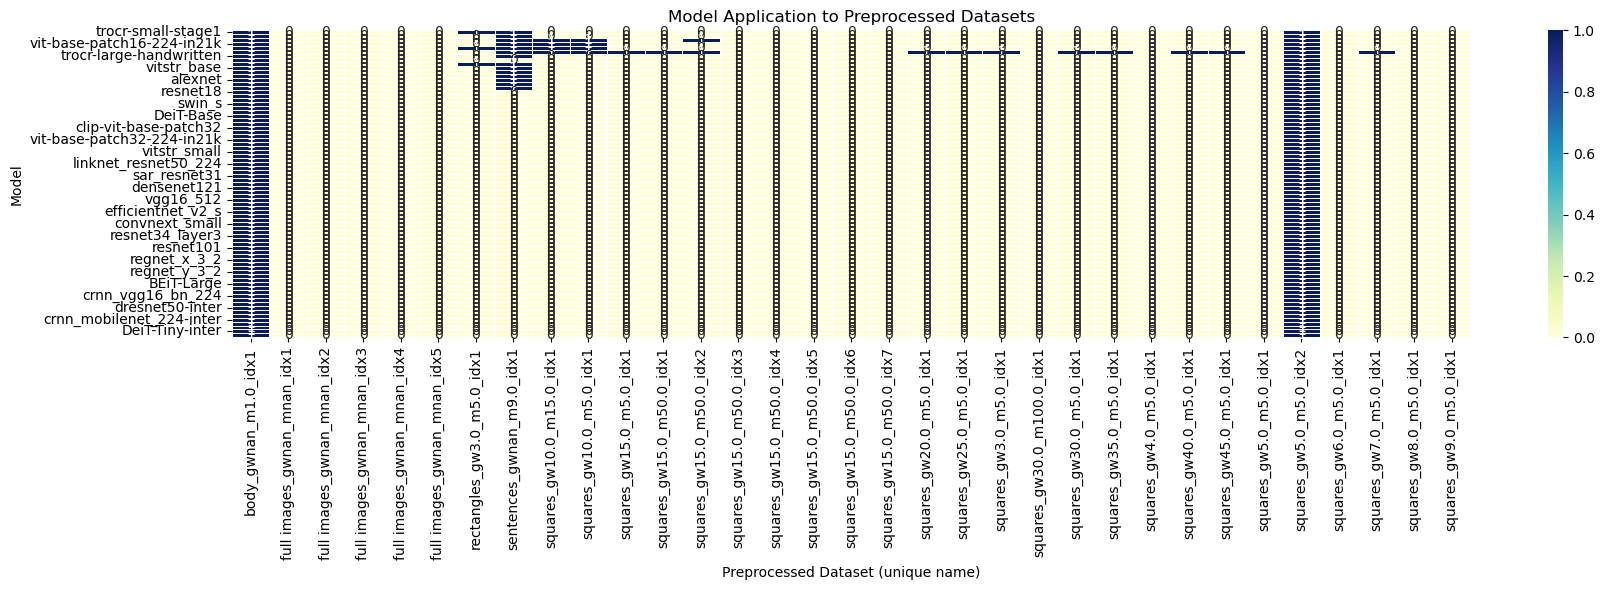

In [ ]:
import seaborn as sns

import matplotlib.pyplot as plt

# Convert the DataFrame to numeric (1 for applied, 0 or NaN for not applied)
viz_numeric = df_visualization.copy()
viz_numeric = viz_numeric.set_index('model')
viz_numeric = viz_numeric.apply(pd.to_numeric, errors='coerce').fillna(0)

plt.figure(figsize=(18, 6))
sns.heatmap(viz_numeric, annot=True, cmap='YlGnBu', cbar=True, linewidths=0.5)
plt.title('Model Application to Preprocessed Datasets')
plt.xlabel('Preprocessed Dataset (unique name)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

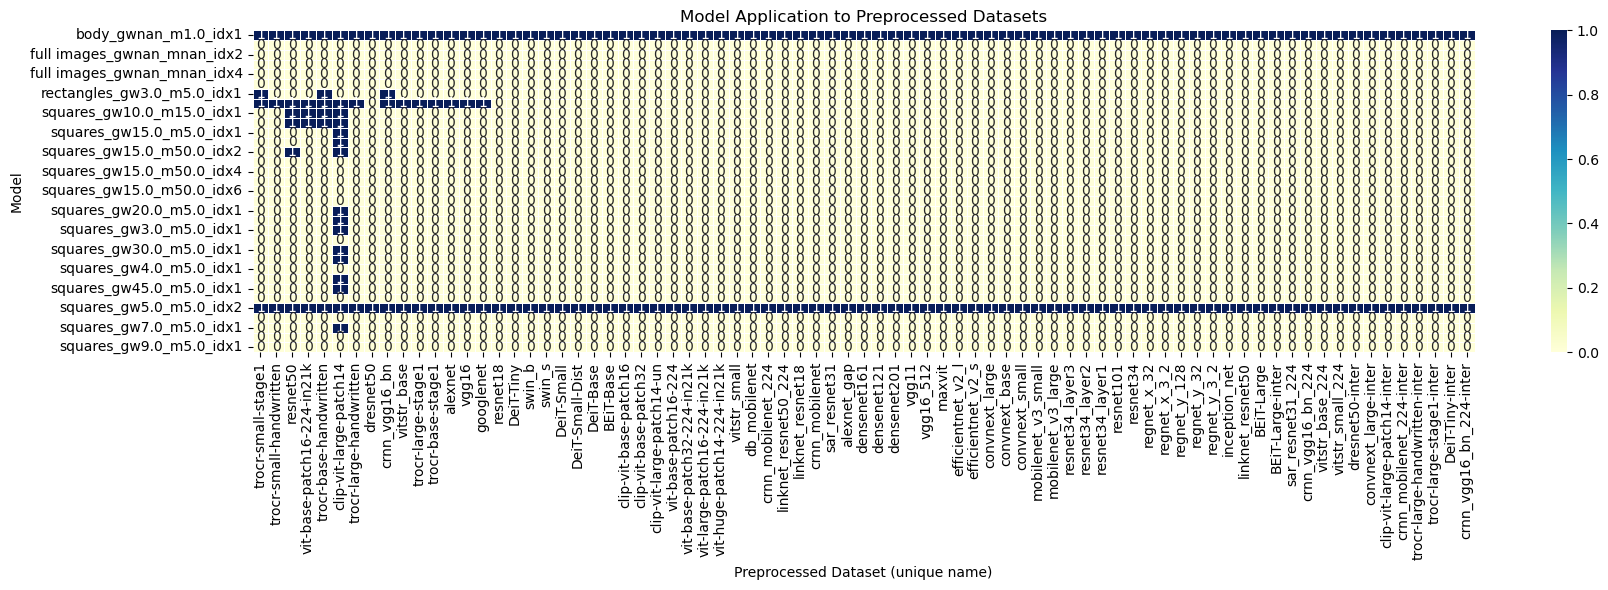

In [ ]:
viz_numeric_T = viz_numeric.transpose()
plt.figure(figsize=(18, 6))
sns.heatmap(viz_numeric_T, annot=True, cmap='YlGnBu', cbar=True, linewidths=0.5)
plt.title('Model Application to Preprocessed Datasets')
plt.xlabel('Preprocessed Dataset (unique name)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

In [ ]:
print(unique_names)

['body_gwnan_m1.0_idx1', 'full images_gwnan_mnan_idx1', 'full images_gwnan_mnan_idx2', 'full images_gwnan_mnan_idx3', 'full images_gwnan_mnan_idx4', 'full images_gwnan_mnan_idx5', 'rectangles_gw3.0_m5.0_idx1', 'sentences_gwnan_m9.0_idx1', 'squares_gw10.0_m15.0_idx1', 'squares_gw10.0_m5.0_idx1', 'squares_gw15.0_m5.0_idx1', 'squares_gw15.0_m50.0_idx1', 'squares_gw15.0_m50.0_idx2', 'squares_gw15.0_m50.0_idx3', 'squares_gw15.0_m50.0_idx4', 'squares_gw15.0_m50.0_idx5', 'squares_gw15.0_m50.0_idx6', 'squares_gw15.0_m50.0_idx7', 'squares_gw20.0_m5.0_idx1', 'squares_gw25.0_m5.0_idx1', 'squares_gw3.0_m5.0_idx1', 'squares_gw30.0_m100.0_idx1', 'squares_gw30.0_m5.0_idx1', 'squares_gw35.0_m5.0_idx1', 'squares_gw4.0_m5.0_idx1', 'squares_gw40.0_m5.0_idx1', 'squares_gw45.0_m5.0_idx1', 'squares_gw5.0_m5.0_idx1', 'squares_gw5.0_m5.0_idx2', 'squares_gw6.0_m5.0_idx1', 'squares_gw7.0_m5.0_idx1', 'squares_gw8.0_m5.0_idx1', 'squares_gw9.0_m5.0_idx1']


In [ ]:
unique_names


['body_gwnan_m1.0_idx1',
 'full images_gwnan_mnan_idx1',
 'full images_gwnan_mnan_idx2',
 'full images_gwnan_mnan_idx3',
 'full images_gwnan_mnan_idx4',
 'full images_gwnan_mnan_idx5',
 'rectangles_gw3.0_m5.0_idx1',
 'sentences_gwnan_m9.0_idx1',
 'squares_gw10.0_m15.0_idx1',
 'squares_gw10.0_m5.0_idx1',
 'squares_gw15.0_m5.0_idx1',
 'squares_gw15.0_m50.0_idx1',
 'squares_gw15.0_m50.0_idx2',
 'squares_gw15.0_m50.0_idx3',
 'squares_gw15.0_m50.0_idx4',
 'squares_gw15.0_m50.0_idx5',
 'squares_gw15.0_m50.0_idx6',
 'squares_gw15.0_m50.0_idx7',
 'squares_gw20.0_m5.0_idx1',
 'squares_gw25.0_m5.0_idx1',
 'squares_gw3.0_m5.0_idx1',
 'squares_gw30.0_m100.0_idx1',
 'squares_gw30.0_m5.0_idx1',
 'squares_gw35.0_m5.0_idx1',
 'squares_gw4.0_m5.0_idx1',
 'squares_gw40.0_m5.0_idx1',
 'squares_gw45.0_m5.0_idx1',
 'squares_gw5.0_m5.0_idx1',
 'squares_gw5.0_m5.0_idx2',
 'squares_gw6.0_m5.0_idx1',
 'squares_gw7.0_m5.0_idx1',
 'squares_gw8.0_m5.0_idx1',
 'squares_gw9.0_m5.0_idx1']

In [ ]:
models_with_sentences = viz_numeric[viz_numeric['sentences_gwnan_m9.0_idx1'] == 1].index.tolist()
print(models_with_sentences)

['trocr-small-stage1', 'trocr-small-handwritten', 'resnet50', 'vit-base-patch16-224-in21k', 'trocr-base-handwritten', 'clip-vit-large-patch14', 'trocr-large-handwritten', 'crnn_vgg16_bn', 'vitstr_base', 'trocr-large-stage1', 'trocr-base-stage1', 'alexnet', 'vgg16', 'googlenet']


# preparing the experiments

## experiments

In [77]:
experiments_df = pd.DataFrame(columns=['experiment_1'])

In [78]:
squares_standard_name = 'squares_gw5.0_m5.0_idx2'
sentences_standard_name = 'sentences_gwnan_m9.0_idx1'
rectangles_standard_name = 'rectangles_gw3.0_m5.0_idx1'
body_standard_name = 'body_gwnan_m1.0_idx1'

In [79]:
get_experiment_from_unique_name(df_pre_patch, squares_standard_name)

'icdar_train_df_patches_20250515_164130.csv'

In [80]:
get_experiment_from_unique_name(df_pre_patch, sentences_standard_name)

'icdar_train_df_words_sentences_20250522_230307.csv'

In [81]:
get_experiment_from_unique_name(df_pre_patch, body_standard_name)

'icdar_train_df_body_20250523_181312.csv'

In [82]:
get_experiment_from_unique_name(df_pre_patch, rectangles_standard_name)

'icdar_train_df_patches_20250522_234152.csv'

In [83]:
get_experiment_from_model_and_unique_names(df_pre_extracted, df_pre_patch, 'clip-vit-large-patch14', [squares_standard_name])

['icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv']

### first

all models on the standard one

In [84]:
squares_standard = get_experiment_from_unique_name(df_pre_patch, squares_standard_name)
matching_experiments = df_pre_extracted[df_pre_extracted['source_file'] == squares_standard]['experiment'].tolist()
print("Matching experiments for squares_standard:", matching_experiments)
experiments_df['experiment_1'] = matching_experiments


Matching experiments for squares_standard: ['icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_trocr-small-handwritten_20250516_150814.csv', 'icdar_EXTRACTED_train_df_resnet50_20250516_161022.csv', 'icdar_EXTRACTED_train_df_vit-base-patch16-224-in21k_20250517_151642.csv', 'icdar_EXTRACTED_train_df_trocr-base-handwritten_20250517_140220.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv', 'icdar_EXTRACTED_train_df_trocr-large-handwritten_20250517_150651.csv', 'icdar_EXTRACTED_train_df_dresnet50_20250520_143808.csv', 'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_153435.csv', 'icdar_EXTRACTED_train_df_vitstr_base_20250524_001621.csv', 'icdar_EXTRACTED_train_df_alexnet_20250625_113432.csv', 'icdar_EXTRACTED_train_df_vgg16_20250625_115907.csv', 'icdar_EXTRACTED_train_df_googlenet_20250625_121909.csv', 'icdar_EXTRACTED_train_df_trocr-large-stage1_20250625_124335.csv', 'icdar_EXTRACTED_train_df_trocr-base-stage1_20250625_130

### second

Compare on sentences, rectangle, standard
Recall to keep only 5 of the 9 rectangles so that you don't have the number of patches as a factor!

In [85]:
sentences_standard = get_experiment_from_unique_name(df_pre_patch, sentences_standard_name)
sentences_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == sentences_standard]['experiment'].tolist()
rectangles_standard = get_experiment_from_unique_name(df_pre_patch, rectangles_standard_name)
rectangles_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == rectangles_standard]['experiment'].tolist()


In [86]:
corresponding_models=get_models_with_both(viz_numeric, squares_standard_name, sentences_standard_name)

In [87]:
squares_experiment2 = get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, corresponding_models, squares_standard_name)

In [88]:
all_experiments = sentences_standard_experiments+ rectangles_standard_experiments + squares_experiment2
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_2': all_experiments})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

In [89]:
experiment_2_df

,experiment_2
0,icdar_EXTRACTED_train_df_trocr-small-stage1_20...
1,icdar_EXTRACTED_train_df_trocr-base-handwritte...
2,icdar_EXTRACTED_train_df_vit-base-patch16-224-...
3,icdar_EXTRACTED_train_df_crnn_vgg16_bn_2025052...
4,icdar_EXTRACTED_train_df_vitstr_base_20250524_...
5,icdar_EXTRACTED_train_df_clip-vit-large-patch1...
6,icdar_EXTRACTED_train_df_trocr-large-handwritt...
7,icdar_EXTRACTED_train_df_trocr-large-stage1_20...
8,icdar_EXTRACTED_train_df_trocr-base-stage1_202...
9,icdar_EXTRACTED_train_df_trocr-small-handwritt...


### experiment 3

In [90]:
increasing_patches=get_applied_unique_names(viz_numeric, 'clip-vit-large-patch14', filter_list=['squares','m5'])

In [91]:
increasing_patches_experiments = get_experiment_from_model_and_unique_names(df_pre_extracted, df_pre_patch, 'clip-vit-large-patch14', increasing_patches)

In [92]:
experiment_3_df = pd.DataFrame({'experiment_3': increasing_patches_experiments})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_3_df], axis=1)

### experiment 4

select a dataset with many patches and vary the number of patches -> the df will have only models corresponding to one file

In [93]:
experiment_4 = get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, ['clip-vit-large-patch14','resnet50'], 'squares_gw10.0_m15.0_idx1')
experiment_4_2 = get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, ['clip-vit-large-patch14'], 'squares_gw15.0_m50.0_idx1')
experiments_4 = experiment_4 + experiment_4_2

In [94]:
experiment_4_df = pd.DataFrame({'experiment_4': experiments_4})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_4_df], axis=1)

### experiments 5

varying the number of writers

In [95]:
experiment = get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, ['clip-vit-large-patch14','resnet50'], squares_standard_name)

In [96]:
experiment_df = pd.DataFrame({'experiment_5': experiment})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_df], axis=1)

### experiments 6

Lanciare i modelli su body e confrontare con modelli addestrati su patches. Per avere un confronto fair devo confrontarlo a parità di patches -> stesso numero di esempi.


In [97]:
corresponding_models=get_models_with_both(viz_numeric, squares_standard_name, body_standard_name)
corresponding_models_sentence=get_models_with_both(viz_numeric, sentences_standard_name, body_standard_name)

In [98]:
squares_experiment = get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, corresponding_models, squares_standard_name)
sentence_experiment = get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, corresponding_models_sentence, sentences_standard_name)
body_standard = get_experiment_from_unique_name(df_pre_patch, body_standard_name)
body_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == body_standard]['experiment'].tolist()

In [99]:
all_experiments = squares_experiment+ body_standard_experiments + sentence_experiment
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_6': all_experiments})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiments 7

I experiment with the generalization -> i train only on arab and test on both
I train only on english and test on both
I consider all models trained on sentences, body and standard patches. I vary mlp and logreg. I vary pca. I do it in both directions.

In [100]:
squares_standard = get_experiment_from_unique_name(df_pre_patch, squares_standard_name)
squares_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == squares_standard]['experiment'].tolist()
sentences_standard = get_experiment_from_unique_name(df_pre_patch, sentences_standard_name)
sentences_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == sentences_standard]['experiment'].tolist()
body_standard = get_experiment_from_unique_name(df_pre_patch, body_standard_name)
body_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == body_standard]['experiment'].tolist()

In [101]:
all_experiments = body_standard_experiments + sentences_standard_experiments + squares_standard_experiments
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_7': all_experiments})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiment 8

In [102]:
from itertools import combinations

squares_standard = get_experiment_from_unique_name(df_pre_patch, squares_standard_name)
squares_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == squares_standard]['experiment'].tolist()
# Create all unique pairs (order doesn't matter, no self-pairs)
experiment_pairs = list(combinations(squares_standard_experiments, 2))
print("Experiment pairs:", experiment_pairs)
print(len(experiment_pairs),len(squares_standard_experiments))

Experiment pairs: [('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_trocr-small-handwritten_20250516_150814.csv'), ('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_resnet50_20250516_161022.csv'), ('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_vit-base-patch16-224-in21k_20250517_151642.csv'), ('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_trocr-base-handwritten_20250517_140220.csv'), ('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv'), ('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_trocr-large-handwritten_20250517_150651.csv'), ('icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv', 'icdar_EXTRACTED_train_df_dresnet50_20250520_143808.csv'), ('icdar_EXTRACTED_trai

In [103]:
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_8': experiment_pairs})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiment 9

In [104]:
# merging same model and different input files

In [105]:
selected_models = ['clip-vit-large-patch14', 'resnet50']
selected_files = [[body_standard_name,squares_standard_name,sentences_standard_name,'squares_gw15.0_m5.0_idx1','squares_gw45.0_m5.0_idx1','squares_gw35.0_m5.0_idx1']
                  ,['squares_gw10.0_m5.0_idx1',body_standard_name,squares_standard_name]]
experiment_pairs = []
for model,files in zip(selected_models, selected_files):
    extracted_files = get_experiment_from_model_and_unique_names(df_pre_extracted, df_pre_patch, model, files)
    #print(f"Extracted files for model {model}: {extracted_files}")
    combinations_list=list(combinations(extracted_files, 2))
    experiment_pairs+=combinations_list

In [106]:
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_9': experiment_pairs})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiment 10

same experiment but ensembling is made by averaging representations

In [107]:
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_10': experiment_pairs})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiment 11

In [108]:
experiment_2_df = pd.DataFrame({'experiment_11': experiments_df['experiment_9']})
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

In [109]:
experiments_df

,experiment_1,experiment_2,experiment_3,experiment_4,experiment_5,experiment_6,experiment_7,experiment_8,experiment_9,experiment_10,experiment_11
0,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_resnet50_20250523_221...,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...
1,icdar_EXTRACTED_train_df_trocr-small-handwritt...,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_trocr-small-handwritt...,icdar_EXTRACTED_train_df_trocr-base-handwritte...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...
2,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,NaN,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_resnet50_20250523_230...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...
3,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_crnn_vgg16_bn_2025052...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,NaN,NaN,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...
4,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_vitstr_base_20250524_...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,NaN,NaN,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...
...,...,...,...,...,...,...,...,...,...,...,...
2921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-large-handwrit...,NaN,NaN,NaN
2922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-large-handwrit...,NaN,NaN,NaN
2923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-large-stage1-i...,NaN,NaN,NaN
2924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-large-stage1-i...,NaN,NaN,NaN


### experiment 12

In [110]:
#same as experiment_1 but varying the way in which I aggregate patches
experiment_2_df = pd.DataFrame({'experiment_12': experiments_df['experiment_1']})
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiment 13

In [111]:
squares_standard = get_experiment_from_unique_name(df_pre_patch, squares_standard_name)
squares_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == squares_standard]['experiment'].tolist()
body_standard = get_experiment_from_unique_name(df_pre_patch, body_standard_name)
body_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == body_standard]['experiment'].tolist()
all_experiments = body_standard_experiments + squares_standard_experiments
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_13': all_experiments})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

### experiment 14

In [112]:
squares_standard = get_experiment_from_unique_name(df_pre_patch, squares_standard_name)
squares_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == squares_standard]['experiment'].tolist()
body_standard = get_experiment_from_unique_name(df_pre_patch, body_standard_name)
body_standard_experiments = df_pre_extracted[df_pre_extracted['source_file'] == body_standard]['experiment'].tolist()
all_experiments = body_standard_experiments + squares_standard_experiments
# Create a new DataFrame for experiment_2
experiment_2_df = pd.DataFrame({'experiment_14': all_experiments})

# Concatenate with the existing DataFrame (fills with NaN automatically)
experiments_df = pd.concat([experiments_df.reset_index(drop=True), experiment_2_df], axis=1)

## save

In [185]:
display(experiments_df)

,experiment_1,experiment_2,experiment_3,experiment_4,experiment_5,experiment_6,experiment_7,experiment_8,experiment_9,experiment_10,experiment_11,experiment_12,experiment_13,experiment_14
0,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_resnet50_20250523_221...,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...
1,icdar_EXTRACTED_train_df_trocr-small-handwritt...,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_trocr-small-handwritt...,icdar_EXTRACTED_train_df_trocr-base-handwritte...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,icdar_EXTRACTED_train_df_trocr-small-handwritt...,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_trocr-base-handwritte...
2,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,NaN,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_resnet50_20250523_230...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,icdar_EXTRACTED_train_df_resnet50_20250516_161...,icdar_EXTRACTED_train_df_resnet50_20250523_230...,icdar_EXTRACTED_train_df_resnet50_20250523_230...
3,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_crnn_vgg16_bn_2025052...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,NaN,NaN,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...
4,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_vitstr_base_20250524_...,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,NaN,NaN,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,(icdar_EXTRACTED_train_df_trocr-small-stage1_2...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,(icdar_EXTRACTED_train_df_clip-vit-large-patch...,icdar_EXTRACTED_train_df_trocr-base-handwritte...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,icdar_EXTRACTED_train_df_trocr-small-stage1_20...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-large-stage1_2...,NaN,NaN,NaN,NaN,NaN,NaN
132,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-large-stage1_2...,NaN,NaN,NaN,NaN,NaN,NaN
133,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-base-stage1_20...,NaN,NaN,NaN,NaN,NaN,NaN
134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,(icdar_EXTRACTED_train_df_trocr-base-stage1_20...,NaN,NaN,NaN,NaN,NaN,NaN


In [186]:
from datetime import datetime

#experiments_df.to_csv(output_dir_preprocessed+'experiment_table.csv', index=False)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print("Timestamp:", timestamp)
experiments_df.to_pickle(output_dir_preprocessed+f'experiment_table_{timestamp}.pkl')

Timestamp: 20250830_183443


# results analysis

## common loading

In [113]:
output_dir = os.path.join(source_path, "outputs", "preprocessed_data")
#experiment_csv = os.path.join(output_dir, "experiment_table.csv")
#experiment_csv = os.path.join(output_dir, "experiment_table_20250702_193304.pkl")
#experiment_csv = os.path.join(output_dir, "experiment_table_20250711_154537.pkl")
experiment_csv = os.path.join(output_dir, "experiment_table_20250830_183443.pkl")
df_experiments = pd.read_pickle(experiment_csv)  # Use read_csv if the file is in CSV format

In [114]:
import glob
import re
folder=source_path+'\\outputs\\logs\\feature_extraction'
print(folder)
feature_files = glob.glob(os.path.join(folder, "*.json"))
print(len(feature_files))
def extract_number_from_filename(filepath):
    # Extract the base name
    base = os.path.basename(filepath)
    # Find the last underscore followed by digits before the extension
    match = re.search(r'_(\d+)\.json$', base)
    if match:
        return int(match.group(1))
    else:
        return -1  # or some default if no match

# Sort the files by the extracted number
feature_files = sorted(feature_files, key=extract_number_from_filename)
print([os.path.basename(f) for f in feature_files])

c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction
14
['results_experiment_1.json', 'results_experiment_2.json', 'results_experiment_3.json', 'results_experiment_4.json', 'results_experiment_5.json', 'results_experiment_6.json', 'results_experiment_7.json', 'results_experiment_8.json', 'results_experiment_9.json', 'results_experiment_10.json', 'results_experiment_11.json', 'results_experiment_12.json', 'results_experiment_13.json', 'results_experiment_14.json']


In [115]:
all_ensembling_approaches = ['individual','ensembled','ensembled_weighted','ensembled_most_probable','ensembled_writers']
best_metric='ensembled_weighted'
all_groups=['english,different',
 'english,same',
 'arabic,different',
 'arabic,same',
 'english,all',
 'arabic,all',
 'all,different',
 'all,same']
IF_OOF = ['IF','OOF']
all_metrics = ['Mean','Min','Max','Variance','Median','Confidence Interval','Generalization Gap']

In [116]:
list(df_experiments['experiment_6'])

['icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv',
 'icdar_EXTRACTED_train_df_trocr-small-handwritten_20250516_150814.csv',
 'icdar_EXTRACTED_train_df_resnet50_20250516_161022.csv',
 'icdar_EXTRACTED_train_df_vit-base-patch16-224-in21k_20250517_151642.csv',
 'icdar_EXTRACTED_train_df_trocr-base-handwritten_20250517_140220.csv',
 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv',
 'icdar_EXTRACTED_train_df_trocr-large-handwritten_20250517_150651.csv',
 'icdar_EXTRACTED_train_df_dresnet50_20250520_143808.csv',
 'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_153435.csv',
 'icdar_EXTRACTED_train_df_vitstr_base_20250524_001621.csv',
 'icdar_EXTRACTED_train_df_alexnet_20250625_113432.csv',
 'icdar_EXTRACTED_train_df_vgg16_20250625_115907.csv',
 'icdar_EXTRACTED_train_df_googlenet_20250625_121909.csv',
 'icdar_EXTRACTED_train_df_trocr-large-stage1_20250625_124335.csv',
 'icdar_EXTRACTED_train_df_trocr-base-stage1_20250625_130920.csv',
 'icdar_EXTRACTED_t

## experiment 1

In [298]:
experiment=feature_files[0]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all','english,all','arabic,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean', 'english,all_individual_OOF_accuracy_Mean', 'english,all_individual_Generalization Gap', 'english,all_individual_IF_accuracy_Mean', 'english,all_ensembled_OOF_accuracy_Mean', 'english,all_ensembled_Generalization Gap', 'english,all_ensembled_IF_accuracy_Mean', 'english,all_ensembled_weighted_OOF_accuracy_Mean', 'english,all_ensembled_weighted_Generalization Gap', 'english,all_ensembled_weighted_IF_accuracy_Mean', 'english,all_ensemble

In [299]:
selected_accuracies

['individual_OOF_accuracy_Mean',
 'individual_Generalization Gap',
 'individual_IF_accuracy_Mean',
 'ensembled_OOF_accuracy_Mean',
 'ensembled_Generalization Gap',
 'ensembled_IF_accuracy_Mean',
 'ensembled_weighted_OOF_accuracy_Mean',
 'ensembled_weighted_Generalization Gap',
 'ensembled_weighted_IF_accuracy_Mean',
 'ensembled_most_probable_OOF_accuracy_Mean',
 'ensembled_most_probable_Generalization Gap',
 'ensembled_most_probable_IF_accuracy_Mean',
 'ensembled_writers_OOF_accuracy_Mean',
 'ensembled_writers_Generalization Gap',
 'ensembled_writers_IF_accuracy_Mean',
 'english,all_individual_OOF_accuracy_Mean',
 'english,all_individual_Generalization Gap',
 'english,all_individual_IF_accuracy_Mean',
 'english,all_ensembled_OOF_accuracy_Mean',
 'english,all_ensembled_Generalization Gap',
 'english,all_ensembled_IF_accuracy_Mean',
 'english,all_ensembled_weighted_OOF_accuracy_Mean',
 'english,all_ensembled_weighted_Generalization Gap',
 'english,all_ensembled_weighted_IF_accuracy_Mean'

In [300]:
num_unique_models = df_visualization['model'].nunique()
print("Number of unique model names:", num_unique_models)

Number of unique model names: 15


In [301]:
#qual'è la miglior metrica per valutare le prestazioni del modello?
accuracy_metrics = select_accuracies(all_ensembling_approaches, ['OOF'], ['Mean'], ['all,all'])
df[accuracy_metrics].describe()

,individual_OOF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_weighted_OOF_accuracy_Mean,ensembled_most_probable_OOF_accuracy_Mean,ensembled_writers_OOF_accuracy_Mean
count,90.000000,90.000000,90.000000,90.000000,90.000000
mean,0.612898,0.649667,0.656170,0.647515,0.700514
std,0.037561,0.043504,0.043853,0.043711,0.049621
min,0.551541,0.568484,0.578869,0.564693,0.603195
25%,0.581371,0.613718,0.621538,0.612594,0.659273
50%,0.612643,0.650392,0.656195,0.647478,0.705201
75%,0.644406,0.682350,0.688279,0.681160,0.732942
max,0.687419,0.735573,0.738268,0.735714,0.811842


In [302]:
df[features_of_interest+['ensembled_weighted_OOF_accuracy_Mean']].sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False).head(10)

,FE model,classifier model,with PCA,unique name,type,ensembled_weighted_OOF_accuracy_Mean
33,clip-vit-large-patch14,lgbm,False,squares_gw5.0_m5.0_idx2,squares,0.738268
34,clip-vit-large-patch14,mlp,True,squares_gw5.0_m5.0_idx2,squares,0.738127
30,clip-vit-large-patch14,logreg,True,squares_gw5.0_m5.0_idx2,squares,0.735793
82,trocr-large-stage1,mlp,True,squares_gw5.0_m5.0_idx2,squares,0.734508
31,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,0.731924
35,clip-vit-large-patch14,mlp,False,squares_gw5.0_m5.0_idx2,squares,0.729355
32,clip-vit-large-patch14,lgbm,True,squares_gw5.0_m5.0_idx2,squares,0.723246
78,trocr-large-stage1,logreg,True,squares_gw5.0_m5.0_idx2,squares,0.721350
79,trocr-large-stage1,logreg,False,squares_gw5.0_m5.0_idx2,squares,0.719565
37,trocr-large-handwritten,logreg,False,squares_gw5.0_m5.0_idx2,squares,0.714348


### best metric

In [303]:
metrics = ['ensembled', 'ensembled_weighted', 'ensembled_most_probable']
cols = [f"{m}_OOF_accuracy_Mean" for m in metrics]
diff_df = df.copy()
diff_df['diff'] = diff_df[cols].max(axis=1) - diff_df[cols].min(axis=1)
diff_df['diff'].describe()

count    90.000000
mean      0.013217
std       0.007320
min       0.001660
25%       0.007879
50%       0.011607
75%       0.017372
max       0.035385
Name: diff, dtype: float64

In [304]:
cols = [f"{m}_OOF_accuracy_Mean" for m in metrics]
ranks = diff_df[cols].rank(axis=1, ascending=False, method='min')
for i, metric in enumerate(metrics):
    diff_df[f"{metric}_rank"] = ranks.iloc[:, i]
rank_cols = [f"{metric}_rank" for metric in metrics]
diff_df[rank_cols].describe()


,ensembled_rank,ensembled_weighted_rank,ensembled_most_probable_rank
count,90.000000,90.000000,90.000000
mean,2.288889,1.333333,2.377778
std,0.707018,0.560898,0.727900
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,2.000000
50%,2.000000,1.000000,3.000000
75%,3.000000,2.000000,3.000000
max,3.000000,3.000000,3.000000


### individual vs ensembled

In [305]:
diff_df=df.copy()
diff_df['diff'] = diff_df[f"{best_metric}_OOF_accuracy_Mean"] - diff_df['individual_OOF_accuracy_Mean']
diff_df['diff'].describe()

count    90.000000
mean      0.043271
std       0.010304
min       0.020887
25%       0.036332
50%       0.044019
75%       0.049876
max       0.070711
Name: diff, dtype: float64

### writer level vs page level

In [306]:
diff_df=df.copy()
diff_df['diff'] = diff_df[f"ensembled_writers_OOF_accuracy_Mean"] - diff_df[f'{best_metric}_OOF_accuracy_Mean']
diff_df['diff'].describe()

count    90.000000
mean      0.044344
std       0.017353
min       0.013346
25%       0.030921
50%       0.042387
75%       0.055475
max       0.087563
Name: diff, dtype: float64

### comparing models by accuracy

,FE model,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
33,clip-vit-large-patch14,0.738268,0.683352,lgbm,False
82,trocr-large-stage1,0.734508,0.663797,mlp,True
37,trocr-large-handwritten,0.714348,0.650041,logreg,False
43,dresnet50,0.708944,0.645551,logreg,False
84,trocr-base-stage1,0.706407,0.672202,logreg,True
23,vit-base-patch16-224-in21k,0.702992,0.646980,mlp,False
25,trocr-base-handwritten,0.693828,0.629452,logreg,False
15,resnet50,0.678900,0.630680,lgbm,False
72,googlenet,0.669878,0.614019,logreg,True
69,vgg16,0.648684,0.609909,lgbm,False


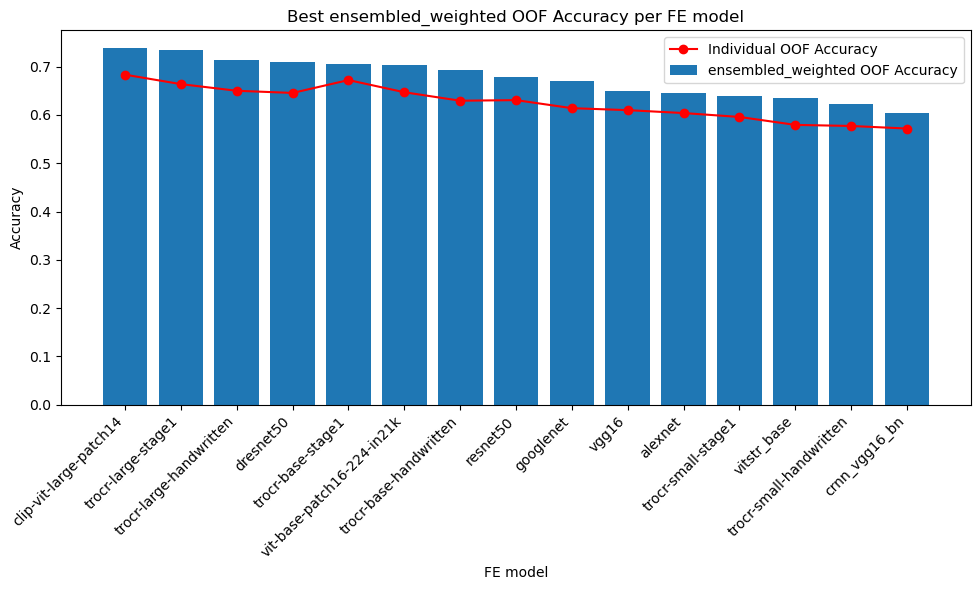

In [307]:
model_comparison = df.copy()
best_rows = model_comparison.loc[model_comparison.groupby('FE model')[f'{best_metric}_OOF_accuracy_Mean'].idxmax()]
best_rows = best_rows.sort_values(f'{best_metric}_OOF_accuracy_Mean', ascending=False)
display(best_rows[['FE model', f'{best_metric}_OOF_accuracy_Mean', 'individual_OOF_accuracy_Mean','classifier model','with PCA']])

plt.figure(figsize=(10, 6))
plt.bar(best_rows['FE model'], best_rows[f'{best_metric}_OOF_accuracy_Mean'], label=f'{best_metric} OOF Accuracy')
plt.plot(best_rows['FE model'], best_rows['individual_OOF_accuracy_Mean'], color='red', marker='o', linestyle='-', label='Individual OOF Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('FE model')
plt.title(f'Best {best_metric} OOF Accuracy per FE model')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### comparing best models by generalization gap

In [308]:
best_rows = best_rows.sort_values(f'{best_metric}_Generalization Gap', ascending=True)
display(best_rows[['FE model', f'{best_metric}_Generalization Gap', 'individual_Generalization Gap','classifier model','with PCA']])

,FE model,ensembled_weighted_Generalization Gap,individual_Generalization Gap,classifier model,with PCA
48,crnn_vgg16_bn,0.085812,0.062489,logreg,True
84,trocr-base-stage1,0.090135,0.073449,logreg,True
72,googlenet,0.142613,0.108931,logreg,True
7,trocr-small-handwritten,0.148157,0.107731,logreg,False
1,trocr-small-stage1,0.153817,0.118315,logreg,False
25,trocr-base-handwritten,0.196006,0.172538,logreg,False
55,vitstr_base,0.206658,0.154345,logreg,False
37,trocr-large-handwritten,0.217159,0.181599,logreg,False
82,trocr-large-stage1,0.247984,0.261866,mlp,True
33,clip-vit-large-patch14,0.261732,0.316648,lgbm,False


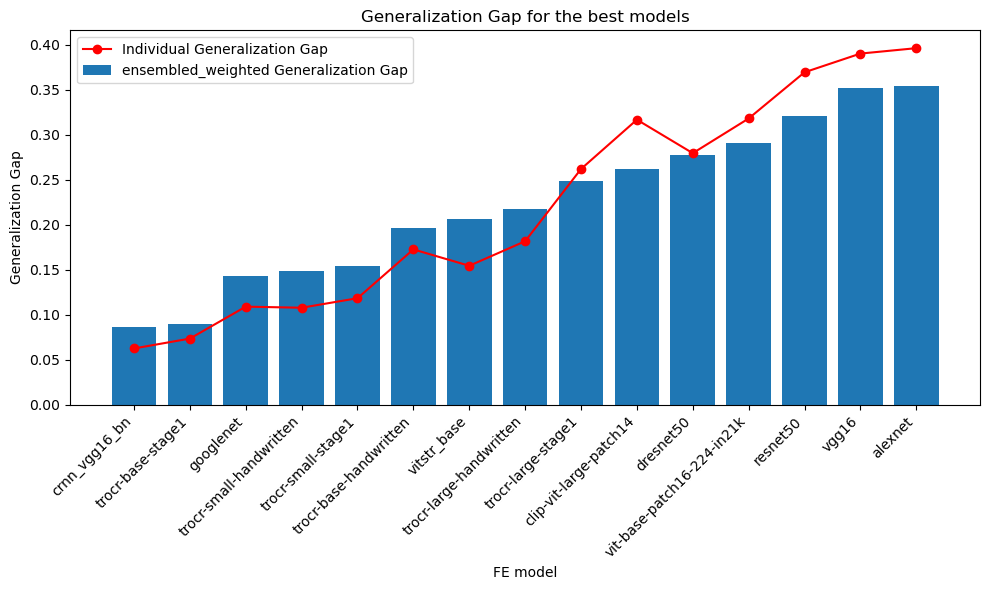

In [309]:
plt.figure(figsize=(10, 6))
plt.bar(best_rows['FE model'], best_rows[f'{best_metric}_Generalization Gap'], label=f'{best_metric} Generalization Gap')
plt.plot(best_rows['FE model'], best_rows['individual_Generalization Gap'], color='red', marker='o', linestyle='-', label='Individual Generalization Gap')
plt.ylabel('Generalization Gap')
plt.xlabel('FE model')
plt.title(f'Generalization Gap for the best models')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\andre\AppData\Local\Temp\ipykernel_37052\2932666721.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(best_rows['FE model'], rotation=45, ha='right')


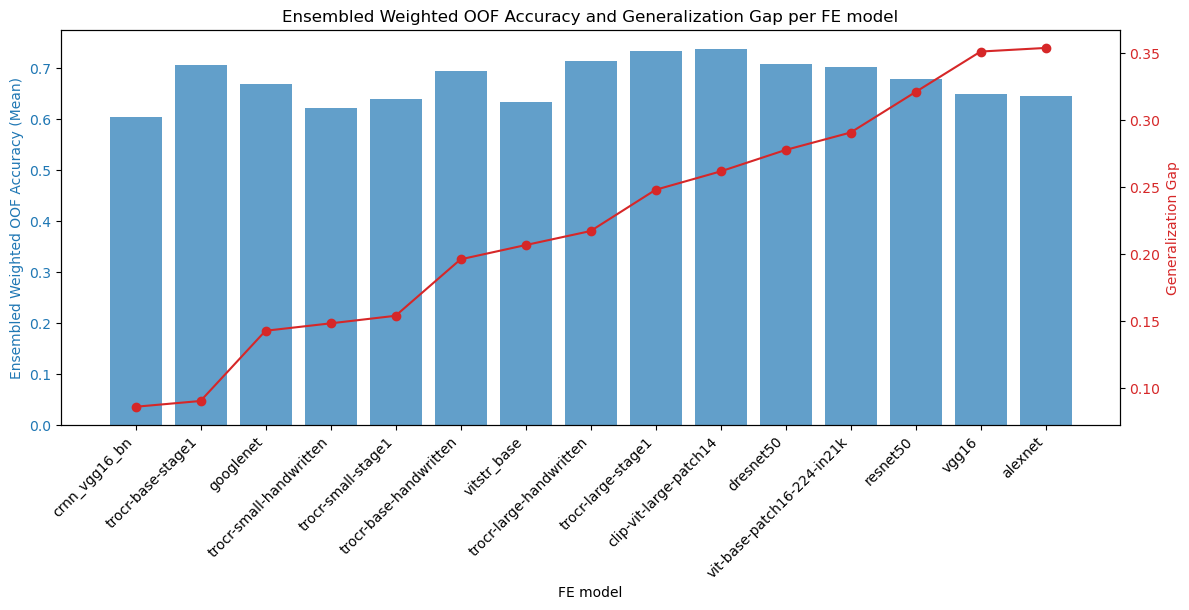

In [310]:
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('FE model')
ax1.set_ylabel('Ensembled Weighted OOF Accuracy (Mean)', color=color)
ax1.bar(best_rows['FE model'], best_rows['ensembled_weighted_OOF_accuracy_Mean'], color=color, alpha=0.7, label='Ensembled Weighted OOF Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(best_rows['FE model'], rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Generalization Gap', color=color)
ax2.plot(best_rows['FE model'], best_rows['ensembled_weighted_Generalization Gap'], color=color, marker='o', label='Generalization Gap')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Ensembled Weighted OOF Accuracy and Generalization Gap per FE model')
plt.show()

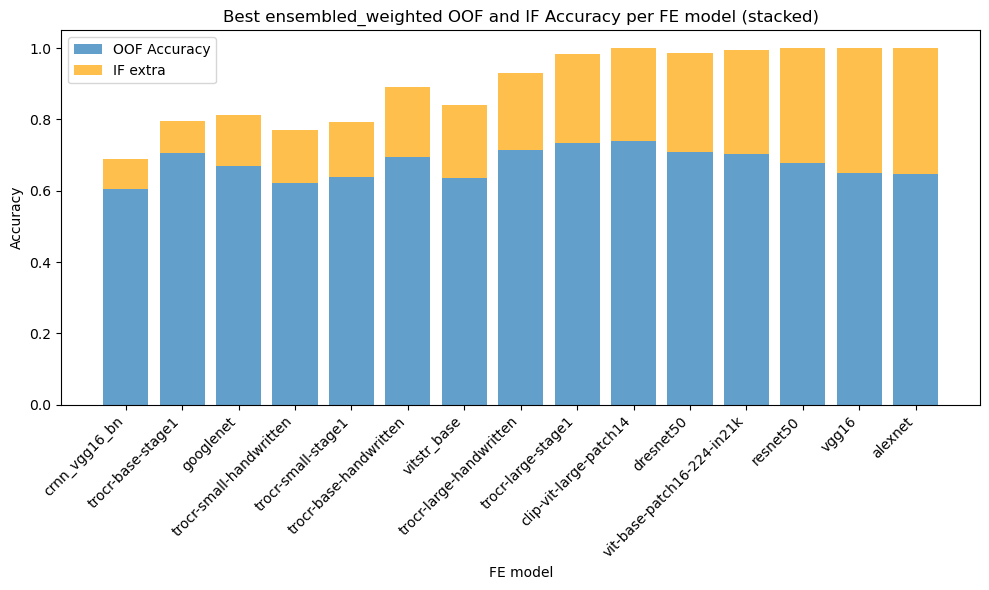

In [311]:
oof = best_rows[f'{best_metric}_OOF_accuracy_Mean']
if_acc = best_rows[f'{best_metric}_IF_accuracy_Mean']

plt.figure(figsize=(10, 6))
plt.bar(best_rows['FE model'], oof, label='OOF Accuracy', alpha=0.7)
plt.bar(best_rows['FE model'], if_acc - oof, bottom=oof, label='IF extra', alpha=0.7, color='orange')
plt.ylabel('Accuracy')
plt.xlabel('FE model')
plt.title(f'Best {best_metric} OOF and IF Accuracy per FE model (stacked)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

,FE model,ensembled_weighted_Generalization Gap,ensembled_weighted_OOF_accuracy_Mean,classifier model,with PCA
30,clip-vit-large-patch14,0.094425,0.735793,logreg,True
78,trocr-large-stage1,0.096018,0.721350,logreg,True
84,trocr-base-stage1,0.090135,0.706407,logreg,True
18,vit-base-patch16-224-in21k,0.119029,0.683490,logreg,True
42,dresnet50,0.056030,0.681532,logreg,True
36,trocr-large-handwritten,0.092035,0.681454,logreg,True
24,trocr-base-handwritten,0.068405,0.677820,logreg,True
72,googlenet,0.142613,0.669878,logreg,True
12,resnet50,0.181827,0.664583,logreg,True
66,vgg16,0.279451,0.624812,logreg,True


C:\Users\andre\AppData\Local\Temp\ipykernel_37052\620074887.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(best_rows['FE model'], rotation=45, ha='right')


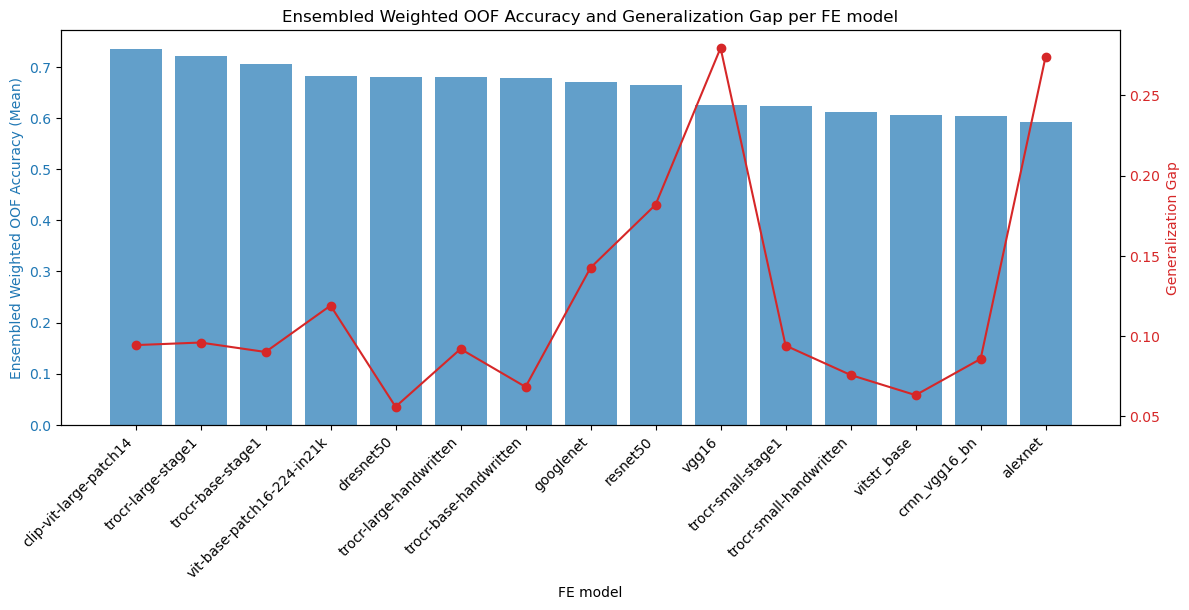

In [312]:
model_comparison = df.copy()
best_rows = model_comparison.loc[model_comparison.groupby('FE model')[f'{best_metric}_Generalization Gap'].idxmin()]
#best_rows = best_rows.sort_values(f'{best_metric}_Generalization Gap', ascending=True)
best_rows = best_rows.sort_values(f'{best_metric}_OOF_accuracy_Mean', ascending=False)
display(best_rows[['FE model', f'{best_metric}_Generalization Gap', 'ensembled_weighted_OOF_accuracy_Mean', 'classifier model','with PCA' ]])
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('FE model')
ax1.set_ylabel('Ensembled Weighted OOF Accuracy (Mean)', color=color)
ax1.bar(best_rows['FE model'], best_rows['ensembled_weighted_OOF_accuracy_Mean'], color=color, alpha=0.7, label='Ensembled Weighted OOF Accuracy')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticklabels(best_rows['FE model'], rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Generalization Gap', color=color)
ax2.plot(best_rows['FE model'], best_rows['ensembled_weighted_Generalization Gap'], color=color, marker='o', label='Generalization Gap')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Ensembled Weighted OOF Accuracy and Generalization Gap per FE model')
plt.show()


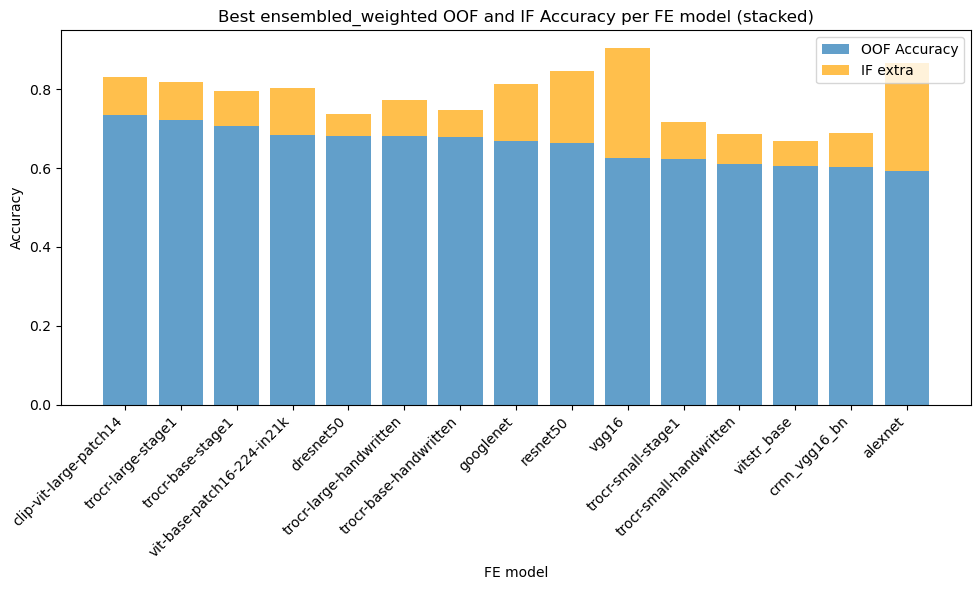

In [313]:
oof = best_rows[f'{best_metric}_OOF_accuracy_Mean']
if_acc = best_rows[f'{best_metric}_IF_accuracy_Mean']

plt.figure(figsize=(10, 6))
plt.bar(best_rows['FE model'], oof, label='OOF Accuracy', alpha=0.7)
plt.bar(best_rows['FE model'], if_acc - oof, bottom=oof, label='IF extra', alpha=0.7, color='orange')
plt.ylabel('Accuracy')
plt.xlabel('FE model')
plt.title(f'Best {best_metric} OOF and IF Accuracy per FE model (stacked)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### Difference on subgroups

,FE model,ensembled_weighted_OOF_accuracy_Mean,"english,all_ensembled_weighted_OOF_accuracy_Mean","arabic,all_ensembled_weighted_OOF_accuracy_Mean"
33,clip-vit-large-patch14,0.738268,0.765664,0.710871
82,trocr-large-stage1,0.734508,0.708835,0.760182
37,trocr-large-handwritten,0.714348,0.716259,0.712437
43,dresnet50,0.708944,0.703759,0.714129
84,trocr-base-stage1,0.706407,0.719737,0.693076
23,vit-base-patch16-224-in21k,0.702992,0.718076,0.687907
25,trocr-base-handwritten,0.693828,0.703634,0.684023
15,resnet50,0.678900,0.684242,0.673559
72,googlenet,0.669878,0.668076,0.671679
69,vgg16,0.648684,0.636341,0.661028


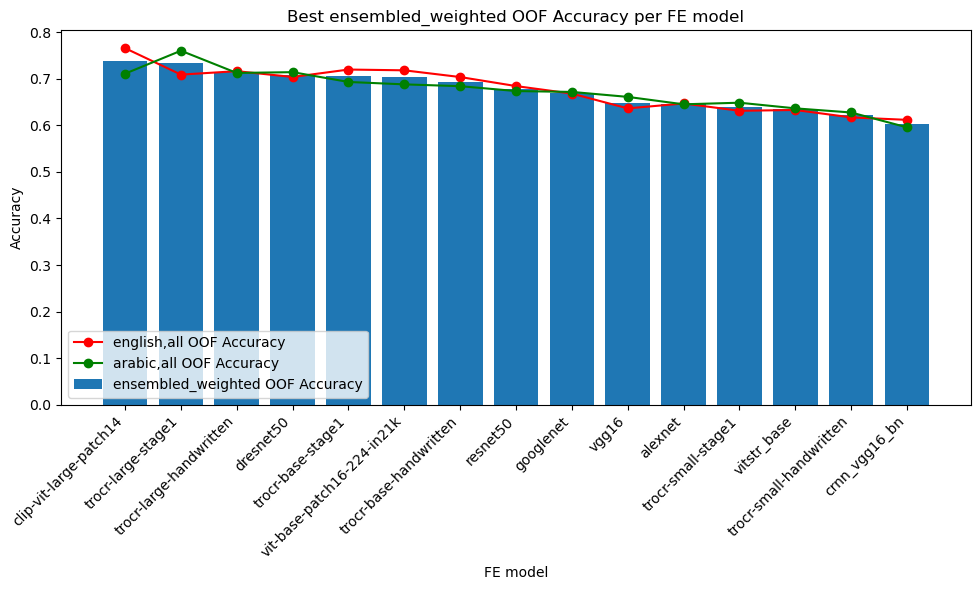

In [314]:
model_comparison = df.copy()
best_rows = model_comparison.loc[model_comparison.groupby('FE model')[f'{best_metric}_OOF_accuracy_Mean'].idxmax()]
best_rows = best_rows.sort_values(f'{best_metric}_OOF_accuracy_Mean', ascending=False)
display(best_rows[['FE model', f'{best_metric}_OOF_accuracy_Mean', f'english,all_{best_metric}_OOF_accuracy_Mean',f'arabic,all_{best_metric}_OOF_accuracy_Mean']])
plt.figure(figsize=(10, 6))
plt.bar(best_rows['FE model'], best_rows[f'{best_metric}_OOF_accuracy_Mean'], label=f'{best_metric} OOF Accuracy')
plt.plot(best_rows['FE model'], best_rows[f'english,all_{best_metric}_OOF_accuracy_Mean'], color='red', marker='o', linestyle='-', label='english,all OOF Accuracy')
plt.plot(best_rows['FE model'], best_rows[f'arabic,all_{best_metric}_OOF_accuracy_Mean'], color='green', marker='o', linestyle='-', label='arabic,all OOF Accuracy')
#plt.plot(best_rows['FE model'], best_rows[f'english,all_individual_OOF_accuracy_Mean'], color='red', marker='o', linestyle='-', label='english,all individual OOF Accuracy')
#plt.plot(best_rows['FE model'], best_rows[f'arabic,all_individual_OOF_accuracy_Mean'], color='green', marker='o', linestyle='-', label='arabic,all individual OOF Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('FE model')
plt.title(f'Best {best_metric} OOF Accuracy per FE model')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

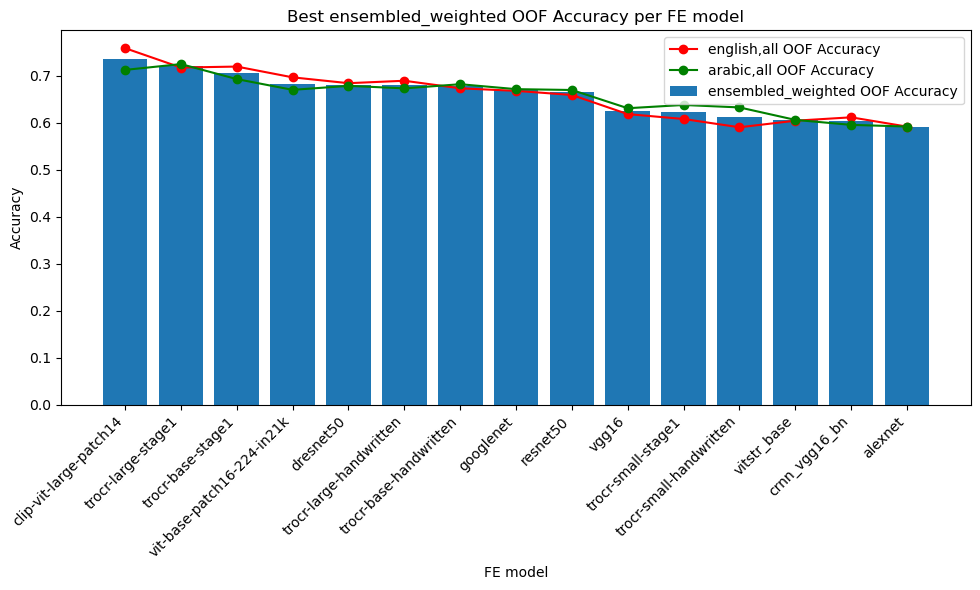

In [315]:
model_comparison = df.copy()
best_rows = model_comparison.loc[model_comparison.groupby('FE model')[f'{best_metric}_Generalization Gap'].idxmin()]
#best_rows = best_rows.sort_values(f'{best_metric}_Generalization Gap', ascending=True)
best_rows = best_rows.sort_values(f'{best_metric}_OOF_accuracy_Mean', ascending=False)
plt.figure(figsize=(10, 6))
plt.bar(best_rows['FE model'], best_rows[f'{best_metric}_OOF_accuracy_Mean'], label=f'{best_metric} OOF Accuracy')
plt.plot(best_rows['FE model'], best_rows[f'english,all_{best_metric}_OOF_accuracy_Mean'], color='red', marker='o', linestyle='-', label='english,all OOF Accuracy')
plt.plot(best_rows['FE model'], best_rows[f'arabic,all_{best_metric}_OOF_accuracy_Mean'], color='green', marker='o', linestyle='-', label='arabic,all OOF Accuracy')
#plt.plot(best_rows['FE model'], best_rows[f'english,all_individual_OOF_accuracy_Mean'], color='red', marker='o', linestyle='-', label='english,all individual OOF Accuracy')
#plt.plot(best_rows['FE model'], best_rows[f'arabic,all_individual_OOF_accuracy_Mean'], color='green', marker='o', linestyle='-', label='arabic,all individual OOF Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('FE model')
plt.title(f'Best {best_metric} OOF Accuracy per FE model')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### comparing classification head

In [316]:
selected_features = ['FE model', 'classifier model', 'with PCA','ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap']
logreg_table = df[df['classifier model'] == 'logreg'][selected_features]
lgbm_table = df[df['classifier model'] == 'lgbm'][selected_features]
mlp_table = df[df['classifier model'] == 'mlp'][selected_features]

In [317]:
print(len(logreg_table), len(lgbm_table), len(mlp_table))
diff_table = pd.merge(logreg_table, lgbm_table, on=['FE model','with PCA'], suffixes=('_logreg', '_lgbm'))
print(len(diff_table))

30 30 30
30


In [318]:
mlp_table = mlp_table.rename(columns={
    'ensembled_weighted_OOF_accuracy_Mean': 'ensembled_weighted_OOF_accuracy_Mean_mlp',
    'ensembled_weighted_Generalization Gap': 'ensembled_weighted_Generalization Gap_mlp'
})

In [319]:
diff_table = diff_table.merge(mlp_table, on=['FE model','with PCA'], suffixes=('', '_mlp'))

In [320]:
diff_table['diff_logreg_mlp'] = diff_table['ensembled_weighted_OOF_accuracy_Mean_logreg'] - diff_table['ensembled_weighted_OOF_accuracy_Mean_mlp']
diff_table['diff_logreg_lgbm'] = diff_table['ensembled_weighted_OOF_accuracy_Mean_logreg'] - diff_table['ensembled_weighted_OOF_accuracy_Mean_lgbm']
diff_table['diff_ens_logreg_mlp'] = diff_table['ensembled_weighted_Generalization Gap_logreg'] - diff_table['ensembled_weighted_Generalization Gap_mlp']
diff_table['diff_ens_logreg_lgbm'] = diff_table['ensembled_weighted_Generalization Gap_logreg'] - diff_table['ensembled_weighted_Generalization Gap_lgbm']

In [321]:
import numpy as np

# Select only the diff columns and groupby
diff_cols = [col for col in diff_table.columns if col.startswith('diff')]
grouped = diff_table.sort_values(['FE model','with PCA'])[['FE model','with PCA']+diff_cols]

# Style: highlight negative in red, positive in green, only for numeric columns
def highlight_diff(val):
    if isinstance(val, (int, float, np.integer, np.floating)):
        color = 'red' if val < 0 else 'green' if val > 0 else ''
        return f'background-color: {color}'
    return ''

styled = grouped.style.applymap(highlight_diff, subset=diff_cols)
display(styled)

C:\Users\andre\AppData\Local\Temp\ipykernel_37052\303430660.py:14: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = grouped.style.applymap(highlight_diff, subset=diff_cols)


,FE model,with PCA,diff_logreg_mlp,diff_logreg_lgbm,diff_ens_logreg_mlp,diff_ens_logreg_lgbm
21,alexnet,False,-0.013142,-0.037829,0.029564,0.021430
20,alexnet,True,-0.010479,-0.038095,-0.074841,-0.095769
11,clip-vit-large-patch14,False,0.002569,-0.006344,-0.091690,-0.100495
10,clip-vit-large-patch14,True,-0.002334,0.012547,-0.129322,-0.182330
17,crnn_vgg16_bn,False,0.001927,-0.001895,-0.094558,-0.246548
16,crnn_vgg16_bn,True,0.009727,0.023167,-0.120253,-0.333675
15,dresnet50,False,0.018609,0.037218,0.026856,-0.050520
14,dresnet50,True,0.021382,0.016839,-0.192934,-0.279278
25,googlenet,False,-0.007910,-0.013142,-0.046212,-0.075510
24,googlenet,True,0.016870,0.011372,-0.180447,-0.198882


In [322]:
grouped.describe()

,diff_logreg_mlp,diff_logreg_lgbm,diff_ens_logreg_mlp,diff_ens_logreg_lgbm
count,30.000000,30.000000,30.000000,30.000000
mean,0.004966,0.006251,-0.098541,-0.165274
std,0.020278,0.027146,0.073741,0.109667
min,-0.060056,-0.069815,-0.192934,-0.353601
25%,-0.009191,-0.005604,-0.151802,-0.244178
50%,0.007025,0.010714,-0.100014,-0.184626
75%,0.018304,0.021718,-0.061258,-0.088520
max,0.039662,0.058568,0.085113,0.069815


### comparing pca

In [323]:
selected_features = ['FE model', 'classifier model', 'with PCA','ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap']
with_table = df[df['with PCA'] == True][selected_features]
without_table = df[df['with PCA'] == False][selected_features]
diff_table = pd.merge(with_table, without_table, on=['FE model','classifier model'], suffixes=('_with', '_without'))

In [324]:
diff_table['diff_with_without'] = diff_table['ensembled_weighted_OOF_accuracy_Mean_with'] - diff_table['ensembled_weighted_OOF_accuracy_Mean_without']
diff_table['diff_ens_with_without'] = diff_table['ensembled_weighted_Generalization Gap_with'] - diff_table['ensembled_weighted_Generalization Gap_without']

In [325]:
# Select only the diff columns and groupby
diff_cols = [col for col in diff_table.columns if col.startswith('diff')]
grouped = diff_table.sort_values(['FE model','classifier model'])[['FE model','classifier model']+diff_cols]

# Style: highlight negative in red, positive in green, only for numeric columns
def highlight_diff(val):
    if isinstance(val, (int, float, np.integer, np.floating)):
        color = 'red' if val < 0 else 'green' if val > 0 else ''
        return f'background-color: {color}'
    return ''

styled = grouped.style.applymap(highlight_diff, subset=diff_cols)
display(styled)

C:\Users\andre\AppData\Local\Temp\ipykernel_37052\525529366.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = grouped.style.applymap(highlight_diff, subset=diff_cols)


,FE model,classifier model,diff_with_without,diff_ens_with_without
31,alexnet,lgbm,-0.015868,0.015868
30,alexnet,logreg,-0.016134,-0.101331
32,alexnet,mlp,-0.018797,0.003074
16,clip-vit-large-patch14,lgbm,-0.015022,0.015022
15,clip-vit-large-patch14,logreg,0.003869,-0.066813
17,clip-vit-large-patch14,mlp,0.008772,-0.029181
25,crnn_vgg16_bn,lgbm,-0.021570,0.021570
24,crnn_vgg16_bn,logreg,0.003493,-0.065557
26,crnn_vgg16_bn,mlp,-0.004308,-0.039862
22,dresnet50,lgbm,-0.007033,0.007033


## experiment 2

In [326]:
experiment=feature_files[1]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


### compare accuracies

In [327]:
# Pivot the DataFrame to have one column per unique 'type', values are 'ensembled_weighted_OOF_accuracy_Mean'
pivot_df = df.pivot_table(
    index=['FE model', 'classifier model', 'with PCA', 'unique name'],
    columns='type',
    values='ensembled_weighted_OOF_accuracy_Mean'
).reset_index()

# Optionally, reorder columns to have the type columns last
type_columns = df['type'].unique().tolist()
print("Type columns:", type_columns)
pivot_df = pivot_df[['FE model', 'classifier model', 'with PCA', 'unique name'] + type_columns]
agg_dict_1 = {col: 'max' for col in type_columns}
pivot_df = pivot_df.groupby(['FE model'], as_index=False).agg(agg_dict_1)
def highlight_max(s, color='lightgreen'):
    is_max = s == s.max()
    return ['background-color: {}'.format(color) if v else '' for v in is_max]

styled_pivot = pivot_df.style.apply(highlight_max, subset=type_columns, axis=1)
styled_pivot

Type columns: ['sentences', 'rectangles', 'squares']


type,FE model,sentences,rectangles,squares
0,alexnet,0.590445,nan,0.608161
1,clip-vit-large-patch14,0.652459,nan,0.731924
2,crnn_vgg16_bn,0.665508,0.651175,0.600188
3,googlenet,0.616745,nan,0.643468
4,resnet50,0.646053,nan,0.638080
5,trocr-base-handwritten,0.692215,0.706281,0.693828
6,trocr-base-stage1,0.697400,nan,0.700266
7,trocr-large-handwritten,0.686779,nan,0.714348
8,trocr-large-stage1,0.722212,nan,0.719565
9,trocr-small-handwritten,0.627600,nan,0.622243


In [328]:
# Pivot the DataFrame to have one column per unique 'type', values are 'ensembled_weighted_OOF_accuracy_Mean'
pivot_df = df.pivot_table(
    index=['FE model', 'classifier model', 'with PCA', 'unique name'],
    columns='type',
    values='individual_OOF_accuracy_Mean'
).reset_index()

# Optionally, reorder columns to have the type columns last
type_columns = df['type'].unique().tolist()
print("Type columns:", type_columns)
pivot_df = pivot_df[['FE model', 'classifier model', 'with PCA', 'unique name'] + type_columns]
agg_dict_1 = {col: 'max' for col in type_columns}
pivot_df = pivot_df.groupby(['FE model'], as_index=False).agg(agg_dict_1)
def highlight_max(s, color='lightgreen'):
    is_max = s == s.max()
    return ['background-color: {}'.format(color) if v else '' for v in is_max]

styled_pivot = pivot_df.style.apply(highlight_max, subset=type_columns, axis=1)
styled_pivot

Type columns: ['sentences', 'rectangles', 'squares']


type,FE model,sentences,rectangles,squares
0,alexnet,0.560479,nan,0.564897
1,clip-vit-large-patch14,0.600526,nan,0.678139
2,crnn_vgg16_bn,0.605877,0.605448,0.563665
3,googlenet,0.570777,nan,0.585717
4,resnet50,0.582152,nan,0.590824
5,trocr-base-handwritten,0.639721,0.648424,0.629452
6,trocr-base-stage1,0.636842,nan,0.648650
7,trocr-large-handwritten,0.623769,nan,0.650041
8,trocr-large-stage1,0.653885,nan,0.664868
9,trocr-small-handwritten,0.578806,nan,0.577152


## experiment 3

In [50]:
experiment=feature_files[2]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type','gw'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type','gw']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


In [51]:
df[features_of_interest+['ensembled_weighted_OOF_accuracy_Mean']]
df = df[df['unique name'] != 'squares_gw15.0_m50.0_idx1']

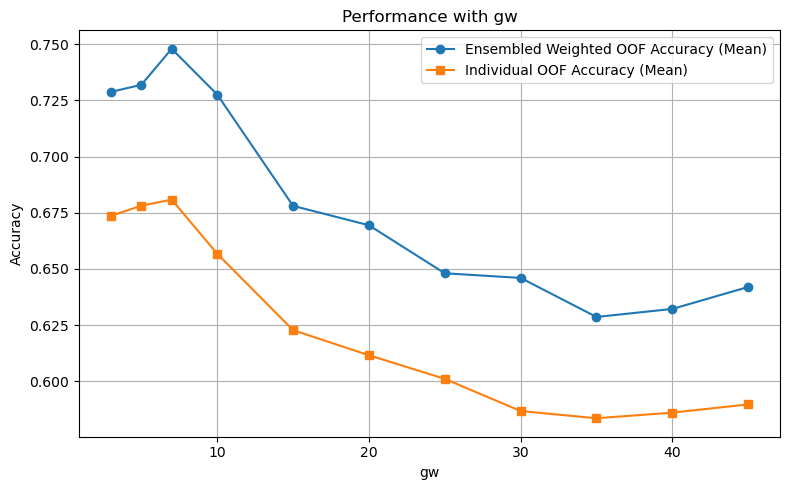

In [54]:
import numpy as np

import matplotlib.pyplot as plt
x= df['gw']
y1 = df['ensembled_weighted_OOF_accuracy_Mean']
y2 = df['individual_OOF_accuracy_Mean']
#y3 = df['ensembled_weighted_IF_accuracy_Mean']
#y4 = df['individual_IF_accuracy_Mean']
# Sort by x to connect each point to the next closest on x axis
sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx].values
y1_sorted = y1.iloc[sorted_idx].values
y2_sorted = y2.iloc[sorted_idx].values
#y3_sorted = y3.iloc[sorted_idx].values
#y4_sorted = y4.iloc[sorted_idx].values

plt.figure(figsize=(8, 5))
plt.plot(x_sorted, y1_sorted, marker='o', label='Ensembled Weighted OOF Accuracy (Mean)')
plt.plot(x_sorted, y2_sorted, marker='s', label='Individual OOF Accuracy (Mean)')
#plt.plot(x_sorted, y3_sorted, marker='o', label='Ensembled Weighted IF Accuracy (Mean)')
#plt.plot(x_sorted, y4_sorted, marker='s', label='Individual IF Accuracy (Mean)')
plt.xlabel('gw')
plt.ylabel('Accuracy')
plt.title('Performance with gw')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.show()

plt.savefig('performance_with_gw.png', dpi=300, bbox_inches='tight')

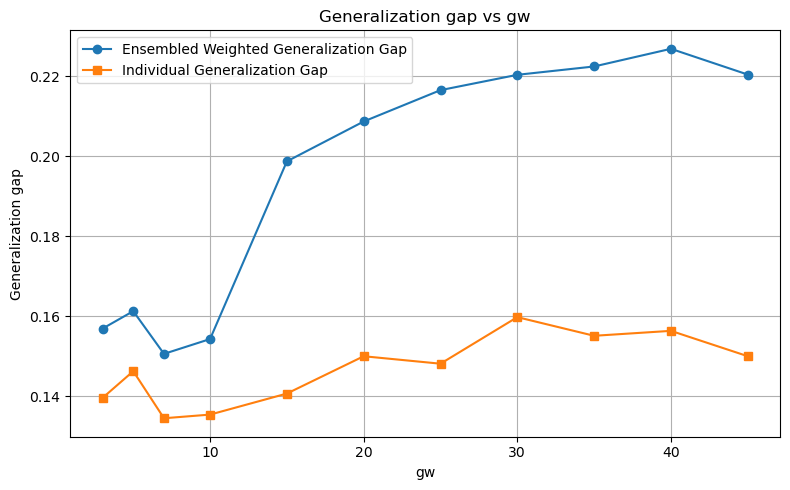

In [53]:
import numpy as np

import matplotlib.pyplot as plt
x= df['gw']
y1 = df['ensembled_weighted_Generalization Gap']
y2 = df['individual_Generalization Gap']
# Sort by x to connect each point to the next closest on x axis
sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx].values
y1_sorted = y1.iloc[sorted_idx].values
y2_sorted = y2.iloc[sorted_idx].values

plt.figure(figsize=(8, 5))
plt.plot(x_sorted, y1_sorted, marker='o', label='Ensembled Weighted Generalization Gap')
plt.plot(x_sorted, y2_sorted, marker='s', label='Individual Generalization Gap')
plt.xlabel('gw')
plt.ylabel('Generalization gap')
plt.title('Generalization gap vs gw')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## experiment 4

In [1]:
experiment=feature_files[3]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type','gw'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type','n_sub_patches']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

NameError: name 'feature_files' is not defined

In [118]:
df[features_of_interest+['ensembled_weighted_OOF_accuracy_Mean']].sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False).head(20)

,FE model,classifier model,with PCA,unique name,type,n_sub_patches,ensembled_weighted_OOF_accuracy_Mean
77,clip-vit-large-patch14,logreg,False,squares_gw15.0_m50.0_idx1,squares,48,0.753587
78,clip-vit-large-patch14,logreg,False,squares_gw15.0_m50.0_idx1,squares,49,0.751770
29,clip-vit-large-patch14,logreg,False,squares_gw10.0_m15.0_idx1,squares,15,0.751472
26,clip-vit-large-patch14,logreg,False,squares_gw10.0_m15.0_idx1,squares,12,0.749796
28,clip-vit-large-patch14,logreg,False,squares_gw10.0_m15.0_idx1,squares,14,0.748872
75,clip-vit-large-patch14,logreg,False,squares_gw15.0_m50.0_idx1,squares,46,0.748073
27,clip-vit-large-patch14,logreg,False,squares_gw10.0_m15.0_idx1,squares,13,0.748011
79,clip-vit-large-patch14,logreg,False,squares_gw15.0_m50.0_idx1,squares,50,0.746460
107,clip-vit-large-patch14,mlp,False,squares_gw10.0_m15.0_idx1,squares,13,0.746131
69,clip-vit-large-patch14,logreg,False,squares_gw15.0_m50.0_idx1,squares,40,0.744533


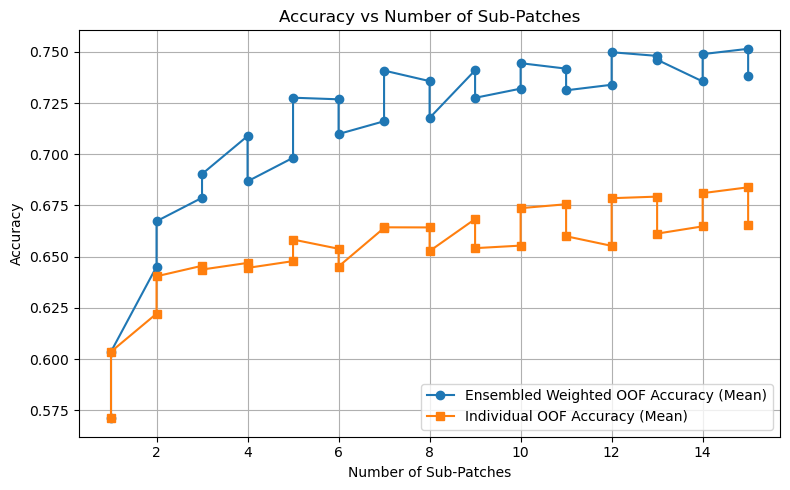

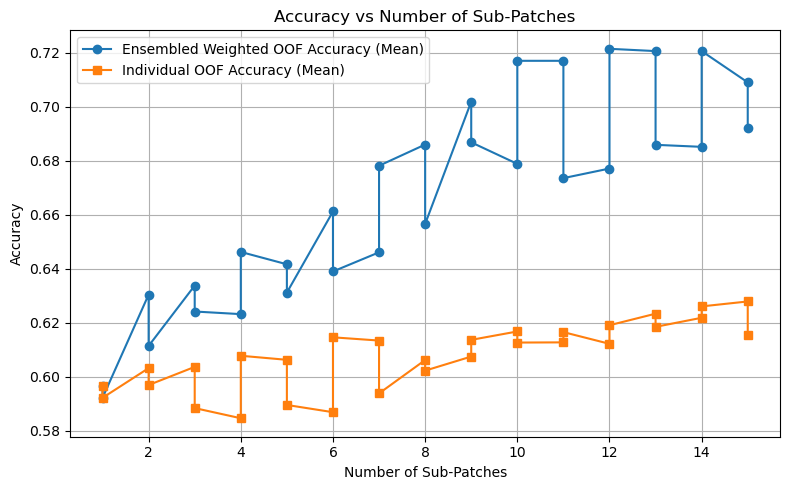

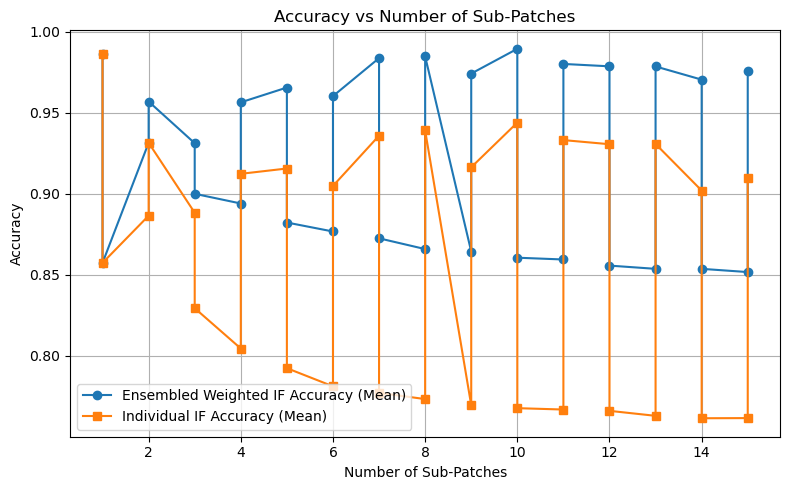

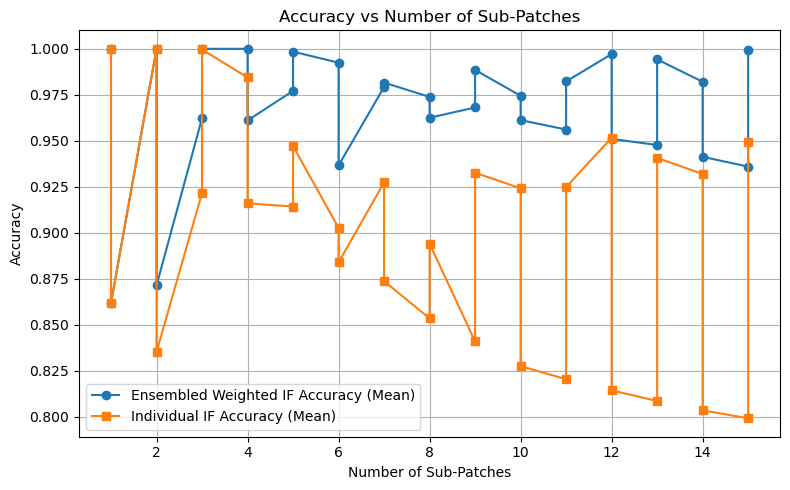

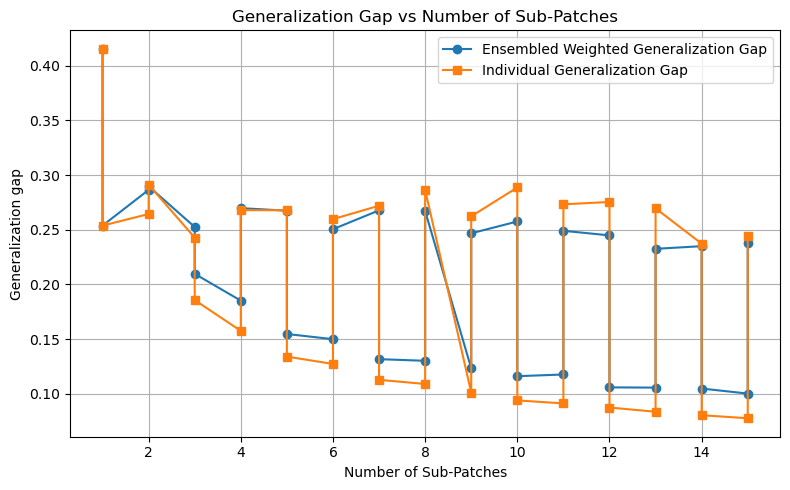

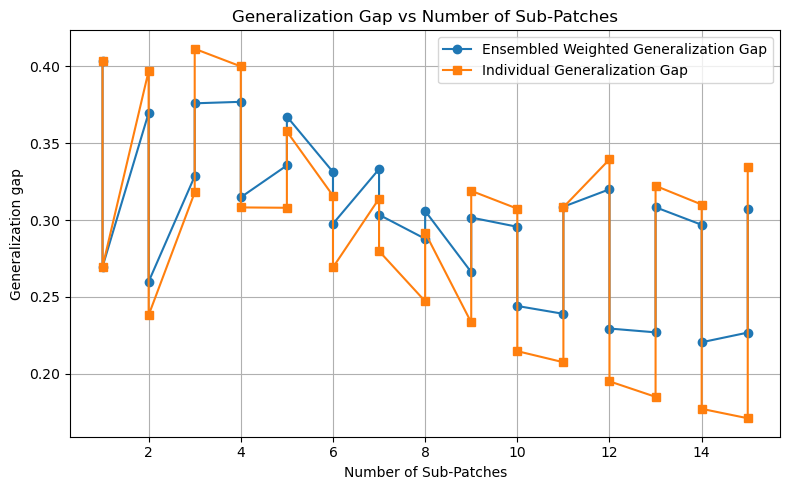

In [119]:
df = df_exp[df_exp['unique name'] != 'squares_gw15.0_m50.0_idx1']
show_patch_plot(df[df['FE model'] == 'clip-vit-large-patch14'])
show_patch_plot(df[df['FE model'] == 'resnet50'])
show_patch_plot(df[df['FE model'] == 'clip-vit-large-patch14'], if_oof='IF')
show_patch_plot(df[df['FE model'] == 'resnet50'], if_oof='IF')
show_patch_plot_gen(df[df['FE model'] == 'clip-vit-large-patch14'])
show_patch_plot_gen(df[df['FE model'] == 'resnet50'])

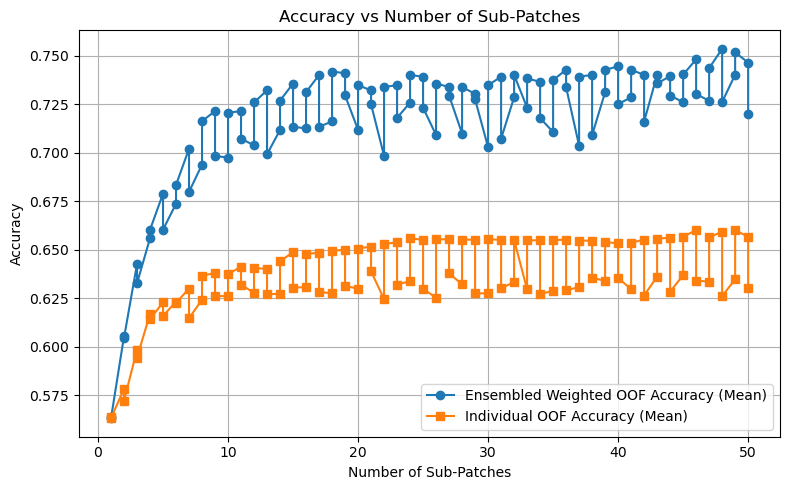

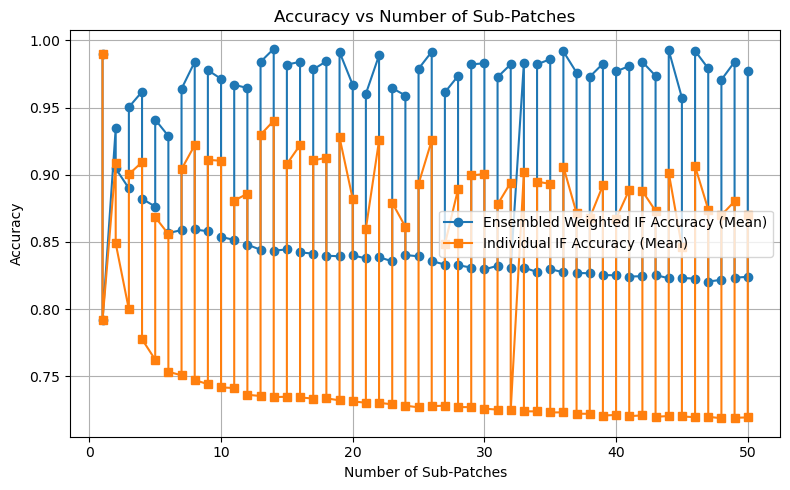

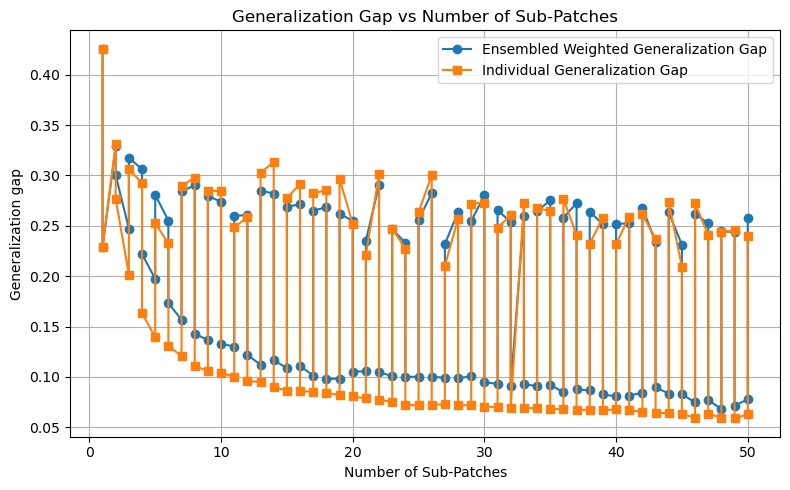

In [120]:
df = df_exp[df_exp['unique name'] == 'squares_gw15.0_m50.0_idx1']
show_patch_plot(df[df['FE model'] == 'clip-vit-large-patch14'])
show_patch_plot(df[df['FE model'] == 'clip-vit-large-patch14'], if_oof='IF')
show_patch_plot_gen(df[df['FE model'] == 'clip-vit-large-patch14'])

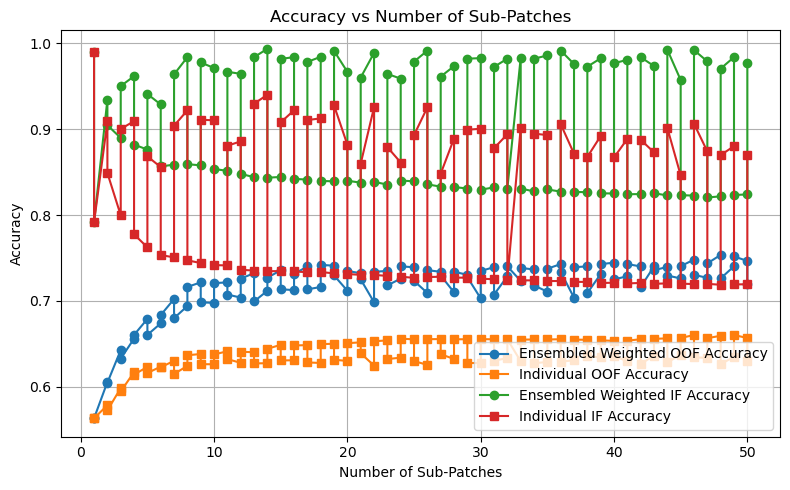

In [121]:
def show_patch_plot_total(df,if_oof='OOF',column='n_sub_patches'):
    if if_oof == 'OOF':
        oof_if = 'IF'
    else:
        oof_if = 'OOF'
    x= df[column]
    if column == 'n_sub_patches':
        x_title = 'Number of Sub-Patches'
    elif column == 'gw':
        x_title = 'Fraction of page width'
    elif column == 'n_writers':
        x_title = 'Number of writers'
    y1 = df[f'ensembled_weighted_{if_oof}_accuracy_Mean']
    y2 = df[f'individual_{if_oof}_accuracy_Mean']
    y3 = df[f'ensembled_weighted_{oof_if}_accuracy_Mean']
    y4 = df[f'individual_{oof_if}_accuracy_Mean']
    #y3 = df[f'ensembled_weighted_Generalization Gap']
    #y4 = df[f'individual_Generalization Gap']
    # Sort by x to connect each point to the next closest on x axis
    sorted_idx = np.argsort(x)
    x_sorted = x.iloc[sorted_idx].values
    y1_sorted = y1.iloc[sorted_idx].values
    y2_sorted = y2.iloc[sorted_idx].values
    y3_sorted = y3.iloc[sorted_idx].values
    y4_sorted = y4.iloc[sorted_idx].values

    plt.figure(figsize=(8, 5))
    plt.plot(x_sorted, y1_sorted, marker='o', label=f'Ensembled Weighted {if_oof} Accuracy')
    plt.plot(x_sorted, y2_sorted, marker='s', label=f'Individual {if_oof} Accuracy')
    plt.plot(x_sorted, y3_sorted, marker='o', label=f'Ensembled Weighted {oof_if} Accuracy')
    plt.plot(x_sorted, y4_sorted, marker='s', label=f'Individual {oof_if} Accuracy')
    #plt.plot(x_sorted, y3_sorted, marker='o', label=f'Ensembled Weighted Generalization Gap')
    #plt.plot(x_sorted, y4_sorted, marker='s', label=f'Individual Generalization Gap')
    plt.xlabel(x_title)
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy vs {x_title}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
show_patch_plot_total(df[df['FE model'] == 'clip-vit-large-patch14'], if_oof='OOF')

## experiment 5

In [185]:
experiment=feature_files[4]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type','gw'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type','n_writers']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


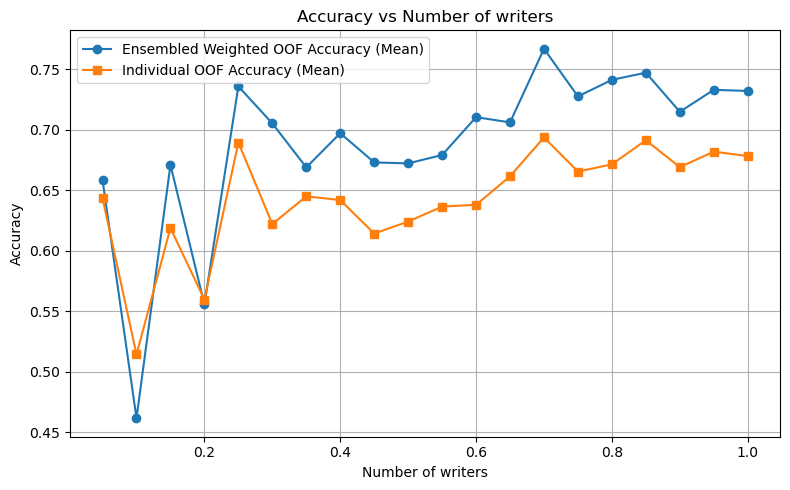

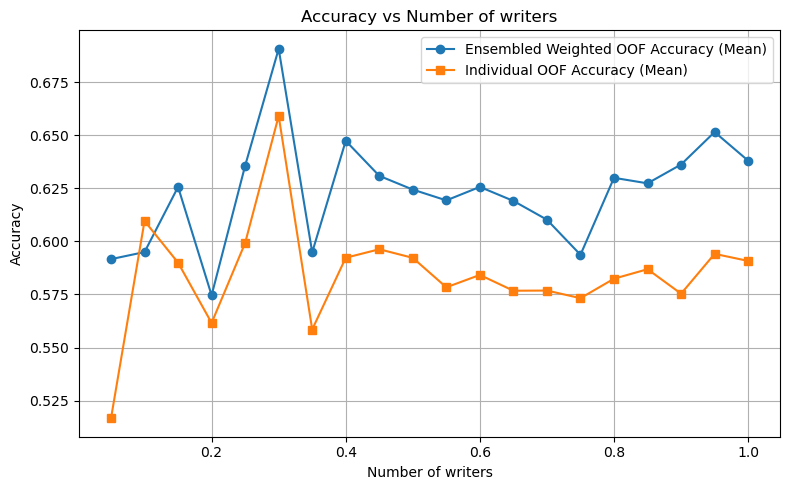

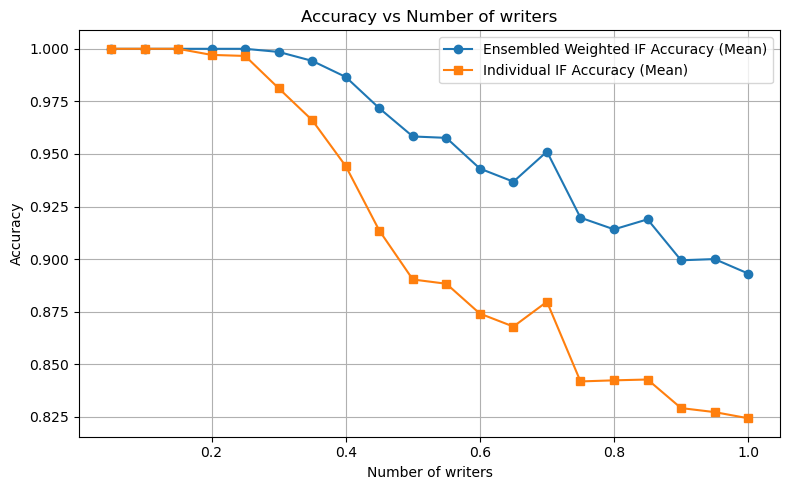

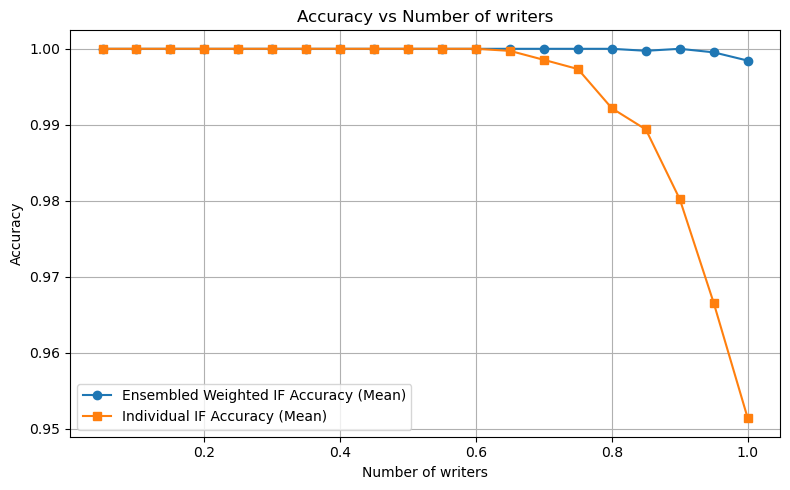

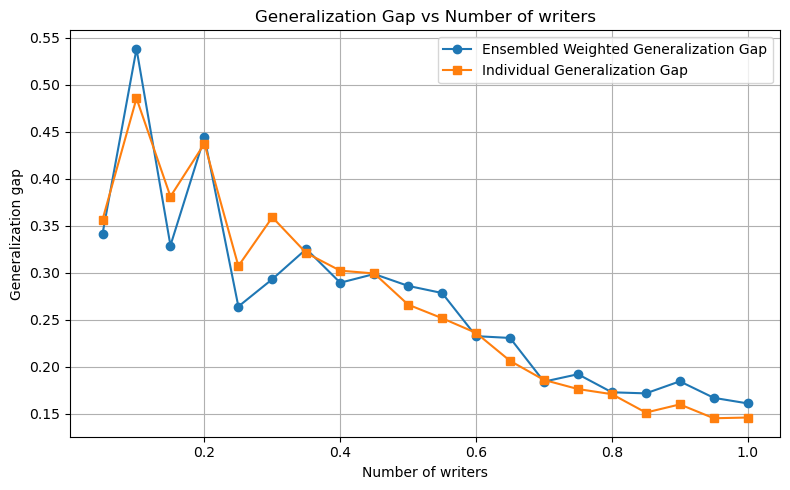

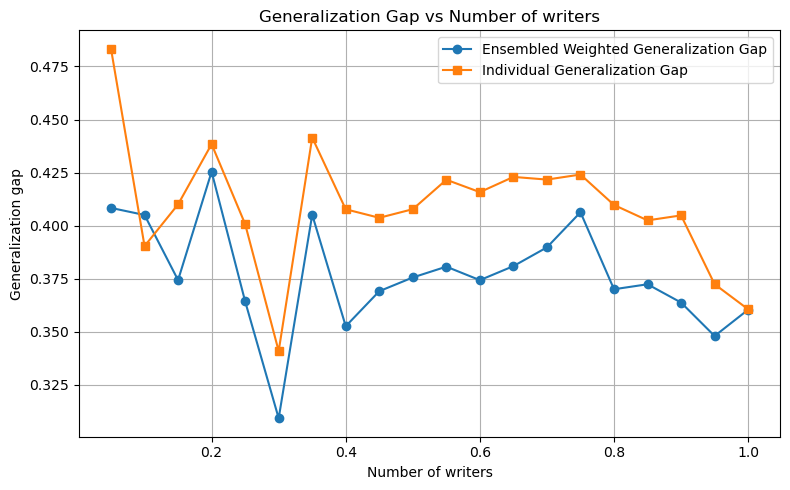

In [186]:
show_patch_plot(df[df['FE model'] == 'clip-vit-large-patch14'],column='n_writers')
show_patch_plot(df[df['FE model'] == 'resnet50'],column='n_writers')
show_patch_plot(df[df['FE model'] == 'clip-vit-large-patch14'], if_oof='IF',column='n_writers')
show_patch_plot(df[df['FE model'] == 'resnet50'], if_oof='IF',column='n_writers')
show_patch_plot_gen(df[df['FE model'] == 'clip-vit-large-patch14'],column='n_writers')
show_patch_plot_gen(df[df['FE model'] == 'resnet50'],column='n_writers')

## experiment 6

In [329]:
experiment=feature_files[5]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type','n_sub_patches']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
print(df['cross_val_accuracies'][0])
print(df['cross_val_accuracies'][1])

{'IF': [{'individual': 0.7155555555555555, 'ensembled': 0.7822222222222223, 'ensembled_weighted': 0.7955555555555556, 'ensembled_most_probable': 0.7777777777777778, 'ensembled_writers': 0.88}, {'individual': 0.7046666666666667, 'ensembled': 0.7566666666666667, 'ensembled_weighted': 0.78, 'ensembled_most_probable': 0.7733333333333333, 'ensembled_writers': 0.8666666666666667}, {'individual': 0.7165929203539823, 'ensembled': 0.7898230088495575, 'ensembled_weighted': 0.8064159292035398, 'ensembled_most_probable': 0.786504424778761, 'ensembled_writers': 0.8761061946902655}, {'individual': 0.7099557522123894, 'ensembled': 0.7765486725663717, 'ensembled_weighted': 0.7876106194690266, 'ensembled_most_probable': 0.7676991150442478, 'ensembled_writers': 0.8716814159292036}, {'individual': 0.7238938053097345, 'ensembled': 0.797566371681416, 'ensembled_weighted': 0.7986725663716814, 'ensembled_most_probable': 0.7842920353982301, 'ensembled_writers': 0.8893805309734514}], 'OOF': [{'individual': 0.5

In [330]:
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


### one patch

In [331]:
# Pivot the DataFrame to have one column per unique 'type', values are 'ensembled_weighted_OOF_accuracy_Mean'
df=df_exp[df_exp['n_sub_patches'] == 1]
pivot_df = df.pivot_table(
    index=['FE model', 'classifier model', 'with PCA', 'unique name'],
    columns='type',
    values='ensembled_weighted_OOF_accuracy_Mean'
).reset_index()

# Optionally, reorder columns to have the type columns last
type_columns = df['type'].unique().tolist()
print("Type columns:", type_columns)
pivot_df = pivot_df[['FE model', 'classifier model', 'with PCA', 'unique name'] + type_columns]
agg_dict_1 = {col: 'max' for col in type_columns}
pivot_df = pivot_df.groupby(['FE model'], as_index=False).agg(agg_dict_1)
def highlight_max(s, color='lightgreen'):
    is_max = s == s.max()
    return ['background-color: {}'.format(color) if v else '' for v in is_max]

styled_pivot = pivot_df.style.apply(highlight_max, subset=type_columns, axis=1)
styled_pivot

Type columns: ['squares', 'body', 'sentences']


type,FE model,squares,body,sentences
0,alexnet,0.560307,0.530044,0.546930
1,clip-vit-large-patch14,0.622227,0.622259,0.577068
2,crnn_vgg16_bn,0.550627,0.551206,0.544267
3,googlenet,0.553900,0.567231,0.567419
4,resnet50,0.586920,0.628430,0.593766
5,trocr-base-handwritten,0.621429,0.614897,0.608020
6,trocr-base-stage1,0.621194,0.636451,0.611435
7,trocr-large-handwritten,0.594706,0.626739,0.596570
8,trocr-large-stage1,0.640695,0.573340,0.580655
9,trocr-small-handwritten,0.541729,0.580529,0.528430


### all patches

In [332]:
df=df_exp[df_exp['n_sub_patches'] == -1]
pivot_df = df.pivot_table(
    index=['FE model', 'classifier model', 'with PCA', 'unique name'],
    columns='type',
    values='ensembled_weighted_OOF_accuracy_Mean'
).reset_index()

# Optionally, reorder columns to have the type columns last
type_columns = df['type'].unique().tolist()
print("Type columns:", type_columns)
pivot_df = pivot_df[['FE model', 'classifier model', 'with PCA', 'unique name'] + type_columns]
agg_dict_1 = {col: 'max' for col in type_columns}
pivot_df = pivot_df.groupby(['FE model'], as_index=False).agg(agg_dict_1)
def highlight_max(s, color='lightgreen'):
    is_max = s == s.max()
    return ['background-color: {}'.format(color) if v else '' for v in is_max]

styled_pivot = pivot_df.style.apply(highlight_max, subset=type_columns, axis=1)
styled_pivot

Type columns: ['squares', 'body', 'sentences']


type,FE model,squares,body,sentences
0,alexnet,0.608161,0.530044,0.626817
1,clip-vit-large-patch14,0.731924,0.622259,0.674655
2,crnn_vgg16_bn,0.600188,0.551206,0.666259
3,googlenet,0.643468,0.567231,0.651206
4,resnet50,0.638080,0.628430,0.688565
5,trocr-base-handwritten,0.693828,0.614897,0.731109
6,trocr-base-stage1,0.700266,0.636451,0.733694
7,trocr-large-handwritten,0.714348,0.626739,0.716165
8,trocr-large-stage1,0.719565,0.573340,0.758631
9,trocr-small-handwritten,0.622243,0.580529,0.662093


In [333]:
# Pivot the DataFrame to have one column per unique 'type', values are 'ensembled_weighted_OOF_accuracy_Mean'
pivot_df = df.pivot_table(
    index=['FE model', 'classifier model', 'with PCA', 'unique name'],
    columns='type',
    values='individual_OOF_accuracy_Mean'
).reset_index()

# Optionally, reorder columns to have the type columns last
type_columns = df['type'].unique().tolist()
print("Type columns:", type_columns)
pivot_df = pivot_df[['FE model', 'classifier model', 'with PCA', 'unique name'] + type_columns]
agg_dict_1 = {col: 'max' for col in type_columns}
pivot_df = pivot_df.groupby(['FE model'], as_index=False).agg(agg_dict_1)
def highlight_max(s, color='lightgreen'):
    is_max = s == s.max()
    return ['background-color: {}'.format(color) if v else '' for v in is_max]

styled_pivot = pivot_df.style.apply(highlight_max, subset=type_columns, axis=1)
styled_pivot

Type columns: ['squares', 'body', 'sentences']


type,FE model,squares,body,sentences
0,alexnet,0.564897,0.530044,0.570036
1,clip-vit-large-patch14,0.678139,0.622259,0.616388
2,crnn_vgg16_bn,0.563665,0.551206,0.613233
3,googlenet,0.585717,0.567231,0.588955
4,resnet50,0.590824,0.628430,0.607921
5,trocr-base-handwritten,0.629452,0.614897,0.655714
6,trocr-base-stage1,0.648650,0.636451,0.661625
7,trocr-large-handwritten,0.650041,0.626739,0.648293
8,trocr-large-stage1,0.664868,0.573340,0.673369
9,trocr-small-handwritten,0.577152,0.580529,0.596771


## experiment 7

In [268]:
experiment=feature_files[6]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','classifier model','with PCA','type','train_on_language']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
print(df['cross_val_accuracies'][0])
print(df['cross_val_accuracies'][1])
print(df['cross_val_accuracies'][2])

{'IF': [{'individual': 0.8066666666666666, 'ensembled': 0.8066666666666666, 'ensembled_weighted': 0.8066666666666666, 'ensembled_most_probable': 0.8066666666666666, 'ensembled_writers': 0.8088888888888889}, {'individual': 0.7733333333333333, 'ensembled': 0.7733333333333333, 'ensembled_weighted': 0.7733333333333333, 'ensembled_most_probable': 0.7733333333333333, 'ensembled_writers': 0.7511111111111111}, {'individual': 0.827433628318584, 'ensembled': 0.827433628318584, 'ensembled_weighted': 0.827433628318584, 'ensembled_most_probable': 0.827433628318584, 'ensembled_writers': 0.8097345132743363}, {'individual': 0.8053097345132744, 'ensembled': 0.8053097345132744, 'ensembled_weighted': 0.8053097345132744, 'ensembled_most_probable': 0.8053097345132744, 'ensembled_writers': 0.7964601769911505}, {'individual': 0.8163716814159292, 'ensembled': 0.8163716814159292, 'ensembled_weighted': 0.8163716814159292, 'ensembled_most_probable': 0.8163716814159292, 'ensembled_writers': 0.827433628318584}], '

In [269]:
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all','english,all','arabic,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean', 'english,all_individual_OOF_accuracy_Mean', 'english,all_individual_Generalization Gap', 'english,all_individual_IF_accuracy_Mean', 'english,all_ensembled_OOF_accuracy_Mean', 'english,all_ensembled_Generalization Gap', 'english,all_ensembled_IF_accuracy_Mean', 'english,all_ensembled_weighted_OOF_accuracy_Mean', 'english,all_ensembled_weighted_Generalization Gap', 'english,all_ensembled_weighted_IF_accuracy_Mean', 'english,all_ensemble

In [270]:
df=df_exp[features_of_interest+selected_accuracies]
english_metric= 'english,all_ensembled_weighted_OOF_accuracy_Mean'
arabic_metric = 'arabic,all_ensembled_weighted_OOF_accuracy_Mean'
all_metric = 'ensembled_weighted_OOF_accuracy_Mean' #all,all won't be the english+arabic but the training distrib -> eng if eng and arabic if arabic ..
df[features_of_interest+[english_metric,arabic_metric,all_metric]]

,FE model,classifier model,with PCA,type,train_on_language,"english,all_ensembled_weighted_OOF_accuracy_Mean","arabic,all_ensembled_weighted_OOF_accuracy_Mean",ensembled_weighted_OOF_accuracy_Mean
0,vit-base-patch16-224-in21k,logreg,True,body,arabic,0.606391,0.629323,0.629323
1,vit-base-patch16-224-in21k,logreg,True,body,english,0.657863,0.571021,0.657863
2,vit-base-patch16-224-in21k,logreg,False,body,arabic,0.578195,0.643609,0.643609
3,vit-base-patch16-224-in21k,logreg,False,body,english,0.643734,0.601222,0.643734
4,vit-base-patch16-224-in21k,mlp,True,body,arabic,0.599342,0.606485,0.606485
...,...,...,...,...,...,...,...,...
219,trocr-base-stage1,logreg,False,squares,english,0.712531,0.581516,0.712531
220,trocr-base-stage1,mlp,True,squares,arabic,0.632707,0.659242,0.659242
221,trocr-base-stage1,mlp,True,squares,english,0.735746,0.560276,0.735746
222,trocr-base-stage1,mlp,False,squares,arabic,0.592325,0.678979,0.678979


In [ ]:
df['script_generalization'] = df.apply(compute_script_generalization, axis=1)
df['individual_script_generalization'] = df.apply(compute_script_generalization_ind, axis=1)
df['other_script'] = df.apply(add_other_script_column, axis=1)
df['other_script_individual'] = df.apply(add_other_script_column_ind, axis=1)
df[features_of_interest+[english_metric,arabic_metric,'script_generalization']]

C:\Users\andre\AppData\Local\Temp\ipykernel_37052\2377433766.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['script_generalization'] = df.apply(compute_script_generalization, axis=1)
C:\Users\andre\AppData\Local\Temp\ipykernel_37052\2377433766.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['individual_script_generalization'] = df.apply(compute_script_generalization_ind, axis=1)
C:\Users\andre\AppData\Local\Temp\ipykernel_37052\2377433766.py:33: SettingWithCopyWarning: 
A value is trying to

,FE model,classifier model,with PCA,type,train_on_language,"english,all_ensembled_weighted_OOF_accuracy_Mean","arabic,all_ensembled_weighted_OOF_accuracy_Mean",script_generalization
0,vit-base-patch16-224-in21k,logreg,True,body,arabic,0.606391,0.629323,0.022932
1,vit-base-patch16-224-in21k,logreg,True,body,english,0.657863,0.571021,0.086842
2,vit-base-patch16-224-in21k,logreg,False,body,arabic,0.578195,0.643609,0.065414
3,vit-base-patch16-224-in21k,logreg,False,body,english,0.643734,0.601222,0.042513
4,vit-base-patch16-224-in21k,mlp,True,body,arabic,0.599342,0.606485,0.007143
...,...,...,...,...,...,...,...,...
219,trocr-base-stage1,logreg,False,squares,english,0.712531,0.581516,0.131015
220,trocr-base-stage1,mlp,True,squares,arabic,0.632707,0.659242,0.026535
221,trocr-base-stage1,mlp,True,squares,english,0.735746,0.560276,0.175470
222,trocr-base-stage1,mlp,False,squares,arabic,0.592325,0.678979,0.086654


In [297]:
# Group by 'FE model' and compute descriptive statistics for the two columns
desc_stats = df.groupby(['FE model'])[['script_generalization', 'individual_script_generalization']].describe()
display(desc_stats)

script_generalization                      \
                                           count      mean       std   
FE model                                                               
alexnet                                      8.0  0.029758  0.020322   
clip-vit-large-patch14                      24.0  0.105052  0.046335   
crnn_vgg16_bn                               16.0  0.090028  0.075089   
dresnet50                                    8.0  0.140014  0.043300   
googlenet                                    8.0  0.065421  0.024234   
resnet50                                    16.0  0.074720  0.039946   
trocr-base-handwritten                      24.0  0.072935  0.057621   
trocr-base-stage1                           16.0  0.125513  0.061758   
trocr-large-handwritten                     16.0  0.121260  0.050808   
trocr-large-stage1                          16.0  0.176073  0.048996   
trocr-small-handwritten                      8.0  0.018766  0.019715   
trocr-small-stage1                          16.0  0.048492  0.042107   
vgg16                                        8.0  0.076202  0.030822   
vit-base-patch16-224-in21k                  24.0  0.070468  0.035010   
vitstr_base                                 16.0  0.062218  0.039262   

                                                                              \
                                 min       25%       50%       75%       max   
FE model                                                                       
alexnet                    -0.008772  0.019494  0.039834  0.042701  0.049655   
clip-vit-large-patch14      0.010777  0.081532  0.095818  0.140218  0.191573   
crnn_vgg16_bn              -0.008866  0.030294  0.077898  0.162688  0.194580   
dresnet50                   0.088722  0.099444  0.143656  0.168985  0.205576   
googlenet                   0.022870  0.053086  0.067231  0.077812  0.097337   
resnet50                    0.012124  0.042967  0.078587  0.107213  0.132738   
trocr-base-handwritten     -0.008772  0.024843  0.054778  0.117575  0.205232   
trocr-base-stage1           0.019424  0.082166  0.144298  0.179613  0.194643   
trocr-large-handwritten     0.058177  0.079214  0.114066  0.145332  0.226692   
trocr-large-stage1          0.075877  0.143954  0.177052  0.214560  0.242701   
trocr-small-handwritten    -0.001692  0.006971  0.014223  0.025446  0.059994   
trocr-small-stage1         -0.023120  0.024898  0.042575  0.080811  0.118766   
vgg16                       0.023183  0.063017  0.075282  0.096444  0.116886   
vit-base-patch16-224-in21k  0.007143  0.043993  0.069173  0.103712  0.125627   
vitstr_base                -0.012625  0.025869  0.068938  0.090296  0.129135   

                           individual_script_generalization            \
                                                      count      mean   
FE model                                                                
alexnet                                                 8.0  0.016698   
clip-vit-large-patch14                                 24.0  0.083611   
crnn_vgg16_bn                                          16.0  0.043972   
dresnet50                                               8.0  0.091258   
googlenet                                               8.0  0.032197   
resnet50                                               16.0  0.060265   
trocr-base-handwritten                                 24.0  0.052881   
trocr-base-stage1                                      16.0  0.070251   
trocr-large-handwritten                                16.0  0.068432   
trocr-large-stage1                                     16.0  0.108109   
trocr-small-handwritten                                 8.0  0.013204   
trocr-small-stage1                                     16.0  0.025541   
vgg16                                                   8.0  0.049129   
vit-base-patch16-224-in21k                             24.0  0.050516   
vitstr_base                                     

### squares

In [277]:
#seleziono minor generalization
df_filtered=df[df['type'] == 'squares']
df_best_script_gen = df_filtered.loc[df_filtered.groupby(['FE model','train_on_language'])['script_generalization'].idxmin()]
#df_best_script_gen[features_of_interest+[english_metric,arabic_metric,'script_generalization','individual_script_generalization']].sort_values('script_generalization', ascending=True)
#seleziono maggior accuracy
df_best_script_acc = df_filtered.loc[df_filtered.groupby(['FE model','train_on_language'])['ensembled_weighted_OOF_accuracy_Mean'].idxmax()]
df_merged = df_best_script_acc.merge(
    df_best_script_gen,
    on=['FE model','train_on_language'],
    suffixes=('_best_acc', '_best_gen')
)
#df_merged
df_merged=df_merged[['FE model', 'train_on_language', 'script_generalization_best_gen', 'script_generalization_best_acc','ensembled_weighted_OOF_accuracy_Mean_best_gen','ensembled_weighted_OOF_accuracy_Mean_best_acc']]
df_merged['difference gen'] = df_merged['script_generalization_best_acc'] - df_merged['script_generalization_best_gen']
df_merged['difference acc'] = df_merged['ensembled_weighted_OOF_accuracy_Mean_best_acc'] - df_merged['ensembled_weighted_OOF_accuracy_Mean_best_gen']
df_merged = df_merged.sort_values('FE model', ascending=False)
df_merged[['FE model','train_on_language','difference gen','difference acc','ensembled_weighted_OOF_accuracy_Mean_best_gen']]


,FE model,train_on_language,difference gen,difference acc,ensembled_weighted_OOF_accuracy_Mean_best_gen
29,vitstr_base,english,0.036873,0.042231,0.588910
28,vitstr_base,arabic,0.030263,0.069204,0.542387
27,vit-base-patch16-224-in21k,english,0.026378,0.001660,0.710902
26,vit-base-patch16-224-in21k,arabic,0.007112,0.008897,0.693233
25,vgg16,english,0.044267,0.023026,0.631078
24,vgg16,arabic,0.054762,0.031736,0.615100
23,trocr-small-stage1,english,0.039442,0.010965,0.597274
22,trocr-small-stage1,arabic,0.014724,0.007362,0.632613
21,trocr-small-handwritten,english,0.021209,0.017701,0.581642
20,trocr-small-handwritten,arabic,0.015915,0.021272,0.601034


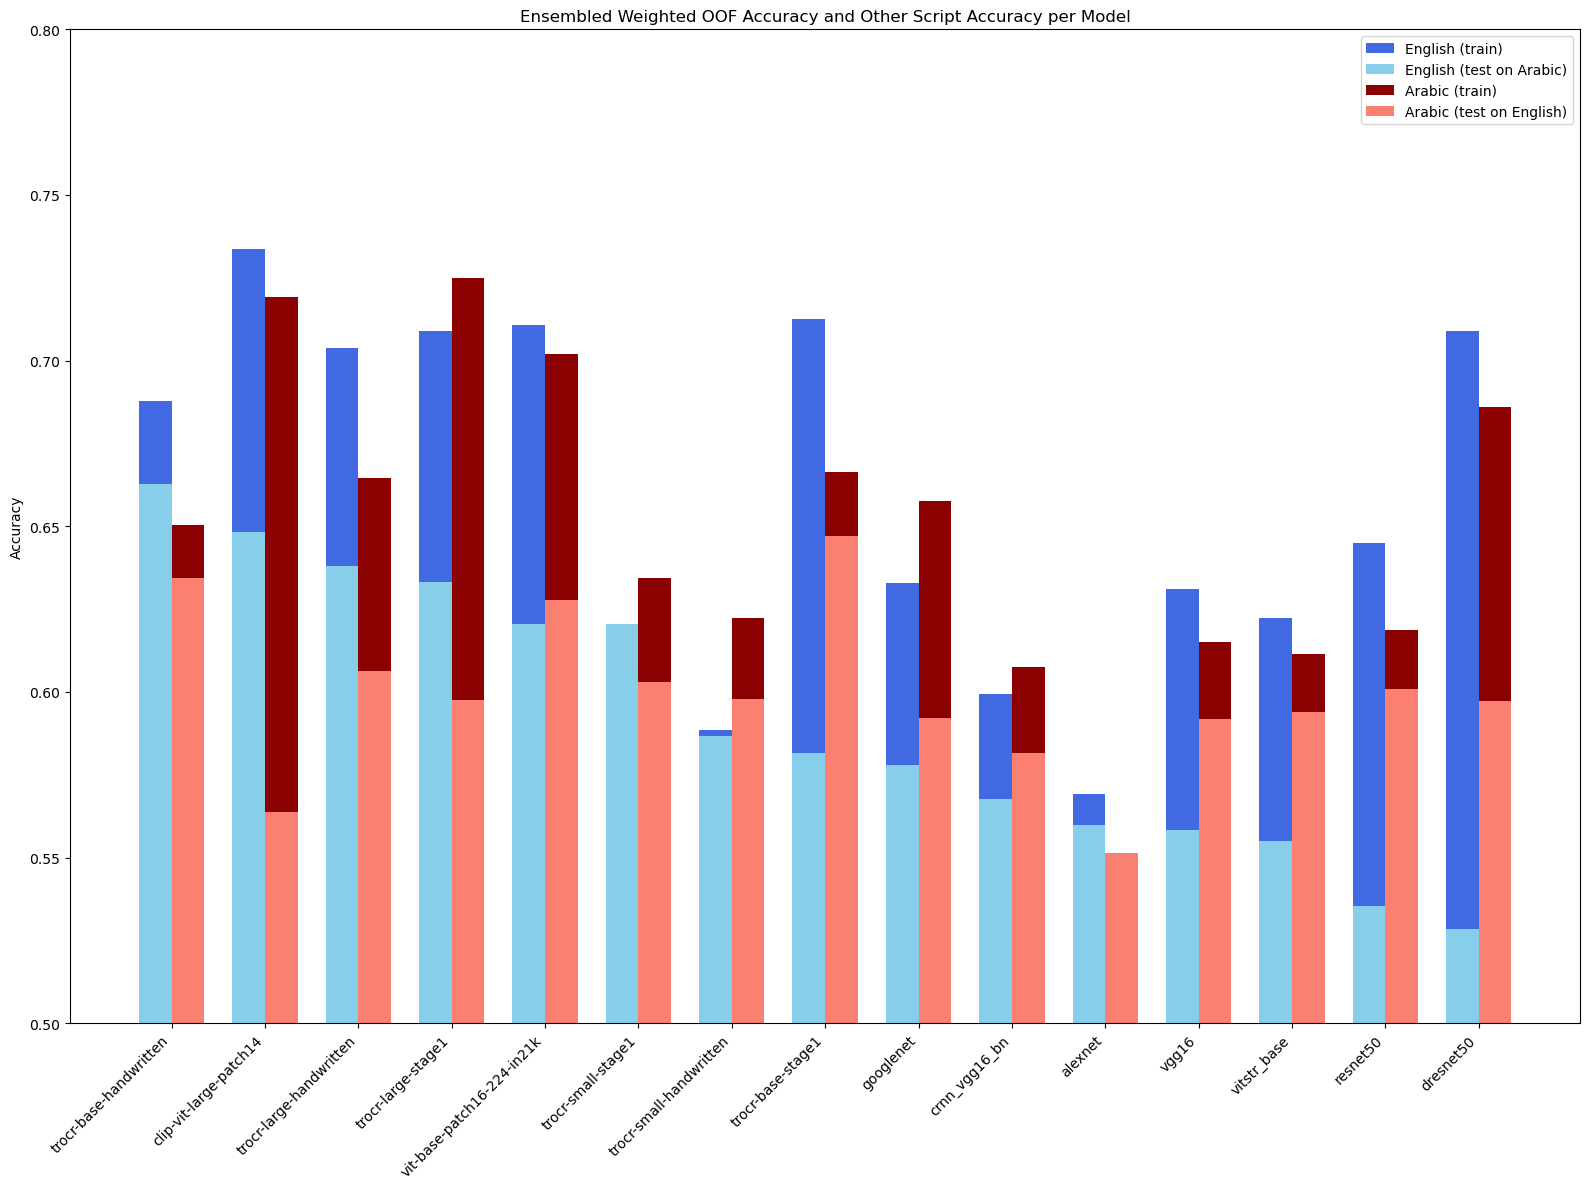

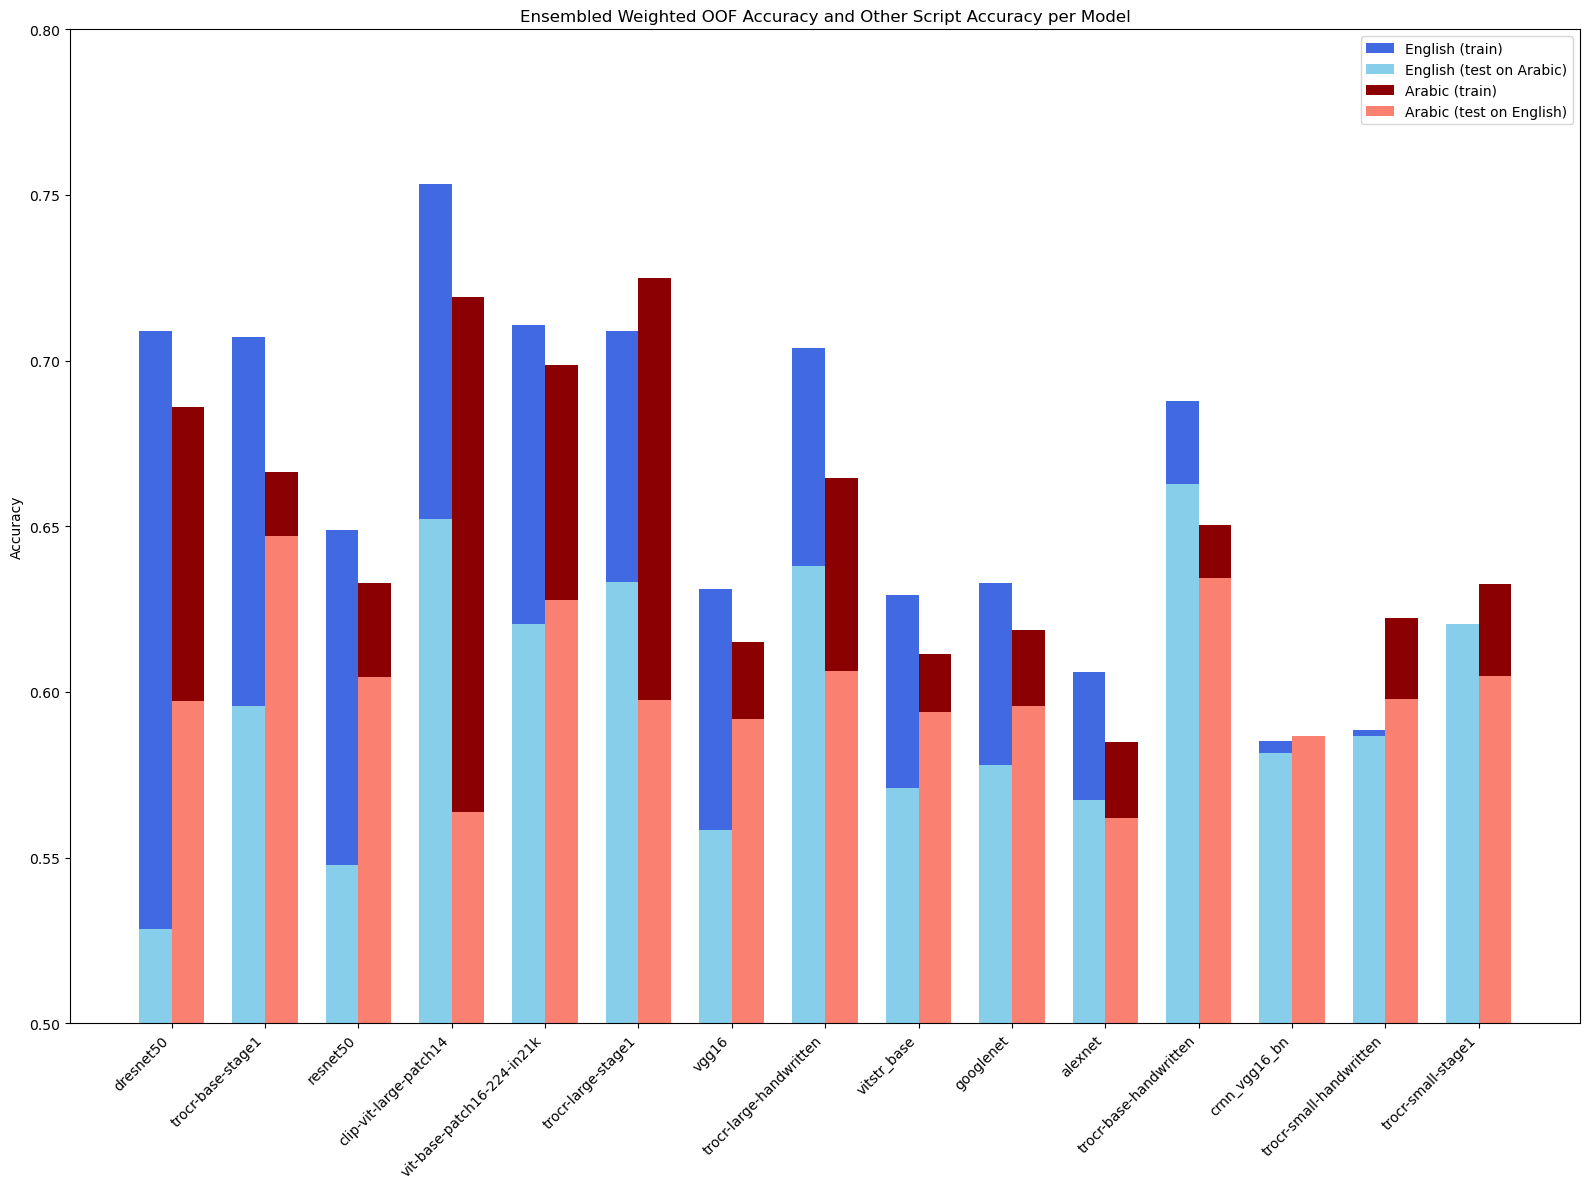

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

df_best_other_script = df_filtered.loc[df_filtered.groupby(['FE model','train_on_language'])['other_script'].idxmax()]
df_best_diff = df_filtered.loc[df_filtered.groupby(['FE model','train_on_language'])['other_script'].idxmax()]
#display(df_best_other_script[features_of_interest+[english_metric,arabic_metric,'other_script','other_script_individual']].sort_values('other_script', ascending=False))
# Prepare data
plot_double_bars_script_gen(df_best_other_script)
plot_double_bars_script_gen(df_best_diff,sort='script_generalization')

### sentences

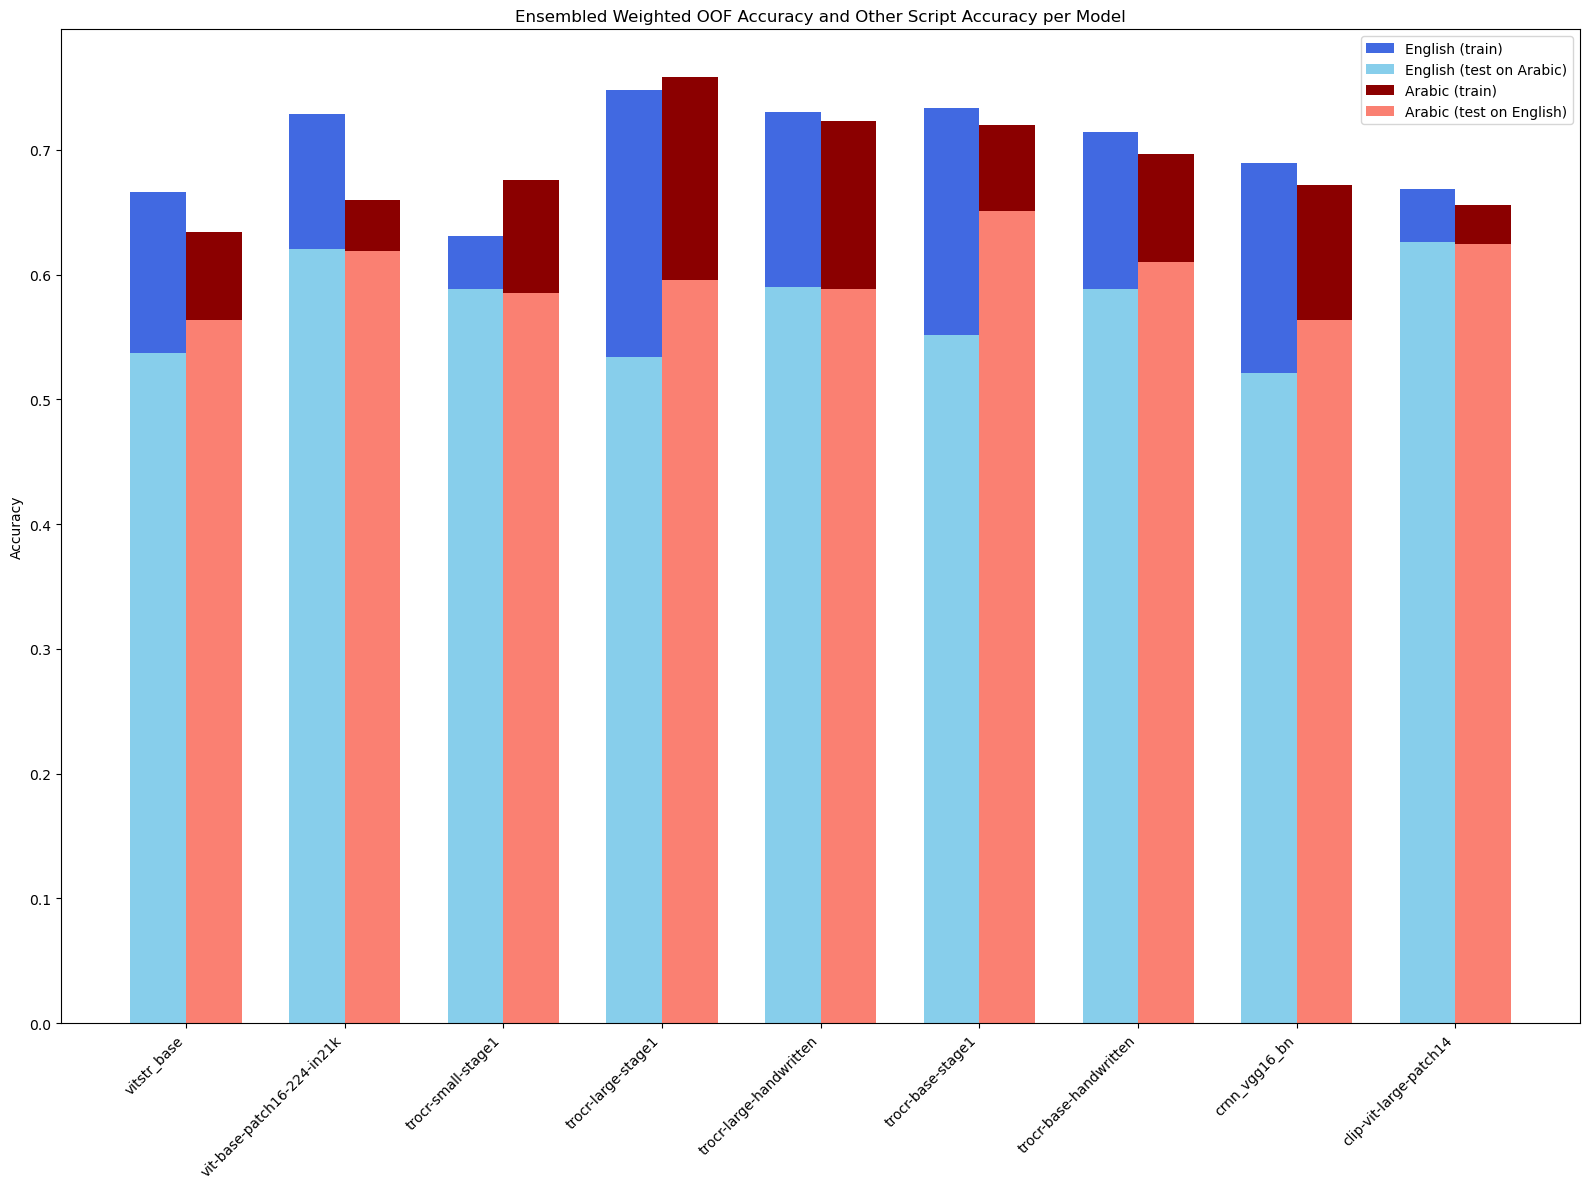

In [259]:
df_filtered=df[df['type'] == 'sentences']
df_best_other_script = df_filtered.loc[df_filtered.groupby(['FE model','train_on_language'])['other_script'].idxmax()]
#display(df_best_other_script[features_of_interest+[english_metric,arabic_metric,'other_script','other_script_individual']].sort_values('other_script', ascending=False))
# Prepare data
plot_double_bars_script_gen(df_best_other_script)

In [ ]:
#write a function to compare the bars on different types of input files
sentence_models=df_filtered['FE model'].unique()
df_filtered=df[df['FE model'].isin(sentence_models)]
df_best_other_script = df_filtered.loc[df_filtered.groupby(['FE model','type'])['other_script'].idxmax()]
#display(df_best_other_script[features_of_interest+[english_metric,arabic_metric,'other_script','other_script_individual']].sort_values('other_script', ascending=False))
# Prepare data
plot_double_bars_script_gen(df_best_other_script)

### body

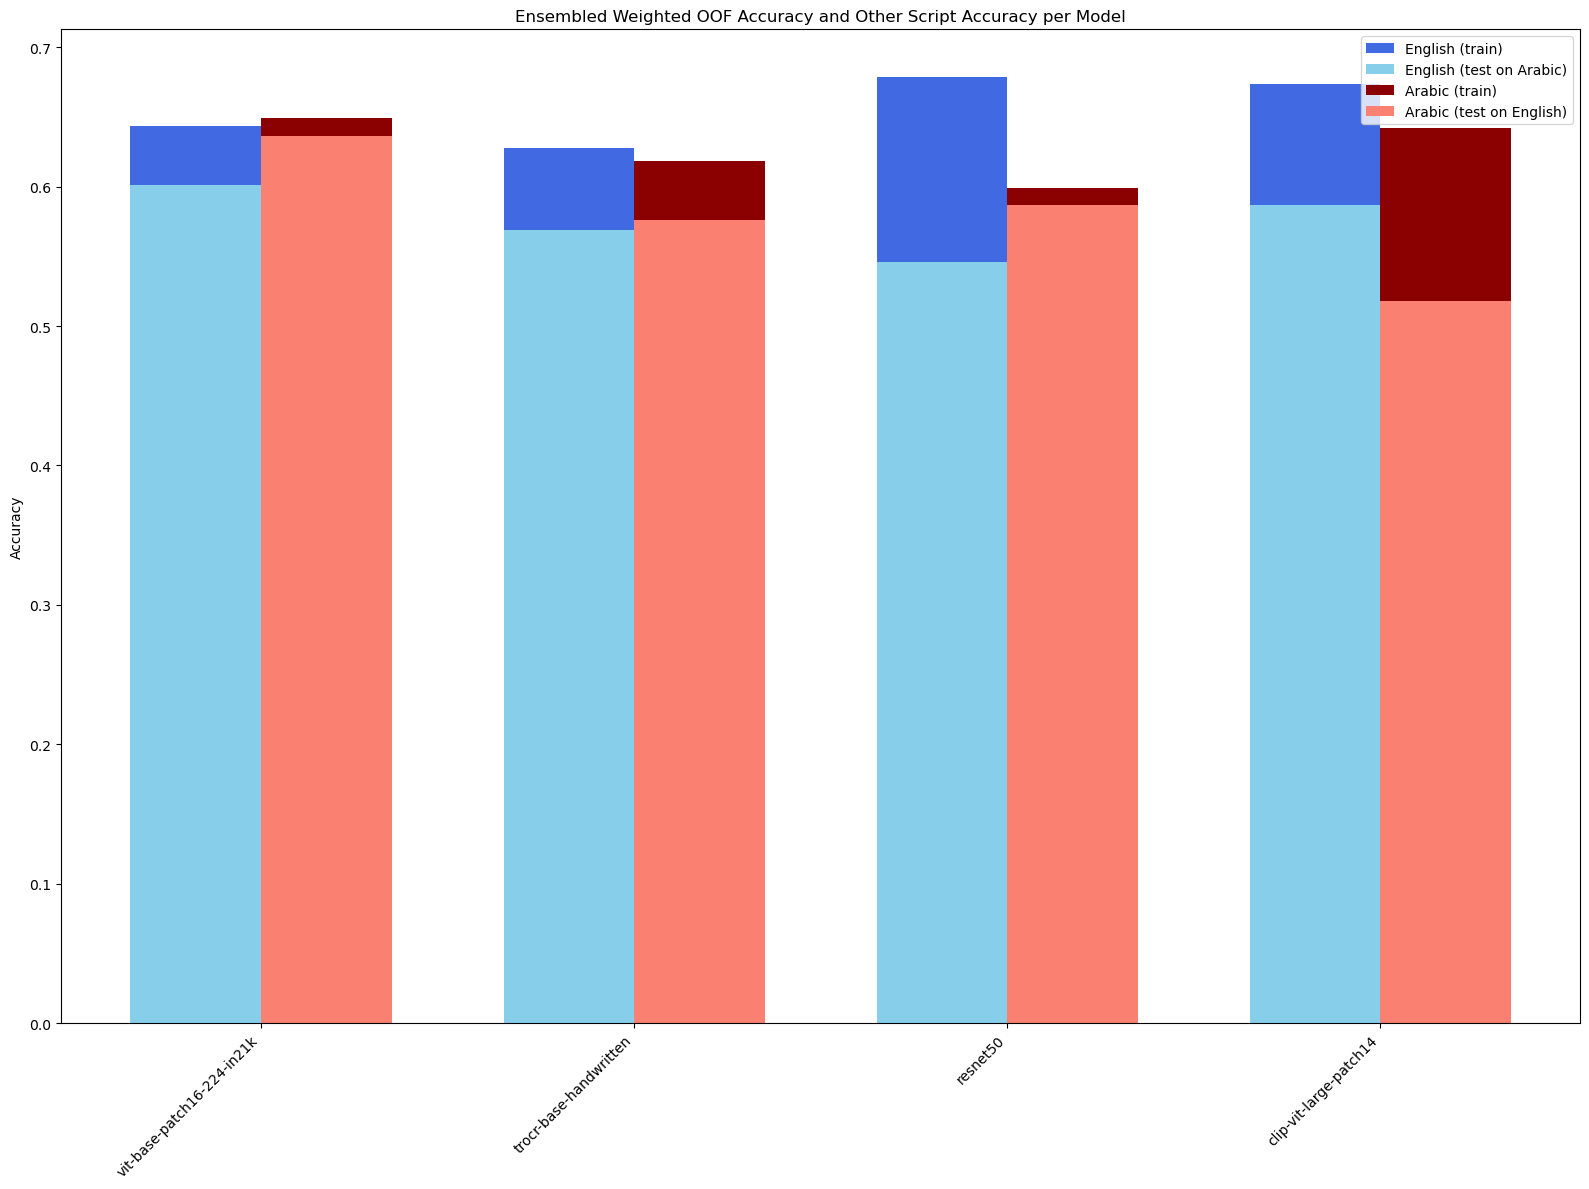

In [260]:
df_filtered=df[df['type'] == 'body']
df_best_other_script = df_filtered.loc[df_filtered.groupby(['FE model','train_on_language'])['other_script'].idxmax()]
#display(df_best_other_script[features_of_interest+[english_metric,arabic_metric,'other_script','other_script_individual']].sort_values('other_script', ascending=False))
# Prepare data
plot_double_bars_script_gen(df_best_other_script)

## experiment 8

In [291]:
experiment=feature_files[7]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','classifier model','with PCA']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
print(df['cross_val_accuracies'][0])
print(df['cross_val_accuracies'][1])

{'IF': [{'individual': 0.6951111111111111, 'ensembled': 0.7622222222222222, 'ensembled_weighted': 0.7644444444444445, 'ensembled_most_probable': 0.7511111111111111, 'ensembled_writers': 0.8444444444444444}, {'individual': 0.6873333333333334, 'ensembled': 0.7333333333333333, 'ensembled_weighted': 0.7477777777777778, 'ensembled_most_probable': 0.7477777777777778, 'ensembled_writers': 0.8177777777777778}, {'individual': 0.6980088495575221, 'ensembled': 0.7522123893805309, 'ensembled_weighted': 0.7632743362831859, 'ensembled_most_probable': 0.7643805309734514, 'ensembled_writers': 0.8628318584070797}, {'individual': 0.6805309734513274, 'ensembled': 0.7278761061946902, 'ensembled_weighted': 0.7345132743362832, 'ensembled_most_probable': 0.7345132743362832, 'ensembled_writers': 0.8185840707964602}, {'individual': 0.6933628318584071, 'ensembled': 0.75, 'ensembled_weighted': 0.7566371681415929, 'ensembled_most_probable': 0.7389380530973452, 'ensembled_writers': 0.8451327433628318}], 'OOF': [{'

### experiment

In [292]:
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


In [293]:
features_of_interest = ['FE model','classifier model','with PCA']
df=df_exp[features_of_interest+selected_accuracies]

In [294]:
# Split the 'FE model' column into two new columns: model_1 and model_2
df['FE model'] = df['FE model'].astype(str)
df[['model_1', 'model_2']] = df['FE model'].str.strip('[]').str.split(',', expand=True)
df['model_1'] = df['model_1'].str.strip().str.replace("'", "")
df['model_2'] = df['model_2'].str.strip().str.replace("'", "")
df[['FE model', 'model_1', 'model_2']].head()

C:\Users\andre\AppData\Local\Temp\ipykernel_32044\509401059.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['FE model'] = df['FE model'].astype(str)
C:\Users\andre\AppData\Local\Temp\ipykernel_32044\509401059.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['model_1', 'model_2']] = df['FE model'].str.strip('[]').str.split(',', expand=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_32044\509401059.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

,FE model,model_1,model_2
0,"['trocr-small-stage1', 'trocr-small-handwritten']",trocr-small-stage1,trocr-small-handwritten
1,"['trocr-small-stage1', 'trocr-small-handwritten']",trocr-small-stage1,trocr-small-handwritten
2,"['trocr-small-stage1', 'trocr-small-handwritten']",trocr-small-stage1,trocr-small-handwritten
3,"['trocr-small-stage1', 'trocr-small-handwritten']",trocr-small-stage1,trocr-small-handwritten
4,"['trocr-small-stage1', 'resnet50']",trocr-small-stage1,resnet50


In [295]:
df[features_of_interest+['ensembled_weighted_OOF_accuracy_Mean']].sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False).head(20)

,FE model,classifier model,with PCA,ensembled_weighted_OOF_accuracy_Mean
240,"['clip-vit-large-patch14', 'trocr-large-handwr...",logreg,True,0.756861
270,"['clip-vit-large-patch14', 'trocr-large-stage1']",mlp,True,0.756767
268,"['clip-vit-large-patch14', 'trocr-large-stage1']",logreg,True,0.755999
243,"['clip-vit-large-patch14', 'trocr-large-handwr...",mlp,False,0.751519
271,"['clip-vit-large-patch14', 'trocr-large-stage1']",mlp,False,0.750674
163,"['vit-base-patch16-224-in21k', 'clip-vit-large...",mlp,False,0.744612
68,"['trocr-small-handwritten', 'clip-vit-large-pa...",logreg,True,0.744455
242,"['clip-vit-large-patch14', 'trocr-large-handwr...",mlp,True,0.742638
200,"['trocr-base-handwritten', 'clip-vit-large-pat...",logreg,True,0.741761
255,"['clip-vit-large-patch14', 'vitstr_base']",mlp,False,0.741040


In [296]:
# Group by model_1 and get the row with the highest ensembled_weighted_OOF_accuracy_Mean for each group
idx = df.groupby('model_1')['ensembled_weighted_OOF_accuracy_Mean'].idxmax()
best_rows = df.loc[idx, ['model_1', 'model_2', 'ensembled_weighted_OOF_accuracy_Mean']]

# Show model_1, model_2, and the corresponding accuracy
display(best_rows.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False))

,model_1,model_2,ensembled_weighted_OOF_accuracy_Mean
240,clip-vit-large-patch14,trocr-large-handwritten,0.756861
163,vit-base-patch16-224-in21k,clip-vit-large-patch14,0.744612
68,trocr-small-handwritten,clip-vit-large-patch14,0.744455
200,trocr-base-handwritten,clip-vit-large-patch14,0.741761
116,resnet50,clip-vit-large-patch14,0.728556
328,dresnet50,trocr-large-stage1,0.728399
19,trocr-small-stage1,clip-vit-large-patch14,0.726786
301,trocr-large-handwritten,trocr-large-stage1,0.724060
372,vitstr_base,trocr-large-stage1,0.723136
416,trocr-large-stage1,trocr-base-stage1,0.720489


### compare with 1

In [297]:
df_8=df[['model_1', 'model_2']+features_of_interest+['ensembled_weighted_OOF_accuracy_Mean','individual_OOF_accuracy_Mean']].sort_values(['model_1','classifier model','with PCA'], ascending=False)

In [298]:
df_1 = load_df(feature_files[0],0)

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [299]:
merge_cols=['FE model', 'classifier model', 'with PCA', 'ensembled_weighted_OOF_accuracy_Mean','individual_OOF_accuracy_Mean']
print(len(df_1), len(df_8))
df_8 = df_8.merge(df_1[merge_cols], left_on=['model_1', 'classifier model', 'with PCA'], right_on = ['FE model','classifier model', 'with PCA'], suffixes=('', '_1'))

90 420


In [300]:
print(df_8.columns)
print(len(df_8))

Index(['model_1', 'model_2', 'FE model', 'classifier model', 'with PCA',
       'ensembled_weighted_OOF_accuracy_Mean', 'individual_OOF_accuracy_Mean',
       'FE model_1', 'ensembled_weighted_OOF_accuracy_Mean_1',
       'individual_OOF_accuracy_Mean_1'],
      dtype='object')
420


In [301]:
df_8 = df_8.merge(df_1[merge_cols], left_on=['model_2', 'classifier model', 'with PCA'], right_on = ['FE model','classifier model', 'with PCA'], suffixes=('', '_2'))

In [306]:
print(len(df_8))

420


In [302]:
df_8['difference_1']= df_8['ensembled_weighted_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_1']
df_8['difference_2']= df_8['ensembled_weighted_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_2']
df_8['difference_individual_1']= df_8['individual_OOF_accuracy_Mean'] - df_8['individual_OOF_accuracy_Mean_1']
df_8['difference_individual_2']= df_8['individual_OOF_accuracy_Mean'] - df_8['individual_OOF_accuracy_Mean_2']
df_8['difference'] = df_8[['difference_1', 'difference_2']].min(axis=1)
df_8['difference_individual'] = df_8[['difference_individual_1', 'difference_individual_2']].min(axis=1)
df_8 = df_8.sort_values(['model_1', 'classifier model', 'with PCA'], ascending=False)
to_show = df_8[['model_1', 'classifier model', 'with PCA','model_2'
                , 'ensembled_weighted_OOF_accuracy_Mean', 
                'individual_OOF_accuracy_Mean', 'difference', 'difference_individual']].sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False)

In [303]:
def highlight_diff(val):
    if val > 0:
        return 'background-color: lightgreen'
    elif val < 0:
        return 'background-color: salmon'
    return ''

styled = to_show.sort_values('difference', ascending=False).style.applymap(highlight_diff, subset=['difference', 'difference_individual'])
display(styled)

C:\Users\andre\AppData\Local\Temp\ipykernel_32044\1344767391.py:8: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = to_show.sort_values('difference', ascending=False).style.applymap(highlight_diff, subset=['difference', 'difference_individual'])


,model_1,classifier model,with PCA,model_2,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,difference,difference_individual
138,trocr-small-handwritten,mlp,True,crnn_vgg16_bn,0.640868,0.587027,0.046914,0.016081
320,dresnet50,mlp,True,googlenet,0.700047,0.642848,0.039897,0.028528
203,trocr-large-handwritten,mlp,False,trocr-base-stage1,0.715226,0.666313,0.032942,0.024167
152,trocr-small-handwritten,mlp,False,vitstr_base,0.641917,0.583565,0.032033,0.020780
273,resnet50,mlp,False,trocr-base-handwritten,0.692074,0.637550,0.031798,0.023603
284,resnet50,logreg,True,vit-base-patch16-224-in21k,0.714364,0.652964,0.030874,-0.002284
45,vit-base-patch16-224-in21k,logreg,True,dresnet50,0.712531,0.677002,0.029041,0.021754
346,crnn_vgg16_bn,mlp,True,vgg16,0.664693,0.606071,0.028352,0.004630
204,trocr-large-handwritten,logreg,True,dresnet50,0.709837,0.657005,0.028305,0.019370
334,dresnet50,logreg,True,googlenet,0.708913,0.654392,0.027381,0.016758


In [304]:
#to_show.describe()
to_show[to_show['difference']>0].describe()

,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,difference,difference_individual
count,174.000000,174.000000,174.000000,174.000000
mean,0.684050,0.633623,0.011011,0.004663
std,0.035555,0.031704,0.008817,0.009542
min,0.604480,0.560401,0.000016,-0.018070
25%,0.657863,0.610202,0.004429,-0.001248
50%,0.684618,0.635562,0.008897,0.004903
75%,0.709872,0.654999,0.016013,0.010897
max,0.756861,0.701053,0.046914,0.028528


In [305]:
num_positive = (to_show[to_show['classifier model']=='mlp']['difference'] > 0).sum()
num_negative = (to_show[to_show['classifier model']=='mlp']['difference'] < 0).sum()
#num_positive = (to_show[to_show['with PCA']==True]['difference'] > 0).sum()
#num_negative = (to_show[to_show['with PCA']==True]['difference'] < 0).sum()
#num_positive = (to_show['difference'] > 0).sum()
#num_negative = (to_show['difference'] < 0).sum()
print(f"Number of positive differences: {num_positive}")
print(f"Number of negative differences: {num_negative}")
print(num_positive/(num_positive + num_negative))

Number of positive differences: 95
Number of negative differences: 113
0.4567307692307692


## experiment 9

In [40]:
experiment=feature_files[8]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source_double(df,df_pre_patch,columns=['unique name', 'type']) #become unique name_1, type_1, unique name_2, type_2

In [41]:
features_of_interest = ['FE model','classifier model','with PCA','unique name_1','type_1','unique name_2','type_2']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies_exp_9(df,all_groups)
print(list(df_exp.columns))
#selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
#print(selected_accuracies)

['FE model', 'classifier model', 'with PCA', 'unique name_1', 'type_1', 'unique name_2', 'type_2', 'cross_val_accuracies', 'cross_val_subgroup_accuracies', '_IF_accuracy_Mean', '_IF_accuracy_Variance', '_IF_accuracy_Min', '_IF_accuracy_Max', '_IF_accuracy_Median', '_IF_accuracy_Confidence Interval', '_OOF_accuracy_Mean', '_OOF_accuracy_Variance', '_OOF_accuracy_Min', '_OOF_accuracy_Max', '_OOF_accuracy_Median', '_OOF_accuracy_Confidence Interval', '_Generalization Gap', 'english,different_IF_accuracy_Mean', 'english,different_IF_accuracy_Variance', 'english,different_IF_accuracy_Min', 'english,different_IF_accuracy_Max', 'english,different_IF_accuracy_Median', 'english,different_IF_accuracy_Confidence Interval', 'english,different_OOF_accuracy_Mean', 'english,different_OOF_accuracy_Variance', 'english,different_OOF_accuracy_Min', 'english,different_OOF_accuracy_Max', 'english,different_OOF_accuracy_Median', 'english,different_OOF_accuracy_Confidence Interval', 'english,different_Genera

In [42]:
selected_accuracies = ['_IF_accuracy_Mean','_OOF_accuracy_Mean','_Generalization Gap']
df=df_exp[features_of_interest+selected_accuracies]
# Duplicate rows with type_1 <-> type_2 and unique name_1 <-> unique name_2 swapped
df_swapped = df.copy()
df_swapped = df_swapped.rename(columns={
    'type_1': 'type_2', 'type_2': 'type_1',
    'unique name_1': 'unique name_2', 'unique name_2': 'unique name_1'
})
# Reorder columns to match original order
df_swapped = df_swapped[features_of_interest + selected_accuracies]
# Concatenate original and swapped DataFrames
df_augmented = pd.concat([df, df_swapped], ignore_index=True)
df_augmented

,FE model,classifier model,with PCA,unique name_1,type_1,unique name_2,type_2,_IF_accuracy_Mean,_OOF_accuracy_Mean,_Generalization Gap
0,clip-vit-large-patch14,logreg,False,body_gwnan_m1.0_idx1,body,squares_gw5.0_m5.0_idx2,squares,0.946585,0.671679,0.274906
1,clip-vit-large-patch14,logreg,False,body_gwnan_m1.0_idx1,body,sentences_gwnan_m9.0_idx1,sentences,0.913564,0.636388,0.277177
2,clip-vit-large-patch14,logreg,False,body_gwnan_m1.0_idx1,body,squares_gw15.0_m5.0_idx1,squares,0.931962,0.631877,0.300085
3,clip-vit-large-patch14,logreg,False,body_gwnan_m1.0_idx1,body,squares_gw45.0_m5.0_idx1,squares,0.930415,0.620410,0.310005
4,clip-vit-large-patch14,logreg,False,body_gwnan_m1.0_idx1,body,squares_gw35.0_m5.0_idx1,squares,0.926427,0.607096,0.319331
5,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,sentences_gwnan_m9.0_idx1,sentences,0.866349,0.701049,0.165300
6,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,squares_gw15.0_m5.0_idx1,squares,0.884744,0.684947,0.199798
7,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,squares_gw45.0_m5.0_idx1,squares,0.877654,0.688596,0.189057
8,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,squares_gw35.0_m5.0_idx1,squares,0.872776,0.671789,0.200987
9,clip-vit-large-patch14,logreg,False,sentences_gwnan_m9.0_idx1,sentences,squares_gw15.0_m5.0_idx1,squares,0.851058,0.654856,0.196202


### clipvit

In [43]:
import matplotlib

df_filtered= df_augmented[df_augmented['FE model'] == 'clip-vit-large-patch14']
df_filtered.sort_values('_OOF_accuracy_Mean', ascending=False, inplace=True)
grouped = df_filtered.sort_values(['unique name_1','_OOF_accuracy_Mean'],ascending=False)[['unique name_1','unique name_2', '_OOF_accuracy_Mean']]

#Color the table: highlight each group (by unique name_1) with a different color

def highlight_group_multicolor(df):
    # Use a colormap for distinct colors
    cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))
    colors = [matplotlib.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]
    group_colors = {name: color for name, color in zip(df['unique name_1'].unique(), colors)}
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for name, group in df.groupby('unique name_1'):
        idxs = group.index
        styles.loc[idxs, :] = f'background-color: {group_colors[name]}'
    return styles

grouped_styled = grouped.style.apply(highlight_group_multicolor, axis=None)
grouped_styled


C:\Users\andre\AppData\Local\Temp\ipykernel_37052\215645214.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values('_OOF_accuracy_Mean', ascending=False, inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_37052\215645214.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))


,unique name_1,unique name_2,_OOF_accuracy_Mean
5,squares_gw5.0_m5.0_idx2,sentences_gwnan_m9.0_idx1,0.701049
7,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,0.688596
6,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,0.684947
8,squares_gw5.0_m5.0_idx2,squares_gw35.0_m5.0_idx1,0.671789
18,squares_gw5.0_m5.0_idx2,body_gwnan_m1.0_idx1,0.671679
25,squares_gw45.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,0.688596
30,squares_gw45.0_m5.0_idx1,squares_gw15.0_m5.0_idx1,0.646883
28,squares_gw45.0_m5.0_idx1,sentences_gwnan_m9.0_idx1,0.642654
14,squares_gw45.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,0.627694
21,squares_gw45.0_m5.0_idx1,body_gwnan_m1.0_idx1,0.620410


### comparison with 1

In [44]:
df_3 = load_df(feature_files[2],2)
df_6 = load_df(feature_files[5],5)
df_6=df_6[df_6['n_sub_patches']==-1]
df_1 = pd.concat([df_3, df_6], axis=0, ignore_index=True)

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [45]:
df_1.columns

Index(['experiment', 'FE model', 'classifier model', 'with PCA', 'unique name',
       'type', 'n_sub_patches', 'individual_OOF_accuracy_Mean',
       'individual_Generalization Gap', 'ensembled_weighted_OOF_accuracy_Mean',
       'ensembled_weighted_Generalization Gap'],
      dtype='object')

In [70]:
df_filtered.head()

,FE model,classifier model,with PCA,unique name_1,type_1,unique name_2,type_2,_IF_accuracy_Mean,_OOF_accuracy_Mean,_Generalization Gap
5,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,sentences_gwnan_m9.0_idx1,sentences,0.866349,0.701049,0.165300
23,clip-vit-large-patch14,logreg,False,sentences_gwnan_m9.0_idx1,sentences,squares_gw5.0_m5.0_idx2,squares,0.866349,0.701049,0.165300
25,clip-vit-large-patch14,logreg,False,squares_gw45.0_m5.0_idx1,squares,squares_gw5.0_m5.0_idx2,squares,0.877654,0.688596,0.189057
7,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,squares_gw45.0_m5.0_idx1,squares,0.877654,0.688596,0.189057
6,clip-vit-large-patch14,logreg,False,squares_gw5.0_m5.0_idx2,squares,squares_gw15.0_m5.0_idx1,squares,0.884744,0.684947,0.199798


In [90]:
merge_cols=['FE model', 'classifier model', 'with PCA', 'ensembled_weighted_OOF_accuracy_Mean','unique name']
df_8 = df.copy()
print(len(df_8),len(df_1))
df_8 = df_8.merge(df_1[merge_cols], left_on=['unique name_1', 'classifier model', 'with PCA', 'FE model'], 
                  right_on = ['unique name','classifier model', 'with PCA', 'FE model'], suffixes=('', '_1'))
print(len(df_8))
#print(df_8.columns)
#display(df_8[merge_cols+['unique name_1','unique name_2']])
df_8.drop(columns=['unique name'], inplace=True)
df_8 = df_8.merge(df_1[merge_cols], left_on=['unique name_2', 'classifier model', 'with PCA', 'FE model'], 
                  right_on = ['unique name','classifier model', 'with PCA', 'FE model'], suffixes=('', '_2'))
#df_8.drop(columns=['unique name'], inplace=True)
print(len(df_8))
print(df_8.columns)

18 23
20
21
Index(['FE model', 'classifier model', 'with PCA', 'unique name_1', 'type_1',
       'unique name_2', 'type_2', '_IF_accuracy_Mean', '_OOF_accuracy_Mean',
       '_Generalization Gap', 'ensembled_weighted_OOF_accuracy_Mean',
       'ensembled_weighted_OOF_accuracy_Mean_2', 'unique name'],
      dtype='object')


In [91]:
df_8['difference_1']= df_8['_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean']
df_8['difference_2']= df_8['_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_2'] 
df_8['difference'] = df_8[['difference_1', 'difference_2']].min(axis=1)
df_8['difference_max'] = df_8[['difference_1', 'difference_2']].max(axis=1)
to_show = df_8[['unique name_1', 'unique name_2'
                ,'classifier model', 'with PCA', '_OOF_accuracy_Mean', 'difference','difference_max']].sort_values('_OOF_accuracy_Mean', ascending=False)

In [92]:
to_show

,unique name_1,unique name_2,classifier model,with PCA,_OOF_accuracy_Mean,difference,difference_max
6,squares_gw5.0_m5.0_idx2,sentences_gwnan_m9.0_idx1,logreg,False,0.701049,-0.030874,0.026394
7,squares_gw5.0_m5.0_idx2,sentences_gwnan_m9.0_idx1,logreg,False,0.701049,-0.030874,0.026394
11,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,logreg,False,0.688596,-0.043327,0.046632
10,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,logreg,False,0.688596,-0.043327,0.046632
9,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,logreg,False,0.684947,-0.046977,0.006877
8,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,logreg,False,0.684947,-0.046977,0.006877
12,squares_gw5.0_m5.0_idx2,squares_gw35.0_m5.0_idx1,logreg,False,0.671789,-0.060135,0.043155
13,squares_gw5.0_m5.0_idx2,squares_gw35.0_m5.0_idx1,logreg,False,0.671789,-0.060135,0.043155
0,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,logreg,False,0.671679,-0.060244,0.049420
1,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,logreg,False,0.671679,-0.060244,0.049420


In [289]:
to_show.columns

Index(['unique name_1', 'unique name_2', 'classifier model', 'with PCA',
       '_OOF_accuracy_Mean', 'difference'],
      dtype='object')

In [290]:
def highlight_diff(val):
    if val > 0:
        return 'background-color: lightgreen'
    elif val < 0:
        return 'background-color: salmon'
    return ''

styled = to_show.sort_values('difference', ascending=False).style.applymap(highlight_diff, subset='difference')
display(styled)

C:\Users\andre\AppData\Local\Temp\ipykernel_32044\2343668028.py:8: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = to_show.sort_values('difference', ascending=False).style.applymap(highlight_diff, subset='difference')


,unique name_1,unique name_2,classifier model,with PCA,_OOF_accuracy_Mean,difference
11,squares_gw45.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,logreg,False,0.627694,-0.014270
10,squares_gw35.0_m5.0_idx1,squares_gw45.0_m5.0_idx1,logreg,False,0.627694,-0.014270
6,squares_gw15.0_m5.0_idx1,squares_gw45.0_m5.0_idx1,logreg,False,0.646883,-0.031187
7,squares_gw45.0_m5.0_idx1,squares_gw15.0_m5.0_idx1,logreg,False,0.646883,-0.031187
9,squares_gw35.0_m5.0_idx1,squares_gw15.0_m5.0_idx1,logreg,False,0.635432,-0.042638
8,squares_gw15.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,logreg,False,0.635432,-0.042638
1,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,logreg,False,0.688596,-0.043327
0,squares_gw45.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,logreg,False,0.688596,-0.043327
3,squares_gw15.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,logreg,False,0.684947,-0.046977
2,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,logreg,False,0.684947,-0.046977


### resnet50

In [284]:
df_filtered= df_augmented[df_augmented['FE model'] == 'resnet50']
df_filtered.sort_values('_OOF_accuracy_Mean', ascending=False, inplace=True)
grouped = df_filtered.sort_values(['unique name_1','_OOF_accuracy_Mean'],ascending=False)[['unique name_1','unique name_2', '_OOF_accuracy_Mean']]

#Color the table: highlight each group (by unique name_1) with a different color

def highlight_group_multicolor(df):
    # Use a colormap for distinct colors
    cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))
    colors = [matplotlib.colors.rgb2hex(cmap(i)) for i in range(cmap.N)]
    group_colors = {name: color for name, color in zip(df['unique name_1'].unique(), colors)}
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for name, group in df.groupby('unique name_1'):
        idxs = group.index
        styles.loc[idxs, :] = f'background-color: {group_colors[name]}'
    return styles

grouped_styled = grouped.style.apply(highlight_group_multicolor, axis=None)
grouped_styled


C:\Users\andre\AppData\Local\Temp\ipykernel_32044\2925569271.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values('_OOF_accuracy_Mean', ascending=False, inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_32044\2925569271.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))


,unique name_1,unique name_2,_OOF_accuracy_Mean
35,squares_gw5.0_m5.0_idx2,body_gwnan_m1.0_idx1,0.639865
34,squares_gw5.0_m5.0_idx2,squares_gw10.0_m5.0_idx1,0.625736
15,squares_gw10.0_m5.0_idx1,body_gwnan_m1.0_idx1,0.641729
16,squares_gw10.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,0.625736
33,body_gwnan_m1.0_idx1,squares_gw10.0_m5.0_idx1,0.641729
17,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,0.639865


## experiment 10

In [190]:
experiment=feature_files[9]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source_double(df,df_pre_patch,columns=['unique name', 'type']) #become unique name_1, type_1, unique name_2, type_2
features_of_interest = ['FE model','classifier model','with PCA','type_1','type_2','unique name_1','unique name_2']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
print(df['cross_val_accuracies'][0])
print(df['cross_val_accuracies'][1])
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
df=df_exp[features_of_interest+selected_accuracies]

{'IF': [{'individual': 0.8766666666666667, 'ensembled': 0.8766666666666667, 'ensembled_weighted': 0.8766666666666667, 'ensembled_most_probable': 0.8766666666666667, 'ensembled_writers': 0.9066666666666666}, {'individual': 0.8877777777777778, 'ensembled': 0.8877777777777778, 'ensembled_weighted': 0.8877777777777778, 'ensembled_most_probable': 0.8877777777777778, 'ensembled_writers': 0.9466666666666667}, {'individual': 0.9070796460176991, 'ensembled': 0.9070796460176991, 'ensembled_weighted': 0.9070796460176991, 'ensembled_most_probable': 0.9070796460176991, 'ensembled_writers': 0.9601769911504425}, {'individual': 0.8971238938053098, 'ensembled': 0.8971238938053098, 'ensembled_weighted': 0.8971238938053098, 'ensembled_most_probable': 0.8971238938053098, 'ensembled_writers': 0.9513274336283186}, {'individual': 0.9092920353982301, 'ensembled': 0.9092920353982301, 'ensembled_weighted': 0.9092920353982301, 'ensembled_most_probable': 0.9092920353982301, 'ensembled_writers': 0.9690265486725663

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

In [191]:
selected_accuracies = ['individual_OOF_accuracy_Mean','ensembled_weighted_OOF_accuracy_Mean','ensembled_weighted_Generalization Gap']
df=df_exp[features_of_interest+selected_accuracies]
# Duplicate rows with type_1 <-> type_2 and unique name_1 <-> unique name_2 swapped
df_swapped = df.copy()
df_swapped = df_swapped.rename(columns={
    'type_1': 'type_2', 'type_2': 'type_1',
    'unique name_1': 'unique name_2', 'unique name_2': 'unique name_1'
})
# Reorder columns to match original order
df_swapped = df_swapped[features_of_interest + selected_accuracies]
# Concatenate original and swapped DataFrames
df_augmented = pd.concat([df, df_swapped], ignore_index=True)

### clipvit

In [192]:
df_filtered= df_augmented[df_augmented['FE model'] == 'clip-vit-large-patch14']
df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
# Group by unique name_1 and unique name_2, select the row with the highest ensembled_weighted_OOF_accuracy_Mean for each group
df_filtered = df_filtered.loc[df_filtered.groupby(['unique name_1', 'unique name_2'])['ensembled_weighted_OOF_accuracy_Mean'].idxmax()]
grouped = df_filtered.sort_values(['unique name_1','ensembled_weighted_OOF_accuracy_Mean'],ascending=False)[['unique name_1','unique name_2', 'ensembled_weighted_OOF_accuracy_Mean',
                                                                                                             'individual_OOF_accuracy_Mean','classifier model','with PCA']]

#Color the table: highlight each group (by unique name_1) with a different color

grouped_styled = grouped.style.apply(highlight_group_multicolor, axis=None)
grouped_styled

C:\Users\andre\AppData\Local\Temp\ipykernel_37052\3672037977.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_37052\215645214.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))


,unique name_1,unique name_2,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
22,squares_gw5.0_m5.0_idx2,sentences_gwnan_m9.0_idx1,0.710918,0.710918,mlp,True
75,squares_gw5.0_m5.0_idx2,body_gwnan_m1.0_idx1,0.705623,0.705623,mlp,False
35,squares_gw5.0_m5.0_idx2,squares_gw35.0_m5.0_idx1,0.704793,0.704793,mlp,False
30,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,0.699232,0.699232,mlp,True
26,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,0.694157,0.694157,mlp,True
102,squares_gw45.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,0.699232,0.699232,mlp,True
112,squares_gw45.0_m5.0_idx1,sentences_gwnan_m9.0_idx1,0.666682,0.666682,logreg,True
122,squares_gw45.0_m5.0_idx1,squares_gw15.0_m5.0_idx1,0.663847,0.663847,mlp,True
85,squares_gw45.0_m5.0_idx1,body_gwnan_m1.0_idx1,0.654041,0.654041,logreg,False
56,squares_gw45.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,0.617090,0.617090,logreg,True


### comparison

In [193]:
df_3 = load_df(feature_files[2],2)
df_6 = load_df(feature_files[5],5)
df_6=df_6[df_6['n_sub_patches']==-1]
df_1 = pd.concat([df_3, df_6], axis=0, ignore_index=True)
merge_cols=['FE model', 'ensembled_weighted_OOF_accuracy_Mean','unique name']
df_8 = df.copy()
print(len(df_8),len(df_1))
df_8 = df_8.merge(df_1[merge_cols], left_on=['unique name_1', 'FE model'], 
                  right_on = ['unique name', 'FE model'], suffixes=('', '_1'))
print(len(df_8))
#print(df_8.columns)
#display(df_8[merge_cols+['unique name_1','unique name_2']])
df_8.drop(columns=['unique name'], inplace=True)
df_8 = df_8.merge(df_1[merge_cols], left_on=['unique name_2', 'FE model'], 
                  right_on = ['unique name', 'FE model'], suffixes=('', '_2'))
#df_8.drop(columns=['unique name'], inplace=True)
print(len(df_8))
print(df_8.columns)
df_8['difference_1']= df_8['ensembled_weighted_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_1']
df_8['difference_2']= df_8['ensembled_weighted_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_2'] 
df_8['difference'] = df_8[['difference_1', 'difference_2']].min(axis=1)
df_8['difference_max'] = df_8[['difference_1', 'difference_2']].max(axis=1)
to_show = df_8[['unique name_1', 'unique name_2'
                ,'classifier model', 'with PCA', 'ensembled_weighted_OOF_accuracy_Mean', 'difference','difference_max']].sort_values('difference', ascending=False)

72 23
80
84
Index(['FE model', 'classifier model', 'with PCA', 'type_1', 'type_2',
       'unique name_1', 'unique name_2', 'individual_OOF_accuracy_Mean',
       'ensembled_weighted_OOF_accuracy_Mean',
       'ensembled_weighted_Generalization Gap',
       'ensembled_weighted_OOF_accuracy_Mean_1',
       'ensembled_weighted_OOF_accuracy_Mean_2', 'unique name'],
      dtype='object')


c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [194]:
display(to_show.head(20))

,unique name_1,unique name_2,classifier model,with PCA,ensembled_weighted_OOF_accuracy_Mean,difference,difference_max
81,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,logreg,False,0.664834,0.026754,0.036404
83,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,mlp,False,0.663784,0.025705,0.035354
17,body_gwnan_m1.0_idx1,squares_gw45.0_m5.0_idx1,logreg,False,0.654041,0.012077,0.031783
80,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,logreg,True,0.644314,0.006234,0.015883
20,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,logreg,True,0.634665,0.006031,0.012406
21,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,logreg,False,0.633004,0.004370,0.010746
22,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,mlp,True,0.632096,0.003462,0.009837
23,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,mlp,False,0.631971,0.003336,0.009712
19,body_gwnan_m1.0_idx1,squares_gw45.0_m5.0_idx1,mlp,False,0.640727,-0.001237,0.018468
15,body_gwnan_m1.0_idx1,squares_gw15.0_m5.0_idx1,mlp,False,0.670896,-0.007174,0.048637


In [195]:
max_diff_rows_10 = to_show.loc[to_show.groupby(['unique name_1', 'unique name_2'])['difference'].idxmax()]
display(max_diff_rows_10)

,unique name_1,unique name_2,classifier model,with PCA,ensembled_weighted_OOF_accuracy_Mean,difference,difference_max
10,body_gwnan_m1.0_idx1,sentences_gwnan_m9.0_idx1,mlp,True,0.650501,-0.024154,0.028242
15,body_gwnan_m1.0_idx1,squares_gw15.0_m5.0_idx1,mlp,False,0.670896,-0.007174,0.048637
20,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,logreg,True,0.634665,0.006031,0.012406
17,body_gwnan_m1.0_idx1,squares_gw45.0_m5.0_idx1,logreg,False,0.654041,0.012077,0.031783
81,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,logreg,False,0.664834,0.026754,0.036404
56,sentences_gwnan_m9.0_idx1,squares_gw15.0_m5.0_idx1,logreg,True,0.670034,-0.008036,-0.004621
67,sentences_gwnan_m9.0_idx1,squares_gw35.0_m5.0_idx1,mlp,False,0.645301,-0.029355,0.016667
60,sentences_gwnan_m9.0_idx1,squares_gw45.0_m5.0_idx1,logreg,True,0.666682,-0.007973,0.024718
75,squares_gw15.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,mlp,False,0.670332,-0.007738,0.041698
70,squares_gw15.0_m5.0_idx1,squares_gw45.0_m5.0_idx1,mlp,True,0.663847,-0.014223,0.021883


### resnet50

In [ ]:
df_filtered= df_augmented[df_augmented['FE model'] == 'resnet50']
df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
# Group by unique name_1 and unique name_2, select the row with the highest ensembled_weighted_OOF_accuracy_Mean for each group
df_filtered = df_filtered.loc[df_filtered.groupby(['unique name_1', 'unique name_2'])['ensembled_weighted_OOF_accuracy_Mean'].idxmax()]
grouped = df_filtered.sort_values(['unique name_1','ensembled_weighted_OOF_accuracy_Mean'],ascending=False)[['unique name_1','unique name_2', 'ensembled_weighted_OOF_accuracy_Mean',
                                                                                                             'individual_OOF_accuracy_Mean','classifier model','with PCA']]

#Color the table: highlight each group (by unique name_1) with a different color

grouped_styled = grouped.style.apply(highlight_group_multicolor, axis=None)
grouped_styled

C:\Users\andre\AppData\Local\Temp\ipykernel_27944\940439244.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_27944\940439244.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))


,unique name_1,unique name_2,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
137,squares_gw5.0_m5.0_idx2,squares_gw10.0_m5.0_idx1,0.665570,0.665570,logreg,False
141,squares_gw5.0_m5.0_idx2,body_gwnan_m1.0_idx1,0.664834,0.664834,logreg,False
65,squares_gw10.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,0.665570,0.665570,logreg,False
60,squares_gw10.0_m5.0_idx1,body_gwnan_m1.0_idx1,0.660182,0.660182,logreg,True
69,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,0.664834,0.664834,logreg,False
132,body_gwnan_m1.0_idx1,squares_gw10.0_m5.0_idx1,0.660182,0.660182,logreg,True


## experiment 11

In [182]:
experiment=feature_files[10]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source_double(df,df_pre_patch,columns=['unique name', 'type']) #become unique name_1, type_1, unique name_2, type_2
features_of_interest = ['FE model','classifier model','with PCA','unique name_1','type_1','unique name_2','type_2']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
df=df_exp[features_of_interest+selected_accuracies]

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

In [183]:
selected_accuracies = ['individual_OOF_accuracy_Mean','ensembled_weighted_OOF_accuracy_Mean','ensembled_weighted_Generalization Gap']
df=df_exp[features_of_interest+selected_accuracies]
# Duplicate rows with type_1 <-> type_2 and unique name_1 <-> unique name_2 swapped
df_swapped = df.copy()
df_swapped = df_swapped.rename(columns={
    'type_1': 'type_2', 'type_2': 'type_1',
    'unique name_1': 'unique name_2', 'unique name_2': 'unique name_1'
})
# Reorder columns to match original order
df_swapped = df_swapped[features_of_interest + selected_accuracies]
# Concatenate original and swapped DataFrames
df_augmented = pd.concat([df, df_swapped], ignore_index=True)

### clipvit

In [184]:
df_filtered= df_augmented[df_augmented['FE model'] == 'clip-vit-large-patch14']
df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
# Group by unique name_1 and unique name_2, select the row with the highest ensembled_weighted_OOF_accuracy_Mean for each group
df_filtered = df_filtered.loc[df_filtered.groupby(['unique name_1', 'unique name_2'])['ensembled_weighted_OOF_accuracy_Mean'].idxmax()]
grouped = df_filtered.sort_values(['unique name_1','ensembled_weighted_OOF_accuracy_Mean'],ascending=False)[['unique name_1','unique name_2', 'ensembled_weighted_OOF_accuracy_Mean',
                                                                                                             'individual_OOF_accuracy_Mean','classifier model','with PCA']]

#Color the table: highlight each group (by unique name_1) with a different color

grouped_styled = grouped.style.apply(highlight_group_multicolor, axis=None)
grouped_styled

C:\Users\andre\AppData\Local\Temp\ipykernel_37052\3672037977.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_37052\215645214.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))


,unique name_1,unique name_2,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
31,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,0.749828,0.680858,mlp,False
23,squares_gw5.0_m5.0_idx2,sentences_gwnan_m9.0_idx1,0.744580,0.685631,mlp,False
27,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,0.736513,0.681475,mlp,False
35,squares_gw5.0_m5.0_idx2,squares_gw35.0_m5.0_idx1,0.735589,0.677908,mlp,False
72,squares_gw5.0_m5.0_idx2,body_gwnan_m1.0_idx1,0.689505,0.675338,logreg,True
103,squares_gw45.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,0.749828,0.680858,mlp,False
120,squares_gw45.0_m5.0_idx1,squares_gw15.0_m5.0_idx1,0.714364,0.628142,logreg,True
113,squares_gw45.0_m5.0_idx1,sentences_gwnan_m9.0_idx1,0.684492,0.615961,logreg,False
56,squares_gw45.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,0.663972,0.598249,logreg,True
87,squares_gw45.0_m5.0_idx1,body_gwnan_m1.0_idx1,0.660150,0.646971,mlp,False


### comparison

In [185]:
df_3 = load_df(feature_files[2],2)
df_6 = load_df(feature_files[5],5)
df_6=df_6[df_6['n_sub_patches']==-1]
df_1 = pd.concat([df_3, df_6], axis=0, ignore_index=True)
merge_cols=['FE model', 'ensembled_weighted_OOF_accuracy_Mean','unique name']
df_8 = df.copy()
print(len(df_8),len(df_1))
df_8 = df_8.merge(df_1[merge_cols], left_on=['unique name_1', 'FE model'], 
                  right_on = ['unique name', 'FE model'], suffixes=('', '_1'))
print(len(df_8))
#print(df_8.columns)
#display(df_8[merge_cols+['unique name_1','unique name_2']])
df_8.drop(columns=['unique name'], inplace=True)
df_8 = df_8.merge(df_1[merge_cols], left_on=['unique name_2', 'FE model'], 
                  right_on = ['unique name', 'FE model'], suffixes=('', '_2'))
#df_8.drop(columns=['unique name'], inplace=True)
print(len(df_8))
print(df_8.columns)
df_8['difference_1']= df_8['ensembled_weighted_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_1']
df_8['difference_2']= df_8['ensembled_weighted_OOF_accuracy_Mean'] - df_8['ensembled_weighted_OOF_accuracy_Mean_2'] 
df_8['difference'] = df_8[['difference_1', 'difference_2']].min(axis=1)
df_8['difference_max'] = df_8[['difference_1', 'difference_2']].max(axis=1)
to_show = df_8[['unique name_1', 'unique name_2'
                ,'classifier model', 'with PCA', 'ensembled_weighted_OOF_accuracy_Mean', 'difference','difference_max']].sort_values('difference', ascending=False)

72 23
80
84
Index(['FE model', 'classifier model', 'with PCA', 'unique name_1', 'type_1',
       'unique name_2', 'type_2', 'individual_OOF_accuracy_Mean',
       'ensembled_weighted_OOF_accuracy_Mean',
       'ensembled_weighted_Generalization Gap',
       'ensembled_weighted_OOF_accuracy_Mean_1',
       'ensembled_weighted_OOF_accuracy_Mean_2', 'unique name'],
      dtype='object')


c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


In [186]:
max_diff_rows_11 = to_show.loc[to_show.groupby(['unique name_1', 'unique name_2'])['difference'].idxmax()]
display(max_diff_rows_11)

,unique name_1,unique name_2,classifier model,with PCA,ensembled_weighted_OOF_accuracy_Mean,difference,difference_max
10,body_gwnan_m1.0_idx1,sentences_gwnan_m9.0_idx1,mlp,True,0.672666,-0.001989,0.050407
15,body_gwnan_m1.0_idx1,squares_gw15.0_m5.0_idx1,mlp,False,0.678963,0.000893,0.056704
23,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,mlp,False,0.668327,0.039693,0.046068
19,body_gwnan_m1.0_idx1,squares_gw45.0_m5.0_idx1,mlp,False,0.660150,0.018186,0.037892
82,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,mlp,True,0.671836,0.033756,0.043405
56,sentences_gwnan_m9.0_idx1,squares_gw15.0_m5.0_idx1,logreg,True,0.701096,0.023026,0.026441
64,sentences_gwnan_m9.0_idx1,squares_gw35.0_m5.0_idx1,logreg,True,0.678055,0.003399,0.049420
61,sentences_gwnan_m9.0_idx1,squares_gw45.0_m5.0_idx1,logreg,False,0.684492,0.009837,0.042528
75,squares_gw15.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,mlp,False,0.687077,0.009007,0.058443
68,squares_gw15.0_m5.0_idx1,squares_gw45.0_m5.0_idx1,logreg,True,0.714364,0.036294,0.072400


In [187]:
max_diff_rows_compare = pd.merge(max_diff_rows_11,max_diff_rows_10, how='inner', on=['unique name_1', 'unique name_2'], suffixes=('_11', '_10'))
max_diff_rows_compare['delta']= max_diff_rows_compare['difference_11'] - max_diff_rows_compare['difference_10']

In [189]:
display(max_diff_rows_compare[['unique name_1','unique name_2','delta']].sort_values('delta', ascending=False))

,unique name_1,unique name_2,delta
14,squares_gw5.0_m5.0_idx2,squares_gw45.0_m5.0_idx1,0.050595
9,squares_gw15.0_m5.0_idx1,squares_gw45.0_m5.0_idx1,0.050517
10,squares_gw45.0_m5.0_idx1,squares_gw35.0_m5.0_idx1,0.046883
12,squares_gw5.0_m5.0_idx2,squares_gw15.0_m5.0_idx1,0.042356
11,squares_gw5.0_m5.0_idx2,sentences_gwnan_m9.0_idx1,0.033662
2,body_gwnan_m1.0_idx1,squares_gw35.0_m5.0_idx1,0.033662
6,sentences_gwnan_m9.0_idx1,squares_gw35.0_m5.0_idx1,0.032754
5,sentences_gwnan_m9.0_idx1,squares_gw15.0_m5.0_idx1,0.031062
13,squares_gw5.0_m5.0_idx2,squares_gw35.0_m5.0_idx1,0.030796
0,body_gwnan_m1.0_idx1,sentences_gwnan_m9.0_idx1,0.022165


### resnet50

In [112]:
df_filtered= df_augmented[df_augmented['FE model'] == 'resnet50']
df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
# Group by unique name_1 and unique name_2, select the row with the highest ensembled_weighted_OOF_accuracy_Mean for each group
df_filtered = df_filtered.loc[df_filtered.groupby(['unique name_1', 'unique name_2'])['ensembled_weighted_OOF_accuracy_Mean'].idxmax()]
grouped = df_filtered.sort_values(['unique name_1','ensembled_weighted_OOF_accuracy_Mean'],ascending=False)[['unique name_1','unique name_2', 'ensembled_weighted_OOF_accuracy_Mean',
                                                                                                             'individual_OOF_accuracy_Mean','classifier model','with PCA']]

#Color the table: highlight each group (by unique name_1) with a different color

grouped_styled = grouped.style.apply(highlight_group_multicolor, axis=None)
grouped_styled

C:\Users\andre\AppData\Local\Temp\ipykernel_27944\929662129.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values('ensembled_weighted_OOF_accuracy_Mean', ascending=False, inplace=True)
C:\Users\andre\AppData\Local\Temp\ipykernel_27944\940439244.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = matplotlib.cm.get_cmap('Pastel1', len(df['unique name_1'].unique()))


,unique name_1,unique name_2,ensembled_weighted_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
139,squares_gw5.0_m5.0_idx2,squares_gw10.0_m5.0_idx1,0.688581,0.639357,mlp,False
142,squares_gw5.0_m5.0_idx2,body_gwnan_m1.0_idx1,0.671836,0.656128,mlp,True
67,squares_gw10.0_m5.0_idx1,squares_gw5.0_m5.0_idx2,0.688581,0.639357,mlp,False
63,squares_gw10.0_m5.0_idx1,body_gwnan_m1.0_idx1,0.654214,0.653424,mlp,False
70,body_gwnan_m1.0_idx1,squares_gw5.0_m5.0_idx2,0.671836,0.656128,mlp,True
135,body_gwnan_m1.0_idx1,squares_gw10.0_m5.0_idx1,0.654214,0.653424,mlp,False


### comparing classifiers

In [74]:
# model specific (ensembled)
models = ['logreg', 'mlp', 'lgbm']
with_model=[]
accuracy_metric= 'ensembled_weighted'
cols=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean', 'classifier model','with PCA']
cols = list(dict.fromkeys(cols))
df_filtered = df[df['with PCA']==False]
n_show=20

for model in models:
    filters={'classifier model': model}
    with_m=max_accuracy(df_filtered, filters=filters, 
                            aggregation=accuracy_metric).groupby(['FE model'], 
                                                             as_index=False).first().sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False)
    with_model.append(with_m)
    '''display_specific(with_m, 
                n=n_show, cols=cols)'''
i=0
comparison = with_model[i].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].join(
        with_model[i+1].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']],
        lsuffix=f'_{models[i]}', rsuffix=f'_{models[i+1]}'
    )
for i in range(1,len(with_model)-1):
    comparison = comparison.join(
        with_model[i+1].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].rename(columns={f'{accuracy_metric}_OOF_accuracy_Mean': 
                                                                                                      f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}'}))
#display(with_model[2])
#display(comparison)
for i in range(0,len(with_model)-1):
    comparison[f'% accuracy_diff_{models[i]}-{models[i+1]}'] = comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i]}'] - comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}']
    comparison[f'% accuracy_diff_{models[i]}-{models[i+1]}'] /= comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}'].replace(0, np.nan)/100  # Avoid division by zero

def highlight_diff(val):
    if isinstance(val, (int, float)):
        if val < 0:
            return 'background-color: #ffcccc'  # light red
        elif val > 0:
            return 'background-color: #ccffcc'  # light green
    return ''

styled_comparison = comparison.style.applymap(highlight_diff, subset=[col for col in comparison.columns if col.startswith(f'% accuracy_diff_')])
display(styled_comparison)
#display(comparison.sort_values('accuracy_diff_with_minus_without', ascending=False))

C:\Users\andre\AppData\Local\Temp\ipykernel_26956\1550501450.py:41: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_comparison = comparison.style.applymap(highlight_diff, subset=[col for col in comparison.columns if col.startswith(f'% accuracy_diff_')])


,ensembled_weighted_OOF_accuracy_Mean_logreg,ensembled_weighted_OOF_accuracy_Mean_mlp,ensembled_weighted_OOF_accuracy_Mean_lgbm,% accuracy_diff_logreg-mlp,% accuracy_diff_mlp-lgbm
FE model,,,,,
clip-vit-large-patch14,0.731924,0.729355,0.738268,0.352219,-1.207273
trocr-large-stage1,0.719565,0.713362,0.684931,0.869546,4.150848
trocr-large-handwritten,0.714348,0.682284,0.655780,4.699589,4.041562
dresnet50,0.708944,0.690335,0.671726,2.695650,2.770329
trocr-base-stage1,0.700266,0.681767,0.689395,2.713445,-1.106542
trocr-base-handwritten,0.693828,0.660276,0.645974,5.081609,2.213924
vit-base-patch16-224-in21k,0.679934,0.702992,0.683318,-3.279930,2.879215
googlenet,0.643468,0.651378,0.656610,-1.214409,-0.796794
trocr-small-stage1,0.639834,0.630075,0.634477,1.548827,-0.693742


In [75]:
# model specific (ensembled)
models = ['logreg', 'mlp', 'lgbm']
with_model=[]
accuracy_metric= 'ensembled_weighted'
cols=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean', 'classifier model','with PCA']
cols = list(dict.fromkeys(cols))
df_filtered = df[df['with PCA']==True]
n_show=20

for model in models:
    filters={'classifier model': model}
    with_m=max_accuracy(df_filtered, filters=filters, 
                            aggregation=accuracy_metric).groupby(['FE model'], 
                                                             as_index=False).first().sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False)
    with_model.append(with_m)
    '''display_specific(with_m, 
                n=n_show, cols=cols)'''
i=0
comparison = with_model[i].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].join(
        with_model[i+1].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']],
        lsuffix=f'_{models[i]}', rsuffix=f'_{models[i+1]}'
    )
for i in range(1,len(with_model)-1):
    comparison = comparison.join(
        with_model[i+1].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].rename(columns={f'{accuracy_metric}_OOF_accuracy_Mean': 
                                                                                                      f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}'}))
#display(with_model[2])
#display(comparison)
for i in range(0,len(with_model)-1):
    comparison[f'% accuracy_diff_{models[i]}-{models[i+1]}'] = comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i]}'] - comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}']
    comparison[f'% accuracy_diff_{models[i]}-{models[i+1]}'] /= comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}'].replace(0, np.nan)/100  # Avoid division by zero

def highlight_diff(val):
    if isinstance(val, (int, float)):
        if val < 0:
            return 'background-color: #ffcccc'  # light red
        elif val > 0:
            return 'background-color: #ccffcc'  # light green
    return ''

styled_comparison = comparison.style.applymap(highlight_diff, subset=[col for col in comparison.columns if col.startswith(f'% accuracy_diff_')])
display(styled_comparison)
#display(comparison.sort_values('accuracy_diff_with_minus_without', ascending=False))

C:\Users\andre\AppData\Local\Temp\ipykernel_26956\2756006016.py:41: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_comparison = comparison.style.applymap(highlight_diff, subset=[col for col in comparison.columns if col.startswith(f'% accuracy_diff_')])


,ensembled_weighted_OOF_accuracy_Mean_logreg,ensembled_weighted_OOF_accuracy_Mean_mlp,ensembled_weighted_OOF_accuracy_Mean_lgbm,% accuracy_diff_logreg-mlp,% accuracy_diff_mlp-lgbm
FE model,,,,,
clip-vit-large-patch14,0.735793,0.738127,0.723246,-0.316201,2.057524
trocr-large-stage1,0.721350,0.734508,0.714254,-1.791389,2.835651
trocr-base-stage1,0.706407,0.692137,0.696570,2.061739,-0.636398
vit-base-patch16-224-in21k,0.683490,0.693108,0.694048,-1.387633,-0.135416
dresnet50,0.681532,0.660150,0.664693,3.238895,-0.683414
trocr-large-handwritten,0.681454,0.682315,0.670896,-0.126266,1.702078
trocr-base-handwritten,0.677820,0.651300,0.661106,4.071767,-1.483237
googlenet,0.669878,0.653008,0.658506,2.583477,-0.834939
resnet50,0.664583,0.656736,0.653227,1.194963,0.537145


## experiment 12

In [44]:
#experiments with even number will have average as merging strategy, odd number will have max as merging strategy
df_1 = load_df(feature_files[0],0)
df_2 = load_df(feature_files[11],11)


c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

In [45]:
print(len(df_2))
df=df_2.merge(df_1, on=['FE model', 'classifier model', 'with PCA'], suffixes=('_exp_2', '_exp_1'))
print(len(df))

60
60


In [41]:
print(df.columns)

Index(['experiment_exp_2', 'FE model', 'classifier model', 'with PCA',
       'unique name_exp_2', 'type_exp_2', 'n_sub_patches_exp_2',
       'experiment_number', 'individual_OOF_accuracy_Mean_exp_2',
       'individual_Generalization Gap_exp_2', 'experiment_exp_1',
       'unique name_exp_1', 'type_exp_1', 'n_sub_patches_exp_1',
       'individual_OOF_accuracy_Mean_exp_1',
       'individual_Generalization Gap_exp_1',
       'ensembled_weighted_OOF_accuracy_Mean',
       'ensembled_weighted_Generalization Gap'],
      dtype='object')


### compare averaged and max

In [47]:
df['aggr_method'] = 'max'  # Default aggregation method
df.loc[df['experiment_number'] % 2 == 0, 'aggr_method'] = 'average'  # Change to mean for even-numbered experiments
display(df[['FE model', 'classifier model', 'aggr_method','individual_OOF_accuracy_Mean_exp_2']].sort_values(['FE model', 'classifier model', 'aggr_method','individual_OOF_accuracy_Mean_exp_2'], ascending=True).head(10))

,FE model,classifier model,aggr_method,individual_OOF_accuracy_Mean_exp_2
41,alexnet,logreg,average,0.576331
40,alexnet,logreg,max,0.582519
43,alexnet,mlp,average,0.590351
42,alexnet,mlp,max,0.583208
21,clip-vit-large-patch14,logreg,average,0.680388
20,clip-vit-large-patch14,logreg,max,0.654856
23,clip-vit-large-patch14,mlp,average,0.714677
22,clip-vit-large-patch14,mlp,max,0.698324
33,crnn_vgg16_bn,logreg,average,0.566588
32,crnn_vgg16_bn,logreg,max,0.544377


### compare the ensembled_weighted_OOF accuracy and averaged/max accuracy

In [ ]:
df['difference_ensembled']= df['ensembled_weighted_OOF_accuracy_Mean'] - df['individual_OOF_accuracy_Mean_exp_2']
display(df[['FE model', 'classifier model', 'aggr_method','difference_ensembled', 'individual_OOF_accuracy_Mean_exp_2']].sort_values('individual_OOF_accuracy_Mean_exp_2', ascending=False).head(10))

,FE model,classifier model,aggr_method,difference_ensembled,individual_OOF_accuracy_Mean_exp_2
23,clip-vit-large-patch14,mlp,average,0.014677,0.714677
53,trocr-large-stage1,logreg,average,0.017654,0.701911
22,clip-vit-large-patch14,mlp,max,0.031031,0.698324
21,clip-vit-large-patch14,logreg,average,0.051535,0.680388
29,dresnet50,logreg,average,0.031109,0.677835
55,trocr-large-stage1,mlp,average,0.038127,0.675235
59,trocr-base-stage1,mlp,average,0.008145,0.673622
54,trocr-large-stage1,mlp,max,0.045066,0.668296
58,trocr-base-stage1,mlp,max,0.014301,0.667466
25,trocr-large-handwritten,logreg,average,0.051316,0.663033


In [80]:
df['difference_ensembled'].describe()

count    60.000000
mean      0.039939
std       0.030416
min      -0.042450
25%       0.019349
50%       0.038565
75%       0.052181
max       0.111873
Name: difference_ensembled, dtype: float64

### compare the individual accuracies

In [79]:
df['difference_individual']= df['individual_OOF_accuracy_Mean_exp_1'] - df['individual_OOF_accuracy_Mean_exp_2']
df['aggr_method'] = 'max'  # Default aggregation method
df.loc[df['experiment_number'] % 2 == 0, 'aggr_method'] = 'average'  # Change to mean for even-numbered experiments
display(df[['FE model', 'classifier model', 'aggr_method','difference_individual', 'individual_OOF_accuracy_Mean_exp_2']].sort_values('individual_OOF_accuracy_Mean_exp_2', ascending=False).head(20))

,FE model,classifier model,aggr_method,difference_individual,individual_OOF_accuracy_Mean_exp_2
23,clip-vit-large-patch14,mlp,average,-0.033844,0.714677
53,trocr-large-stage1,logreg,average,-0.037043,0.701911
22,clip-vit-large-patch14,mlp,max,-0.017491,0.698324
21,clip-vit-large-patch14,logreg,average,-0.002249,0.680388
29,dresnet50,logreg,average,-0.032284,0.677835
55,trocr-large-stage1,mlp,average,-0.016751,0.675235
59,trocr-base-stage1,mlp,average,-0.031476,0.673622
54,trocr-large-stage1,mlp,max,-0.009812,0.668296
58,trocr-base-stage1,mlp,max,-0.025320,0.667466
25,trocr-large-handwritten,logreg,average,-0.012992,0.663033


In [81]:
df['difference_individual'].describe()

count    60.000000
mean     -0.007018
std       0.025591
min      -0.065899
25%      -0.022770
50%      -0.010623
75%       0.004148
max       0.051839
Name: difference_individual, dtype: float64

## check validity

In [39]:
lengths=[]
multiplicative_factors=[6,1,1,15,20,2,8, 4,1,4,4]
for i,col in enumerate(df_experiments.columns):
    #print(col)
    lengths.append(len(df_experiments[col].dropna().tolist())* multiplicative_factors[i])
print(lengths)

[90, 21, 12, 45, 40, 22, 224, 420, 18, 72, 72]


In [40]:
for i,f in enumerate(feature_files):
    df = file_IO.assemble_csv_from_log(f)
    print(f"File: {f}, Number of rows: {len(df)}, Expected: {lengths[i]}")
    if len(df) != lengths[i]:
        print(f"Warning: Length mismatch for file {f}. Expected {lengths[i]}, got {len(df)}")

File: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction\results_experiment_1.json, Number of rows: 90, Expected: 90
File: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction\results_experiment_2.json, Number of rows: 21, Expected: 21
File: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction\results_experiment_3.json, Number of rows: 12, Expected: 12
File: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction\results_experiment_4.json, Number of rows: 80, Expected: 45
File: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction\results_experiment_5.json, Number of rows: 40, Expected: 40
File: c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction\results_experiment_6.json, Number of rows: 22, Expected: 22
File: c:\Users\andre\VsCode\PD related projects\gender_det

In [ ]:
counts=[]
for i in range(1, 11):
    count = sum(f"experiment_{i}" in os.path.basename(file_path) for file_path in feature_files)
    counts.append(count)
for i, (length, count) in enumerate(zip(lengths, counts), 1):
    if length != count:
        print(f"Length mismatch for experiment_{i}: {length} != {count}")

c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction
7
Length mismatch for experiment_1: 90 != 1
Length mismatch for experiment_2: 21 != 1
Length mismatch for experiment_3: 12 != 1
Length mismatch for experiment_4: 30 != 1
Length mismatch for experiment_5: 40 != 1
Length mismatch for experiment_6: 22 != 1
Length mismatch for experiment_7: 224 != 1
Length mismatch for experiment_8: 420 != 0
Length mismatch for experiment_9: 18 != 0
Length mismatch for experiment_10: 72 != 0


# experiment 13

In [138]:
experiment=feature_files[12]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','type']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
#df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp = get_crossval_results(df)
df_exp.columns
#selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all','english,all','arabic,all'])
selected_accuracies = ['individual_accuracies', 'ensembled_weighted_accuracies']
#print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

In [139]:
df['type'].unique()

array(['body', 'squares'], dtype=object)

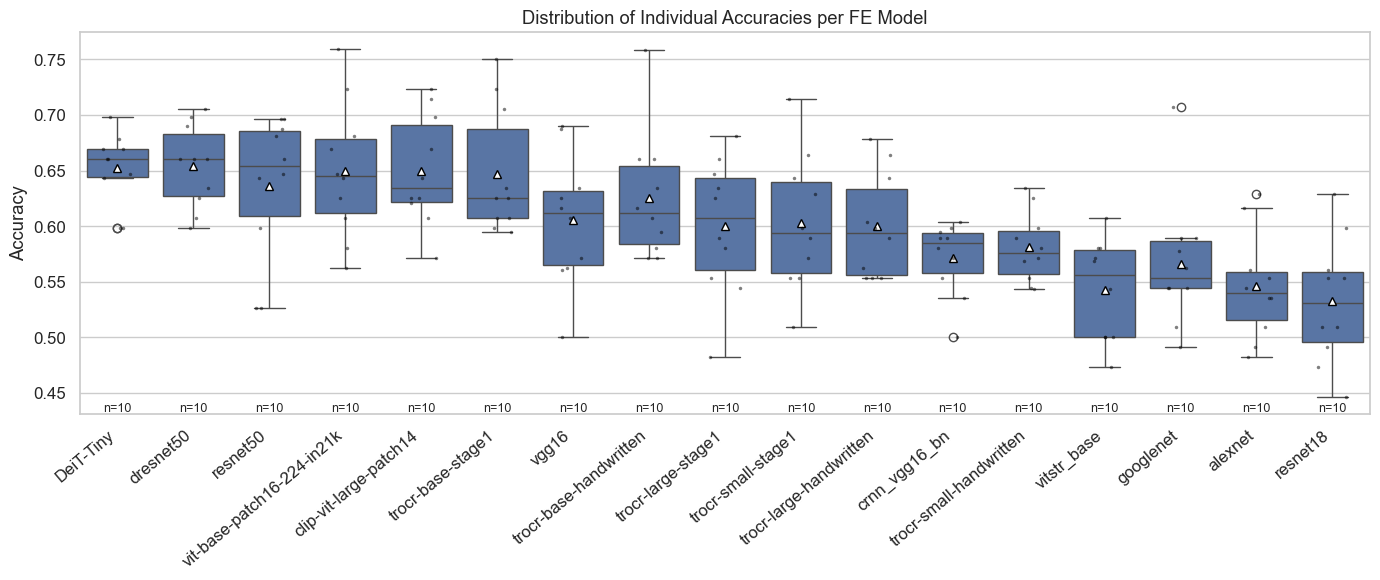

In [141]:
box_and_whiskers(df, type='body', accuracy_col='individual_accuracies',save_title='fe_model_accuracy_boxplot_body')

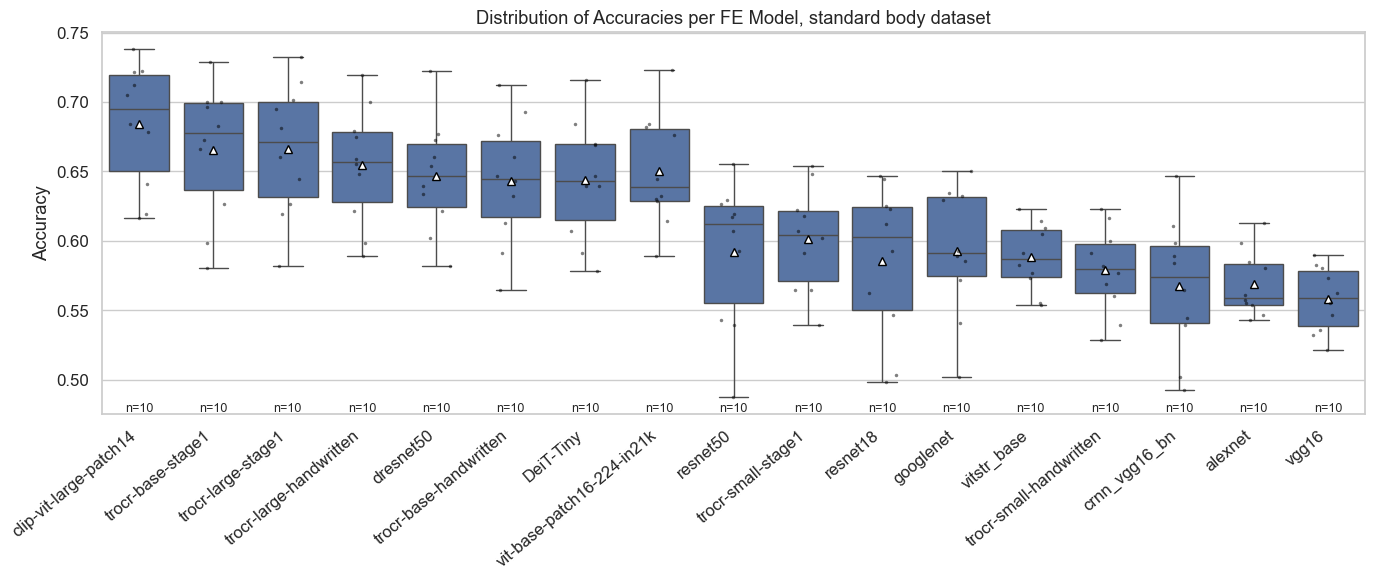

In [143]:
box_and_whiskers(df, type='squares', accuracy_col='individual_accuracies',title='Distribution of Accuracies per FE Model, standard body dataset')

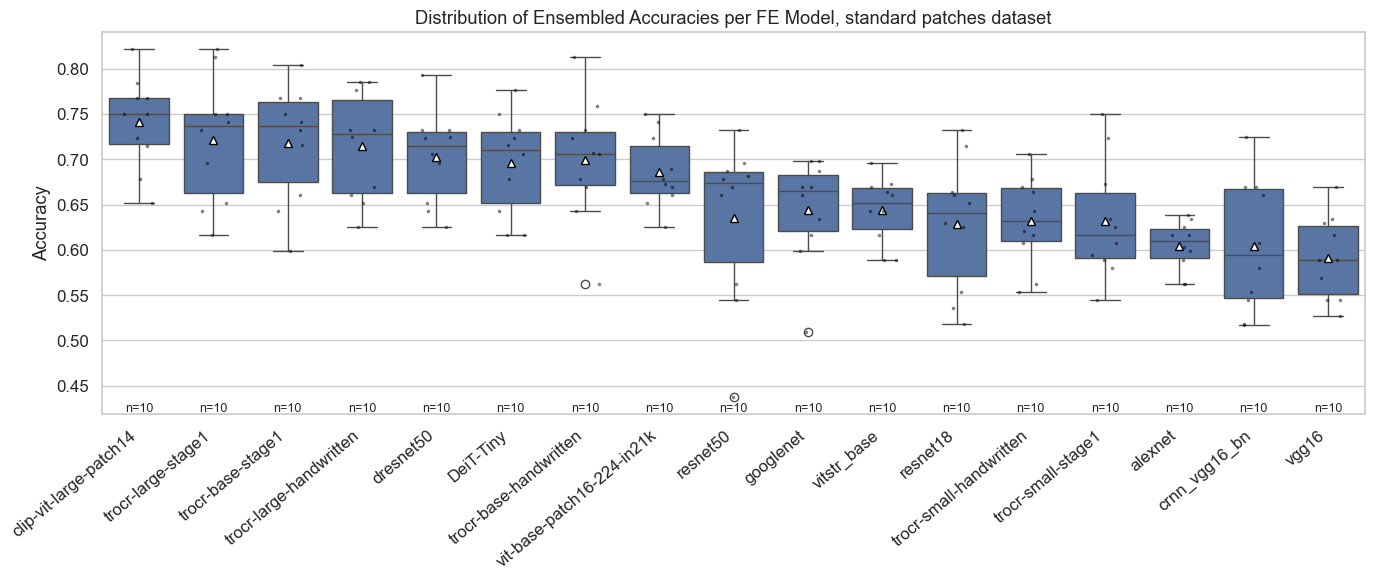

In [142]:
box_and_whiskers(df, type='squares', accuracy_col='ensembled_weighted_accuracies',title='Distribution of Ensembled Accuracies per FE Model, standard patches dataset',save_title='fe_model_accuracy_boxplot_ensembled_weighted')

# experiment 14

In [144]:
experiment=feature_files[13]
df = file_IO.assemble_csv_from_log(experiment)
df = extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
features_of_interest = ['FE model','type','train_on_language']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
#df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp = get_crossval_results(df)
print(df_exp.columns)
#selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all','english,all','arabic,all'])
selected_accuracies = ['arabic,all_individual_accuracies','english,all_individual_accuracies',
                       'arabic,all_ensembled_weighted_accuracies','english,all_ensembled_weighted_accuracies']
#print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

Index(['FE model', 'type', 'train_on_language', 'cross_val_accuracies',
       'cross_val_subgroup_accuracies', 'individual_accuracies',
       'ensembled_weighted_accuracies', 'arabic,all_individual_accuracies',
       'arabic,all_ensembled_weighted_accuracies',
       'english,all_individual_accuracies',
       'english,all_ensembled_weighted_accuracies'],
      dtype='object')


## Merging arab->eng, eng->arab

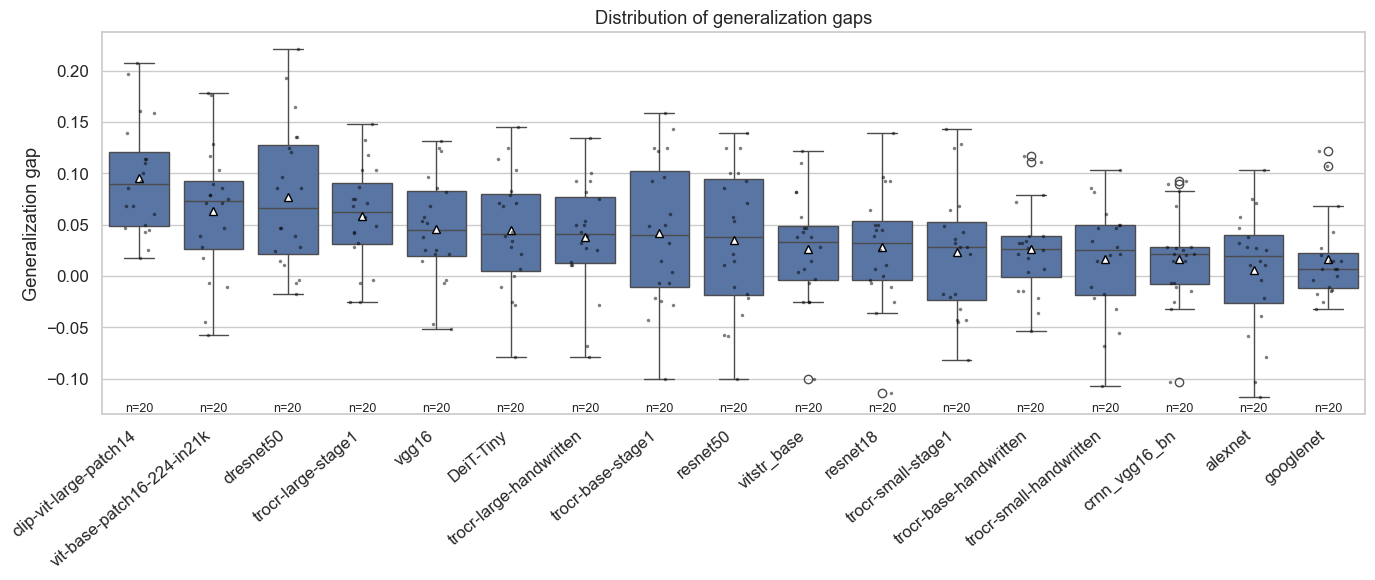

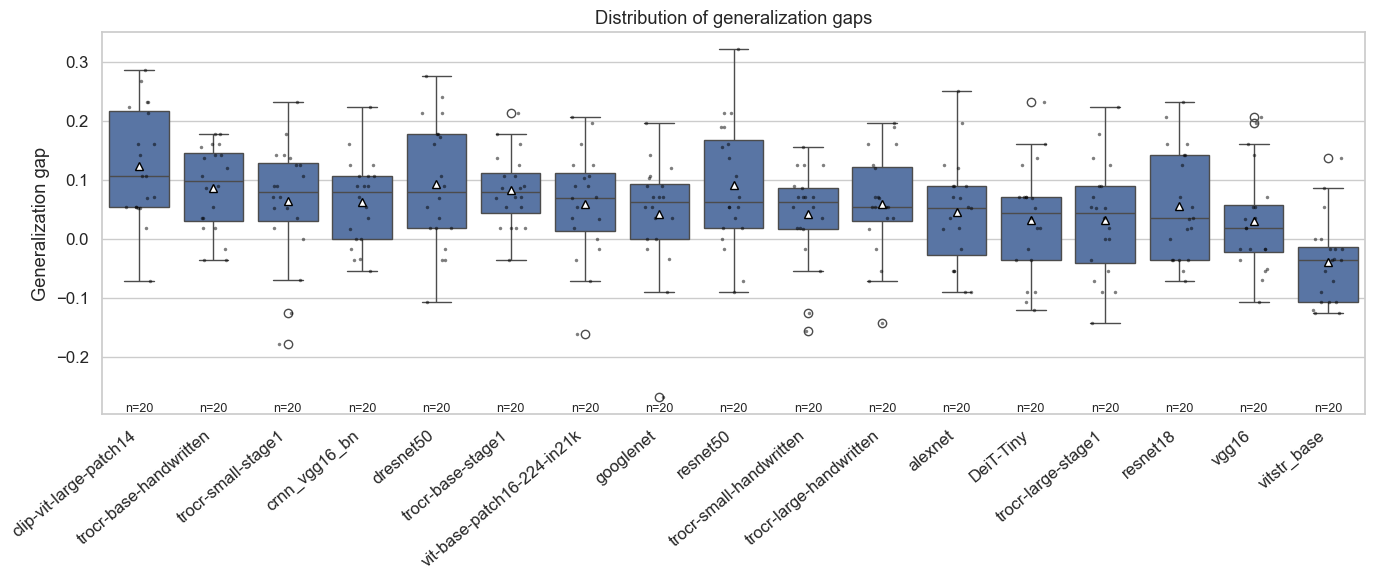

In [130]:
df_individual = df.copy()
df_individual['script_generalization'] = df.apply(script_generalization_box_and_whiskers, axis=1, args=('individual',))
df_individual=join_acc_lists(df_individual,merge_cols=['FE model','type'],columns=['script_generalization'])
box_and_whiskers(df_individual, type='squares', accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap')
box_and_whiskers(df_individual, type='body', accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap')

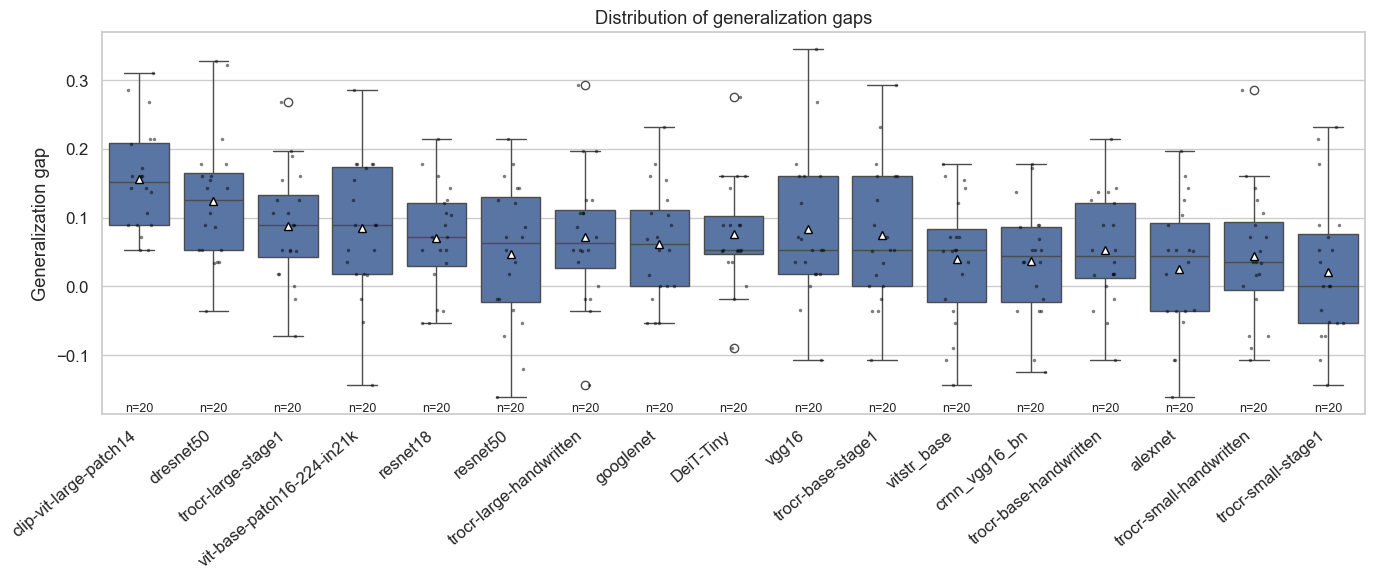

In [131]:
df_ensemble = df.copy()
df_ensemble['script_generalization'] = df.apply(script_generalization_box_and_whiskers, axis=1, args=('ensembled_weighted',))
df_ensemble=join_acc_lists(df_ensemble,merge_cols=['FE model','type'],columns=['script_generalization'])
box_and_whiskers(df_ensemble, type='squares', accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap')

## Comparing english->arab, arab->english

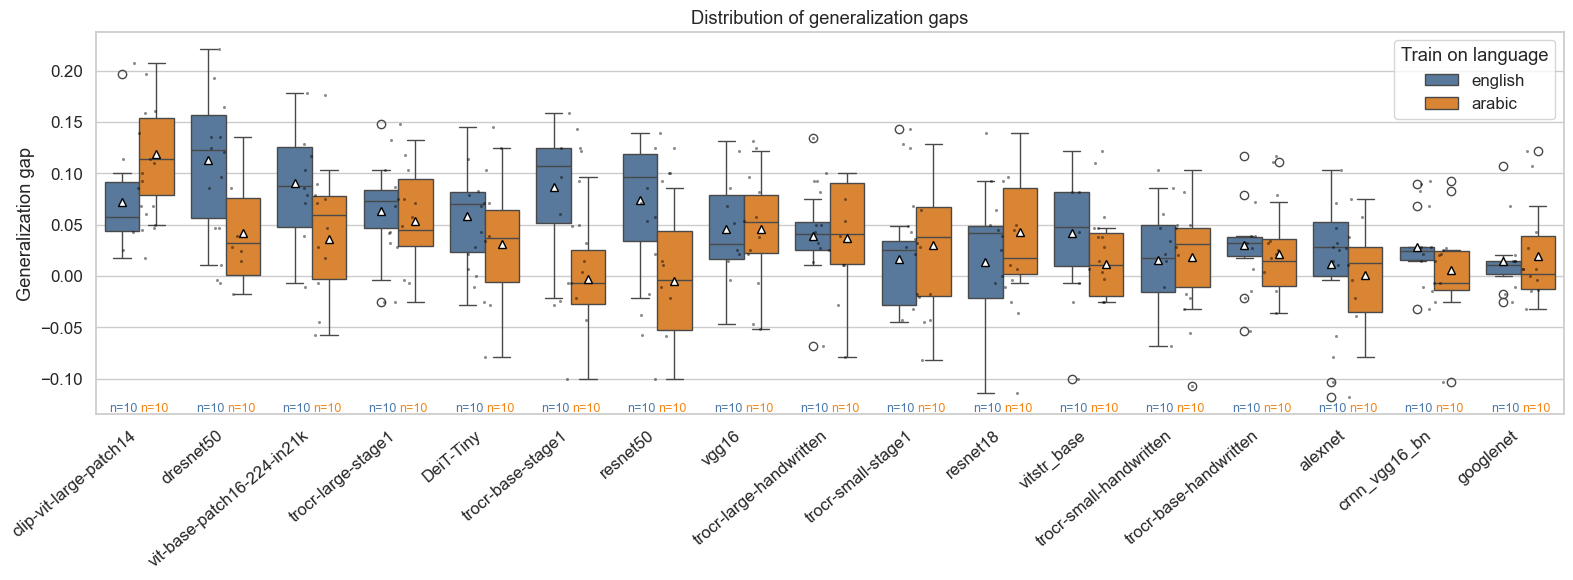

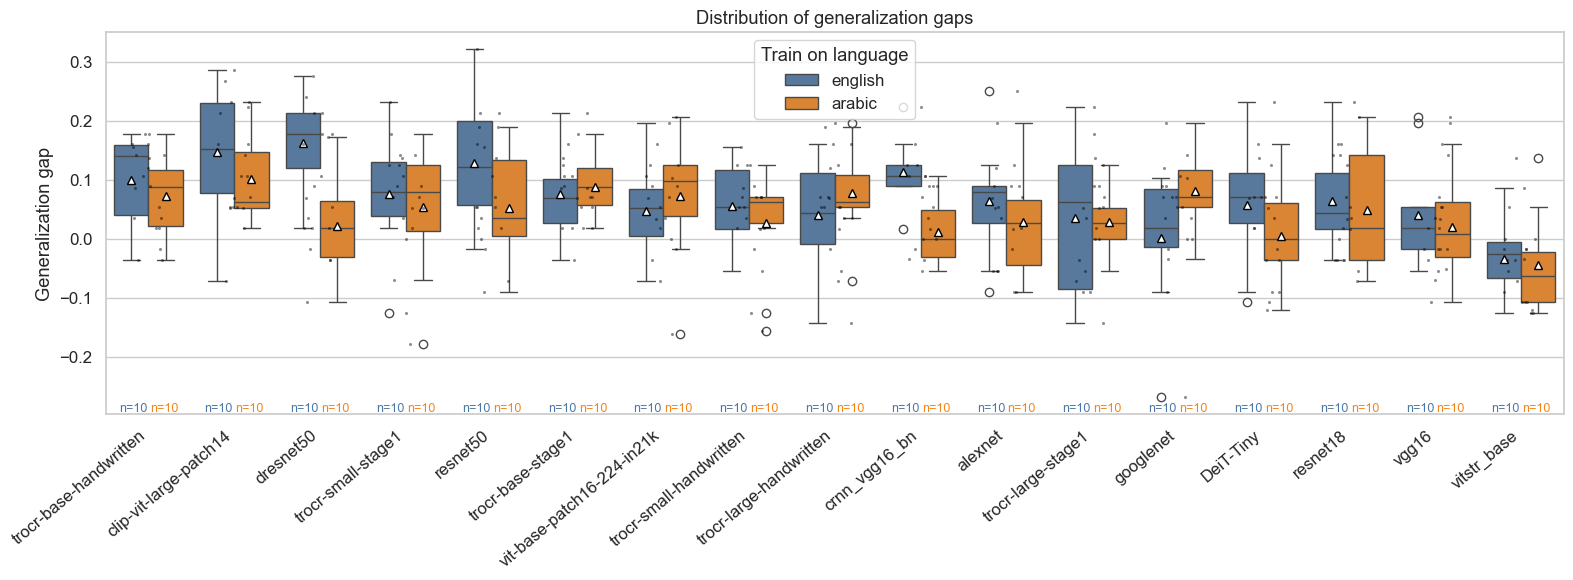

In [145]:
df_individual = df.copy()
df_individual['script_generalization'] = df.apply(script_generalization_box_and_whiskers, axis=1, args=('individual',))
box_and_whiskers_by_language(df_individual, type='squares', 
                             accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap',save_title='fe_model_accuracy_boxplot_lang_squares_individual')
box_and_whiskers_by_language(df_individual, type='body', 
                             accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap',save_title='fe_model_accuracy_boxplot_lang_body_individual')

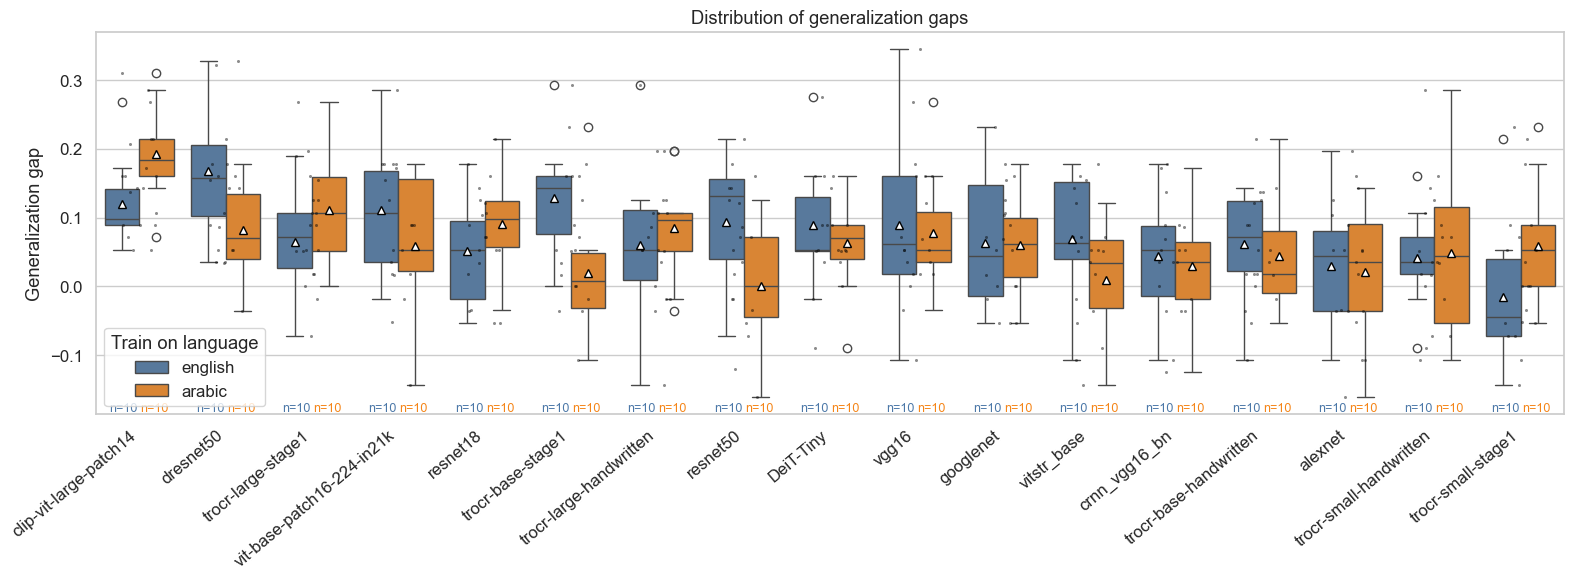

In [146]:
df_ensemble = df.copy()
df_ensemble['script_generalization'] = df.apply(script_generalization_box_and_whiskers, axis=1, args=('ensembled_weighted',))
box_and_whiskers_by_language(df_ensemble, type='squares', 
                             accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap',save_title='fe_model_accuracy_boxplot_lang_squares_ensembled_weighted')
#box_and_whiskers(df_ensemble[df_ensemble['train_on_language'] == 'arabic'], type='squares', accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap')
#box_and_whiskers(df_ensemble[df_ensemble['train_on_language'] == 'english'], type='squares', accuracy_col='script_generalization',title='Distribution of generalization gaps',y_title='Generalization gap')

# templates

## initialization

In [3]:
from IPython.display import display


In [4]:
output_dir = source_path + "\\outputs\\logs\\"
LOG_FILE = output_dir+"feature_extraction_metadata_log.json"
df = file_IO.assemble_csv_from_log(LOG_FILE)

In [6]:
# Map 'm patches' and 'type' from df_2 to df_exp based on 'original raw file' and 'experiment'
df['m patches'] = df['original raw file'].map(df_2.set_index('experiment')['m patches'])
df['type of preprocessing'] = df['original raw file'].map(df_2.set_index('experiment')['type'])
df['type of preprocessing'] = df.apply(
    lambda row: f"{row['type of preprocessing']} ({int(row['m patches'])})" if pd.notnull(row['m patches']) else row['type of preprocessing'],
    axis=1
)
df['gw'] = df['original raw file'].map(df_2.set_index('experiment')['gw'])

In [7]:
# Step 1: Extract timestamp part (last 15 characters)
df['timestamp_str'] = df['experiment'].str.extract(r'(\d{8}_\d{6})$')

# Step 2: Convert to datetime
df['time'] = pd.to_datetime(df['timestamp_str'], format='%Y%m%d_%H%M%S')

# Step 3: Sort by time
df = df.sort_values('time')

from datetime import datetime
# Step 4: Filter by date
cutoff_date = datetime(2025, 6, 10, 16,10)
cutoff_date_2 = datetime(2026, 6, 9, 17,0)
df = df[df['time'] > cutoff_date]
df = df[df['time'] < cutoff_date_2]

In [8]:
L=len(df)
metric_type='individual'
group_type=None#'english,all'
df_exp=file_IO.expand_accuracies(df,type=metric_type,group=group_type)
if group_type is None:
    accuracy_metric= metric_type
else:
    accuracy_metric = group_type+'_'+metric_type
all_columns=df_exp.columns
acc_cols=[f'{accuracy_metric}_IF_accuracy_Mean', f'{accuracy_metric}_OOF_accuracy_Mean', f'{accuracy_metric}_Generalization Gap']
exp_properties = ['type of preprocessing','FE model','classifier model','with PCA','model_params']
n_show=10

In [9]:
df_exp

,experiment,type of preprocessing,original raw file,input file,FE model,FE transform,classifier model,model_params,n_splits,train_on_language,...,individual_IF_accuracy_Max,individual_IF_accuracy_Median,individual_IF_accuracy_Confidence Interval,individual_OOF_accuracy_Mean,individual_OOF_accuracy_Variance,individual_OOF_accuracy_Min,individual_OOF_accuracy_Max,individual_OOF_accuracy_Median,individual_OOF_accuracy_Confidence Interval,individual_Generalization Gap
0,1_20250610_161807,standard patches (5),icdar_train_df_patches_20250515_164130.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.832743,0.823451,"(0.8144510114902703, 0.8341035607811162)",0.677600,0.001645,0.633929,0.728947,0.692982,"(0.6272462651967516, 0.7279542360563811)",0.146677
1,2_20250610_161819,nan (5),icdar_train_df_patches_20250606_155640.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.822331,0.810498,"(0.8052267587248131, 0.8211496601933362)",0.673069,0.000910,0.630357,0.706250,0.685413,"(0.6356044291643046, 0.7105326039305739)",0.140120
2,3_20250610_161831,nan (5),icdar_train_df_patches_20250606_163257.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.828097,0.811947,"(0.8047872398358078, 0.8261433403018521)",0.680128,0.001349,0.619643,0.715789,0.691071,"(0.634523122134277, 0.7257337700962997)",0.135337
3,4_20250610_161843,nan (5),icdar_train_df_patches_20250609_172141.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.771903,0.763556,"(0.7551889944400114, 0.7719213300437644)",0.622613,0.000562,0.580357,0.635965,0.632456,"(0.5931724314410848, 0.6520531324686899)",0.140942
4,5_20250610_161855,nan (5),icdar_train_df_patches_20250609_175326.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.776549,0.755973,"(0.7498447733812682, 0.7730228765695676)",0.611241,0.001166,0.556250,0.641228,0.611404,"(0.5688334969886537, 0.653647706018865)",0.150193
5,6_20250610_161907,nan (5),icdar_train_df_patches_20250609_182637.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.750885,0.749779,"(0.7474151465502484, 0.7515162202147468)",0.601808,0.000577,0.569643,0.628571,0.608772,"(0.5719776218793923, 0.631637666341159)",0.147658
6,7_20250610_161919,nan (5),icdar_train_df_patches_20250609_185559.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.755752,0.743778,"(0.7382760022424243, 0.7553243910712434)",0.586805,0.000304,0.560714,0.607895,0.586842,"(0.5651559237932058, 0.6084530987631851)",0.159996
7,8_20250610_161931,nan (5),icdar_train_df_patches_20250609_224937.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.751770,0.738000,"(0.7287706987253917, 0.7485335293965356)",0.583224,0.001027,0.541964,0.618750,0.586842,"(0.5434305448375564, 0.6230168235834962)",0.155428
8,9_20250610_161943,nan (5),icdar_train_df_patches_20250609_233651.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.751549,0.742889,"(0.7327670922772423, 0.7519062607217742)",0.585529,0.000453,0.562500,0.613393,0.583333,"(0.5590901530861939, 0.611968744156914)",0.156807
9,10_20250610_161955,nan (5),icdar_train_df_patches_20250610_120640.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,Na

## tests

### latest source files

In [ ]:
cutoff_date = datetime(2025, 6, 3)
#cutoff_date = datetime.strptime('20250606_150034', '%Y%m%d_%H%M%S')
#print(dt)
filtered= df_2[df_2['created'] >= cutoff_date]
try_files = filtered[~filtered['experiment'].str.contains('icdar_EXTRACTED_train_df_')]
print(try_files['experiment'].tolist())

['icdar_train_df_patches_20250606_155640.csv', 'icdar_train_df_patches_20250606_160858.csv', 'icdar_train_df_patches_20250606_162731.csv', 'icdar_train_df_patches_20250606_163257.csv', 'icdar_train_df_patches_20250609_155433.csv', 'icdar_train_df_patches_20250609_165240.csv', 'icdar_train_df_patches_20250609_172141.csv', 'icdar_train_df_patches_20250609_175326.csv', 'icdar_train_df_patches_20250609_182637.csv', 'icdar_train_df_patches_20250609_185559.csv', 'icdar_train_df_patches_20250609_224937.csv', 'icdar_train_df_patches_20250609_233651.csv', 'icdar_train_df_patches_20250610_120640.csv']


In [24]:
for idx, row in try_files.iterrows():
    print(f"File: {row['experiment']}")
    print(row['source_file'])
    print(row['gw'])
    # Check if row['source_file'] is in the 'input file' column of df_exp
    if row['experiment'] in df_exp['original raw file'].values:
        print(f"Found in df_exp: {row['experiment']}")
    else:
        print(f"Not found in df_exp: {row['experiment']}")
    print('-' * 80)

File: icdar_train_df_patches_20250606_155640.csv
icdar_train_df_20250514_175905.csv
3.0
Not found in df_exp: icdar_train_df_patches_20250606_155640.csv
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250606_160858.csv
icdar_train_df_20250514_175905.csv
4.0
Not found in df_exp: icdar_train_df_patches_20250606_160858.csv
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250606_162731.csv
icdar_train_df_20250514_175905.csv
6.0
Not found in df_exp: icdar_train_df_patches_20250606_162731.csv
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250606_163257.csv
icdar_train_df_20250514_175905.csv
7.0
Not found in df_exp: icdar_train_df_patches_20250606_163257.csv
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250609_155433.csv
icdar_train_df_2025

### latest extracted inputs

In [154]:
#cutoff_date = datetime(2025, 6, 9,13)
cutoff_date = datetime.strptime('20250604_130034', '%Y%m%d_%H%M%S')
#print(dt)
filtered= df_2[df_2['created'] >= cutoff_date]
try_files = filtered[filtered['experiment'].str.contains('icdar_EXTRACTED_train_df_')]
print(try_files['experiment'].tolist())

['icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250604_184639.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250604_201425.csv', 'icdar_EXTRACTED_train_df_trocr-large-handwritten_20250605_111822.csv', 'icdar_EXTRACTED_train_df_trocr-large-stage1_20250605_132612.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250605_133231.csv', 'icdar_EXTRACTED_train_df_trocr-base-stage1_20250606_150034.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_175355.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_182038.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_184935.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_220009.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_115509.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_122808.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_124922.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_140930.csv', 'icdar_EXTRAC

In [155]:
for idx, row in try_files.iterrows():
    print(f"File: {row['experiment']}")
    print(row['source_file'])
    # Check if row['source_file'] is in the 'input file' column of df_exp
    if row['experiment'] in df_exp['input file'].values:
        print(f"Found in df_exp: {row['experiment']}")
    else:
        print(f"Not found in df_exp: {row['experiment']}")
    print('-' * 80)

File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250604_184639.csv
icdar_train_df_words_sentences_20250522_230307.csv
Not found in df_exp: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250604_184639.csv
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250604_201425.csv
icdar_train_df_patches_20250522_235724.csv
Found in df_exp: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250604_201425.csv
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_trocr-large-handwritten_20250605_111822.csv
icdar_train_df_words_sentences_20250522_230307.csv
Not found in df_exp: icdar_EXTRACTED_train_df_trocr-large-handwritten_20250605_111822.csv
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_trocr-large-stage1_20250605_132612.csv
icdar_train_df_words_sentences_20250522_230307.csv
Not 

In [156]:
unique_combinations = filtered[['m patches', 'type','gw']].drop_duplicates()
display(unique_combinations)

,m patches,type,gw
41,NaN,NaN,NaN
47,5.0,NaN,3.0
48,5.0,NaN,4.0
49,5.0,NaN,6.0
50,5.0,NaN,7.0
51,5.0,NaN,8.0
52,5.0,NaN,9.0
53,5.0,NaN,15.0
54,5.0,NaN,20.0
57,5.0,NaN,25.0


### specific file

### unique files with m patches and type (in df_exp)

In [10]:
unique_combinations = df_2[['m patches', 'type']].drop_duplicates()
display(unique_combinations)

,m patches,type
0,NaN,NaN
1,NaN,original images
2,NaN,feature extraction
3,5.0,NaN
4,5.0,standard patches
18,5.0,small_patches
19,9.0,words-sentences
20,5.0,longer-than-higher
21,15.0,standard patches
25,1.0,body


In [11]:
unique_combinations = df_exp[['original raw file', 'type of preprocessing','m patches']].drop_duplicates()
#unique_combinations = df_exp[['original raw file', 'type of preprocessing']].drop_duplicates()

display(unique_combinations)

,original raw file,type of preprocessing,m patches
0,icdar_train_df_patches_20250515_164130.csv,standard patches (5),5.0
1,icdar_train_df_patches_20250606_155640.csv,nan (5),5.0
2,icdar_train_df_patches_20250606_163257.csv,nan (5),5.0
3,icdar_train_df_patches_20250609_172141.csv,nan (5),5.0
4,icdar_train_df_patches_20250609_175326.csv,nan (5),5.0
5,icdar_train_df_patches_20250609_182637.csv,nan (5),5.0
6,icdar_train_df_patches_20250609_185559.csv,nan (5),5.0
7,icdar_train_df_patches_20250609_224937.csv,nan (5),5.0
8,icdar_train_df_patches_20250609_233651.csv,nan (5),5.0
9,icdar_train_df_patches_20250610_120640.csv,nan (5),5.0


In [15]:
#show the different types of preprocessed file
filtered = df_2[df_2['script_type'] == 'data_preprocessing']
grouped = filtered.sort_values('created', ascending=False).groupby('type')
for group_name, group_df in grouped:
    print(f"Type: {group_name}")
    for idx, row in group_df.iterrows():
        print_model_properties_txt(idx, group_df, cols=['experiment', 'm patches','gw', 'description'])
    #print(group_df[['experiment', 'm patches','description']])
    print('-' * 40)

Type: body
Model: icdar_train_df_body_20250523_181312.csv
experiment: icdar_train_df_body_20250523_181312.csv
m patches: 1.0
gw: nan
description: 
        I crop each image so that there is no white around the text -> i am zooming on the text
----------------------------------------
----------------------------------------
Type: feature extraction
Model: icdar_train_df_KAGGLE_20250514_181737.csv
experiment: icdar_train_df_KAGGLE_20250514_181737.csv
m patches: nan
gw: nan
description: dataframe with the following columns: writer, language, same_text, isEng, train, index and kaggle features; 
        This can be used to train FE models
----------------------------------------
----------------------------------------
Type: longer-than-higher
Model: icdar_train_df_patches_20250522_234152.csv
experiment: icdar_train_df_patches_20250522_234152.csv
m patches: 5.0
gw: 3.0
description: 
        I am creating patches that are longer than they are wide.
        prop gives the ratio of the width t

### ho un esperimento nel dataset?


### to which preprocessed dataset was model applied?

In [271]:
to_show=get_type_of_exp_per_model(df_exp)
for idx, row in to_show.iterrows():
    print(f"Model: {row['Model']}")
    print(f"Type of Preprocessing: {row['Type of Preprocessing']}")
    print('-' * 40)

Model: clip-vit-large-patch14
Type of Preprocessing: standard patches (5), words-sentences (9), standard patches (15), body (1)
----------------------------------------
Model: crnn_vgg16_bn
Type of Preprocessing: standard patches (5), words-sentences (9), longer-than-higher (5)
----------------------------------------
Model: dresnet50
Type of Preprocessing: standard patches (5)
----------------------------------------
Model: resnet50
Type of Preprocessing: standard patches (5), small_patches (5), standard patches (15), body (1)
----------------------------------------
Model: trocr-base-handwritten
Type of Preprocessing: standard patches (5), small_patches (5), words-sentences (9), standard patches (15), body (1), longer-than-higher (5)
----------------------------------------
Model: trocr-large-handwritten
Type of Preprocessing: standard patches (5), words-sentences (9)
----------------------------------------
Model: trocr-large-stage1
Type of Preprocessing: words-sentences (9)
-------

### which models applied on this dataset?

In [272]:
to_show=get_model_per_type(df_exp)
for idx, row in to_show.iterrows():
    #print(row)
    print(f"Type: {row['type of preprocessing']}")
    print(f"FE Models: {row['FE Models']}")
    print('-' * 40)

Type: body (1)
FE Models: vit-base-patch16-224-in21k, trocr-base-handwritten, resnet50, clip-vit-large-patch14
----------------------------------------
Type: longer-than-higher (5)
FE Models: trocr-small-stage1, trocr-base-handwritten, crnn_vgg16_bn
----------------------------------------
Type: small_patches (5)
FE Models: vit-base-patch16-224-in21k, trocr-base-handwritten, resnet50
----------------------------------------
Type: standard patches (15)
FE Models: vit-base-patch16-224-in21k, trocr-base-handwritten, resnet50, clip-vit-large-patch14
----------------------------------------
Type: standard patches (5)
FE Models: trocr-small-stage1, trocr-small-handwritten, resnet50, vit-base-patch16-224-in21k, trocr-base-handwritten, clip-vit-large-patch14, trocr-large-handwritten, dresnet50, crnn_vgg16_bn, vitstr_base
----------------------------------------
Type: words-sentences (9)
FE Models: trocr-small-stage1, trocr-base-handwritten, vit-base-patch16-224-in21k, crnn_vgg16_bn, vitstr_bas

### filename of model application to specific source file

In [39]:
s_data='icdar_train_df_patches_20250515_164130.csv'
file_IO.show_model_instances(LOG_FILE_2,['model',"transform_mode","custom transform","description"], s_data )

Metadata for icdar_EXTRACTED_train_df_trocr-small-stage1_20250516_122528.csv:
model: trocr-small-stage1
description: I am performing inference with trocr-small-stage1 on the patches dataset and saving the output features as columns of the dataframe
        the columns are named f1, f2, .., f384
------------------------------------------
Metadata for icdar_EXTRACTED_train_df_trocr-small-handwritten_20250516_150814.csv:
model: trocr-small-handwritten
description: I am performing inference with trocr-small-handwritten on the patches dataset and saving the output features as columns of the dataframe
        the columns are named f1, f2, .., f384
------------------------------------------
Metadata for icdar_EXTRACTED_train_df_resnet50_20250516_161022.csv:
model: resnet50
custom transform: False
description: I am performing inference with resnet50 on the patches dataset and saving the output features as columns of the dataframe
        the columns are named f1, f2, .., f2048. I apply the sta

In [41]:
# I select the transform and load the input file corresponding to that model and transform (the most recent one)
model_used = 'resnet50'
transform_used = ''
file_IO.get_file_name(LOG_FILE_2,{'model':model_used},s_data)

icdar_EXTRACTED_train_df_resnet50_20250516_161022.csv
icdar_EXTRACTED_train_df_resnet50_20250516_163737.csv


### get model on source

In [ ]:
source_file= 'icdar_train_df_body_20250523_181312.csv'
unique_models, source_files = get_models_on_source(df_2,source_file)
for model_name in unique_models:
    print(f"Model: {model_name}")
    experiments = get_experiments_on_model(model_name, source_files)
    print(f"Experiments: {experiments}")
    print('-' * 40)

### find files of interest from df2 (sources) and then extracted features of interests (again from df2)

In [217]:
cutoff_date = datetime.strptime('20250606_155640', '%Y%m%d_%H%M%S')
#print(dt)
filtered= df_2[df_2['created'] >= cutoff_date]
#try_files = filtered[~filtered['experiment'].str.contains('icdar_EXTRACTED_train_df_')]
#try_files = filtered[filtered['description'].str.contains('I am experimenting with decreasing progressively the patch size keeping 5 patches per writer.')]
try_files = filtered[filtered['m patches'] == 5]
for idx, row in try_files.iterrows():
    print(f"File: {row['experiment']}")
    print(row['m patches'],row['gw'])
    print('-' * 80)

File: icdar_train_df_patches_20250606_155640.csv
5.0 3.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250606_160858.csv
5.0 4.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250606_162731.csv
5.0 6.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250606_163257.csv
5.0 7.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250609_155433.csv
5.0 8.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250609_165240.csv
5.0 9.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_20250609_172141.csv
5.0 15.0
--------------------------------------------------------------------------------
File: icdar_train_df_patches_2025

In [218]:
try_file_names = try_files['experiment'].tolist() + ['icdar_train_df_patches_20250521_120324.csv', 'icdar_train_df_patches_20250515_164130.csv']
print(try_file_names)


['icdar_train_df_patches_20250606_155640.csv', 'icdar_train_df_patches_20250606_160858.csv', 'icdar_train_df_patches_20250606_162731.csv', 'icdar_train_df_patches_20250606_163257.csv', 'icdar_train_df_patches_20250609_155433.csv', 'icdar_train_df_patches_20250609_165240.csv', 'icdar_train_df_patches_20250609_172141.csv', 'icdar_train_df_patches_20250609_175326.csv', 'icdar_train_df_patches_20250609_182637.csv', 'icdar_train_df_patches_20250609_185559.csv', 'icdar_train_df_patches_20250609_224937.csv', 'icdar_train_df_patches_20250609_233651.csv', 'icdar_train_df_patches_20250610_120640.csv', 'icdar_train_df_patches_20250521_120324.csv', 'icdar_train_df_patches_20250515_164130.csv']


In [219]:
FE_model = 'clip-vit-large-patch14'
files_df = df_2[df_2['model'] == FE_model]
files_df = files_df[files_df['source_file'].isin(try_file_names)]
for idx, row in files_df.iterrows():
    print(f"File: {row['experiment']}")
    print(f"source file: {row['source_file']}")
    orig_file = row['source_file']
    match = df_2[df_2['experiment'] == orig_file]
    if not match.empty:
        m_patches = match.iloc[0]['m patches']
        gw = match.iloc[0]['gw']
        print(f"m patches: {m_patches}, gw: {gw}")
    else:
        print("No matching original raw file found in try_files.")
    print('-' * 80)

File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv
source file: icdar_train_df_patches_20250515_164130.csv
m patches: 5.0, gw: 5.0
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_175355.csv
source file: icdar_train_df_patches_20250606_155640.csv
m patches: 5.0, gw: 3.0
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_182038.csv
source file: icdar_train_df_patches_20250606_163257.csv
m patches: 5.0, gw: 7.0
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_184935.csv
source file: icdar_train_df_patches_20250609_172141.csv
m patches: 5.0, gw: 15.0
--------------------------------------------------------------------------------
File: icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250

In [220]:
selected_names = files_df['experiment'].tolist()
print(selected_names)

['icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250517_144404.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_175355.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_182038.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_184935.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250609_220009.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_115509.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_122808.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_124922.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_140930.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_143919.csv', 'icdar_EXTRACTED_train_df_clip-vit-large-patch14_20250610_161236.csv']


### columns

In [19]:
list(all_columns)

['experiment',
 'type of preprocessing',
 'original raw file',
 'input file',
 'FE model',
 'FE transform',
 'classifier model',
 'model_params',
 'n_splits',
 'train_on_language',
 'train_on_same',
 'task',
 'with cross validation',
 'with PCA',
 'training time for cross-validation',
 'training time for final model',
 'cross_val_accuracies',
 'subgroup_accuracies',
 'is_kaggle',
 'description',
 'test',
 'n_components',
 'cross_val_subgroup_accuracies',
 'm patches',
 'timestamp_str',
 'time',
 'ensembled_IF_accuracy_Mean',
 'ensembled_IF_accuracy_Variance',
 'ensembled_IF_accuracy_Min',
 'ensembled_IF_accuracy_Max',
 'ensembled_IF_accuracy_Median',
 'ensembled_IF_accuracy_Confidence Interval',
 'ensembled_OOF_accuracy_Mean',
 'ensembled_OOF_accuracy_Variance',
 'ensembled_OOF_accuracy_Min',
 'ensembled_OOF_accuracy_Max',
 'ensembled_OOF_accuracy_Median',
 'ensembled_OOF_accuracy_Confidence Interval',
 'ensembled_Generalization Gap']

In [220]:
list(all_columns_2)

['experiment',
 'full_path',
 'size_bytes',
 'created',
 'modified',
 'accessed',
 'seed',
 'description',
 'script_type',
 'type',
 'm patches',
 'source_file',
 'gw',
 'n_cc',
 'model',
 'pooling',
 'custom transform',
 'save_h5',
 'truncation',
 'transform_mode',
 'sort_by',
 'n_selected_lines',
 'n_slices',
 'spacing',
 'r_mask',
 'r_min',
 'prop',
 'fraction of the max used to identify boundaries']

In [21]:
df_2

,experiment,full_path,size_bytes,created,modified,accessed,seed,description,script_type,type,...,truncation,transform_mode,sort_by,n_selected_lines,n_slices,spacing,r_mask,r_min,prop,fraction of the max used to identify boundaries
0,icdar_train_df_20250514_165047.csv,D:\burtm\Visual_studio_code\PD_related_project...,147733,2025-05-14 16:50:47.697068,2025-05-14T16:50:47.756757,2025-05-14T16:50:47.756757,42.0,"dataframe with the following columns: writer, ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,icdar_train_df_20250514_175905.csv,c:\Users\andre\VsCode\PD related projects\gend...,147733,2025-05-23 14:48:26.377873,2025-05-14T17:59:05.604248,2025-05-23T18:03:21.312672,42.0,"dataframe with the following columns: writer, ...",data_preprocessing,original images,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,icdar_train_df_KAGGLE_20250514_181737.csv,c:\Users\andre\VsCode\PD related projects\gend...,53948612,2025-05-23 14:48:26.898500,2025-05-14T18:17:45.372099,2025-05-23T14:48:35.793833,42.0,"dataframe with the following columns: writer, ...",data_preprocessing,feature extraction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,icdar_train_df_patches_20250514_221029.csv,D:\burtm\Visual_studio_code\PD_related_project...,147733,2025-05-14 22:10:30.078981,2025-05-14T22:10:30.203676,2025-05-14T22:10:30.203676,NaN,"For each unique index = (isEng,same_text) pair...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,icdar_train_df_patches_20250515_164130.csv,c:\Users\andre\VsCode\PD related projects\gend...,862411,2025-05-23 14:48:35.939312,2025-05-15T16:41:30.504546,2025-05-24T00:04:42.352683,NaN,"For each unique index = (isEng,same_text) pair...",data_preprocessing,standard patches,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,D:\burtm\Visual_studio_code\PD_related_project...,43379066,2025-05-16 12:25:28.589676,2025-05-16T12:25:33.533804,2025-05-16T12:25:33.533804,NaN,I am performing inference with trocr-small-sta...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,icdar_EXTRACTED_train_df_trocr-small-handwritt...,D:\burtm\Visual_studio_code\PD_related_project...,43373595,2025-05-16 15:08:14.680020,2025-05-16T15:08:18.854499,2025-05-16T15:08:18.854499,NaN,I am performing inference with trocr-small-han...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,icdar_EXTRACTED_train_df_resnet50_20250516_161...,D:\burtm\Visual_studio_code\PD_related_project...,216707350,2025-05-16 16:10:22.775409,2025-05-16T16:10:53.312326,2025-05-16T16:10:53.312326,NaN,I am performing inference with resnet50 on the...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,icdar_EXTRACTED_train_df_resnet50_20250516_163...,D:\burtm\Visual_studio_code\PD_related_project...,220215329,2025-05-16 16:37:38.026354,2025-05-16T16:38:11.704283,2025-05-16T16:38:11.704283,NaN,I am performing inference with resnet50 on the...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,icdar_EXTRACTED_train_df_vit-base-patch16-224-...,D:\burtm\Visual_studio_code\PD_related_project...,89875090,2025-05-17 15:16:44.318702,2025-05-17T15:16:58.167914,2025-05-17T15:16:58.167914,NaN,I am performing inference with the vit model o...,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df_exp

,experiment,type of preprocessing,original raw file,input file,FE model,FE transform,classifier model,model_params,n_splits,train_on_language,...,ensembled_IF_accuracy_Max,ensembled_IF_accuracy_Median,ensembled_IF_accuracy_Confidence Interval,ensembled_OOF_accuracy_Mean,ensembled_OOF_accuracy_Variance,ensembled_OOF_accuracy_Min,ensembled_OOF_accuracy_Max,ensembled_OOF_accuracy_Median,ensembled_OOF_accuracy_Confidence Interval,ensembled_Generalization Gap
0,1_20250605_161144,standard patches (5),icdar_train_df_patches_20250515_164130.csv,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,trocr-small-stage1,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.725664,0.714602,"(0.6937698063415492, 0.7313334384962089)",0.618703,0.002116,0.558036,0.674107,0.609649,"(0.5615886889677765, 0.6758173260698174)",0.093849
1,1_20250605_161235,standard patches (5),icdar_train_df_patches_20250515_164130.csv,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,trocr-small-stage1,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.725664,0.714602,"(0.6937698063415492, 0.7313334384962089)",0.618703,0.002116,0.558036,0.674107,0.609649,"(0.5615886889677765, 0.6758173260698174)",0.093849
2,2_20250605_161244,standard patches (5),icdar_train_df_patches_20250515_164130.csv,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,trocr-small-stage1,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.797566,0.782222,"(0.761281933016546, 0.7998488437779475)",0.624734,0.002880,0.553571,0.688596,0.635965,"(0.5581033594031861, 0.6913640591431798)",0.155832
3,3_20250605_161255,standard patches (5),icdar_train_df_patches_20250515_164130.csv,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,trocr-small-stage1,NaN,mlp,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",5,all,...,0.991111,0.933333,"(0.8345594984079596, 0.9976076599007919)",0.623951,0.002492,0.553571,0.674107,0.627193,"(0.561971565028871, 0.6859294374773945)",0.292133
4,4_20250605_161306,standard patches (5),icdar_train_df_patches_20250515_164130.csv,icdar_EXTRACTED_train_df_trocr-small-stage1_20...,trocr-small-stage1,NaN,mlp,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",5,all,...,0.933628,0.853982,"(0.8099868956626026, 0.9173228388506718)",0.628352,0.002223,0.566964,0.674107,0.653509,"(0.5698033748206932, 0.6869008858309358)",0.235303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,136_20250605_164935,words-sentences (9),icdar_train_df_words_sentences_20250522_230307...,icdar_EXTRACTED_train_df_trocr-large-stage1_20...,trocr-large-stage1,NaN,mlp,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",5,all,...,1.000000,0.987832,"(0.9481641934963376, 1.0128977534063173)",0.726801,0.002959,0.642857,0.785088,0.736607,"(0.6592557715712452, 0.7943469853209854)",0.253730
137,137_20250605_164943,body (1),icdar_train_df_body_20250523_181312.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.825221,0.807778,"(0.7975664685253024, 0.8229900703144223)",0.639865,0.001111,0.589286,0.675439,0.642857,"(0.5984816480535375, 0.6812489283875651)",0.170413
138,138_20250605_164950,body (1),icdar_train_df_body_20250523_181312.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,logreg,"{'C': 1.0, 'class_weight': None, 'dual': False...",5,all,...,0.991150,0.991111,"(0.9850546256222685, 0.9927900154790099)",0.622259,0.002128,0.575893,0.687500,0.627193,"(0.564975006341471, 0.6795425375181782)",0.366664
139,139_20250605_164959,body (1),icdar_train_df_body_20250523_181312.csv,icdar_EXTRACTED_train_df_clip-vit-large-patch1...,clip-vit-large-patch14,NaN,mlp,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",5,all,...,0.901549,0.862832,"(0.696256586868906, 0.9354779264054301)",0.617105,0.001203,0.598214,0.678571,0.600877,"(0.5740445246984694, 0.66016600161732)",0.198762


## models comparison (different datasets, different classifiers, ..)

### First ten models by accuracy , distribution of accuracies

In [ ]:
#overall
display_specific(max_accuracy(df_exp, filters=None, aggregation=accuracy_metric), n=n_show, cols=acc_cols+exp_properties)

,ensembled_weighted_IF_accuracy_Mean,ensembled_weighted_OOF_accuracy_Mean,ensembled_weighted_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
134,0.922857,0.757738,0.165119,words-sentences (9),trocr-large-stage1,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
126,0.851269,0.752381,0.098888,standard patches (15),clip-vit-large-patch14,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
28,0.947538,0.741792,0.205746,standard patches (5),clip-vit-large-patch14,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
127,0.971232,0.736357,0.234876,standard patches (15),clip-vit-large-patch14,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
25,0.830217,0.735793,0.094425,standard patches (5),clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
128,0.969410,0.733772,0.235638,standard patches (15),clip-vit-large-patch14,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
26,0.893161,0.731924,0.161238,standard patches (5),clip-vit-large-patch14,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
66,0.888732,0.731109,0.157623,words-sentences (9),trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
27,0.969664,0.731093,0.238570,standard patches (5),clip-vit-large-patch14,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
125,0.805396,0.730154,0.075243,standard patches (15),clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


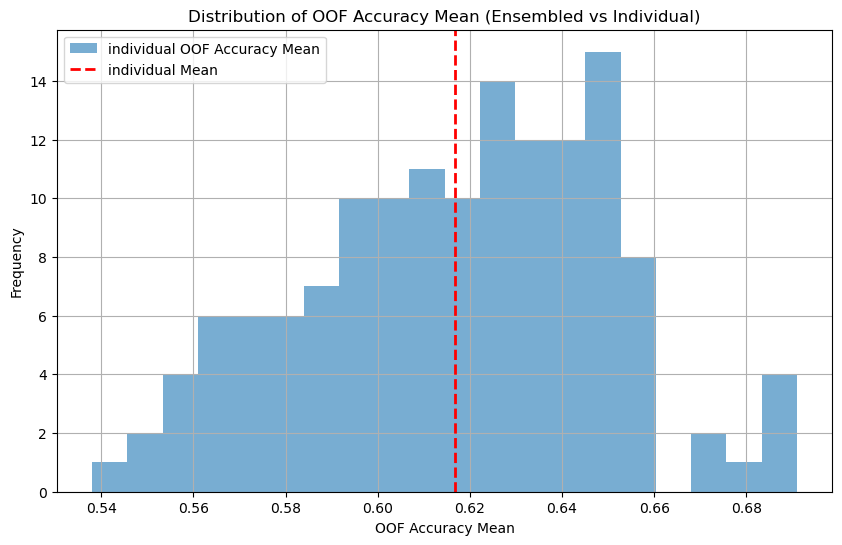

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_exp[f'{accuracy_metric}_OOF_accuracy_Mean'], bins=20, alpha=0.6, label=f'{accuracy_metric} OOF Accuracy Mean')

# Add vertical lines at the mean positions
plt.axvline(df_exp[f'{accuracy_metric}_OOF_accuracy_Mean'].mean(), color='red', linestyle='dashed', linewidth=2, label=f'{accuracy_metric} Mean')

plt.xlabel('OOF Accuracy Mean')
plt.ylabel('Frequency')
plt.title('Distribution of OOF Accuracy Mean (Ensembled vs Individual)')
plt.legend()
plt.grid(True)
plt.show()

### For each model I show the best model and sort by accuracy

In [183]:
# model specific
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(df_exp, filters=None, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values
                 (by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False), 
              n=n_show, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,individual_Generalization Gap,type of preprocessing,classifier model,with PCA,model_params
0,clip-vit-large-patch14,0.690918,0.934258,0.243340,standard patches (5),mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
6,trocr-large-stage1,0.673371,0.803377,0.130006,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,trocr-base-handwritten,0.656205,0.777415,0.121210,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
9,vit-base-patch16-224-in21k,0.655247,0.748980,0.093733,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,trocr-large-handwritten,0.649684,0.831197,0.181513,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,dresnet50,0.645201,0.925211,0.280010,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,resnet50,0.633954,0.721403,0.087449,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,crnn_vgg16_bn,0.613426,0.686967,0.073542,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
8,trocr-small-stage1,0.607007,0.692116,0.085109,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
10,vitstr_base,0.584221,0.689875,0.105654,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."


### for each type of preprocessed dataset i show the best result achieved

In [184]:
#per preprocessed type
to_show=['type of preprocessing',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(df_exp, filters=None, aggregation=accuracy_metric).groupby('type of preprocessing', as_index=False).first().sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False), 
              n=n_show, cols=to_show)

,type of preprocessing,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,individual_Generalization Gap,FE model,classifier model,with PCA,model_params
4,standard patches (5),0.690918,0.934258,0.243340,clip-vit-large-patch14,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
3,standard patches (15),0.683793,0.761614,0.077822,clip-vit-large-patch14,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,words-sentences (9),0.673371,0.803377,0.130006,trocr-large-stage1,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,body (1),0.654182,0.895376,0.241193,vit-base-patch16-224-in21k,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
1,longer-than-higher (5),0.652794,0.711206,0.058412,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,small_patches (5),0.637735,0.943730,0.305995,vit-base-patch16-224-in21k,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


### fo each model type i show the best model with pca and without pca. 

In [185]:
# model specific (ensembled)
filters={'with PCA': True}
cols=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean','type of preprocessing']
with_pca=max_accuracy(df_exp, filters=filters, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False)
display_specific(with_pca, n=n_show, cols=cols)
filters={'with PCA': False}
without_pca=max_accuracy(df_exp, filters=filters, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False)
display_specific(without_pca, 
              n=n_show, cols=cols)  
# Match the with_pca and without_pca DataFrames by 'FE model' and compute the difference in 'ensembled_OOF_accuracy_Mean'
comparison = with_pca.set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].join(
    without_pca.set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']],
    lsuffix='_with_pca', rsuffix='_without_pca'
)
comparison['accuracy_diff_with_minus_without'] = comparison[f'{accuracy_metric}_OOF_accuracy_Mean_with_pca'] - comparison[f'{accuracy_metric}_OOF_accuracy_Mean_without_pca']
display(comparison.sort_values('accuracy_diff_with_minus_without', ascending=False))



,FE model,individual_OOF_accuracy_Mean,type of preprocessing
0,clip-vit-large-patch14,0.690918,standard patches (5)
9,vit-base-patch16-224-in21k,0.655247,standard patches (5)
6,trocr-large-stage1,0.653965,words-sentences (9)
4,trocr-base-handwritten,0.652794,longer-than-higher (5)
2,dresnet50,0.637635,standard patches (5)
5,trocr-large-handwritten,0.636839,standard patches (5)
3,resnet50,0.633954,standard patches (15)
1,crnn_vgg16_bn,0.611424,words-sentences (9)
8,trocr-small-stage1,0.595908,words-sentences (9)
10,vitstr_base,0.570849,standard patches (5)


,FE model,individual_OOF_accuracy_Mean,type of preprocessing
0,clip-vit-large-patch14,0.690226,standard patches (5)
6,trocr-large-stage1,0.673371,words-sentences (9)
4,trocr-base-handwritten,0.656205,words-sentences (9)
9,vit-base-patch16-224-in21k,0.654182,body (1)
5,trocr-large-handwritten,0.649684,standard patches (5)
2,dresnet50,0.645201,standard patches (5)
3,resnet50,0.628544,standard patches (15)
1,crnn_vgg16_bn,0.613426,words-sentences (9)
8,trocr-small-stage1,0.607007,words-sentences (9)
10,vitstr_base,0.584221,words-sentences (9)


,individual_OOF_accuracy_Mean_with_pca,individual_OOF_accuracy_Mean_without_pca,accuracy_diff_with_minus_without
FE model,,,
resnet50,0.633954,0.628544,0.005409
vit-base-patch16-224-in21k,0.655247,0.654182,0.001065
clip-vit-large-patch14,0.690918,0.690226,0.000692
crnn_vgg16_bn,0.611424,0.613426,-0.002002
trocr-base-handwritten,0.652794,0.656205,-0.003410
dresnet50,0.637635,0.645201,-0.007566
trocr-small-handwritten,0.566391,0.576974,-0.010583
trocr-small-stage1,0.595908,0.607007,-0.011099
trocr-large-handwritten,0.636839,0.649684,-0.012845


### for each model I show the best model with logreg, lgbm and mlp

In [186]:
# model specific (ensembled)
models = ['logreg', 'mlp']#, 'lgbm']
with_model=[]
cols=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean',
      'type of preprocessing', 'classifier model']+ acc_cols + exp_properties
cols = list(dict.fromkeys(cols))
for model in models:
    filters={'classifier model': model}
    with_m=max_accuracy(df_exp, filters=filters, 
                            aggregation=accuracy_metric).groupby(['FE model'], 
                                                             as_index=False).first().sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False)
    with_model.append(with_m)
    display_specific(with_m, 
                n=n_show, cols=cols)
i=0
comparison = with_model[i].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].join(
        with_model[i+1].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']],
        lsuffix=f'_{models[i]}', rsuffix=f'_{models[i+1]}'
    )
for i in range(1,len(with_model)-1):
    comparison.join(
        with_model[i].set_index('FE model')[[f'{accuracy_metric}_OOF_accuracy_Mean']].rename(columns={f'{accuracy_metric}_OOF_accuracy_Mean': 
                                                                                                      f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}'}))
for i in range(0,len(with_model)-1):
    comparison[f'accuracy_diff_{models[i]}-{models[i+1]}'] = comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i]}'] - comparison[f'{accuracy_metric}_OOF_accuracy_Mean_{models[i+1]}']

display(comparison.sort_values(f'{accuracy_metric}_OOF_accuracy_Mean_{models[0]}', ascending=False))
#display(comparison.sort_values('accuracy_diff_with_minus_without', ascending=False))


,FE model,individual_OOF_accuracy_Mean,type of preprocessing,classifier model,individual_IF_accuracy_Mean,individual_Generalization Gap,with PCA,model_params
0,clip-vit-large-patch14,0.687419,standard patches (5),logreg,0.769539,0.082120,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
6,trocr-large-stage1,0.673371,words-sentences (9),logreg,0.803377,0.130006,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,trocr-base-handwritten,0.656205,words-sentences (9),logreg,0.777415,0.121210,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
9,vit-base-patch16-224-in21k,0.655247,standard patches (5),logreg,0.748980,0.093733,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,trocr-large-handwritten,0.649684,standard patches (5),logreg,0.831197,0.181513,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,dresnet50,0.645201,standard patches (5),logreg,0.925211,0.280010,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,resnet50,0.633954,standard patches (15),logreg,0.721403,0.087449,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,crnn_vgg16_bn,0.613426,words-sentences (9),logreg,0.686967,0.073542,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
8,trocr-small-stage1,0.607007,words-sentences (9),logreg,0.692116,0.085109,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
10,vitstr_base,0.584221,words-sentences (9),logreg,0.689875,0.105654,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."


,FE model,individual_OOF_accuracy_Mean,type of preprocessing,classifier model,individual_IF_accuracy_Mean,individual_Generalization Gap,with PCA,model_params
0,clip-vit-large-patch14,0.690918,standard patches (5),mlp,0.934258,0.243340,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
6,trocr-large-stage1,0.657115,words-sentences (9),mlp,0.916346,0.259231,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
9,vit-base-patch16-224-in21k,0.654182,body (1),mlp,0.895376,0.241193,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
4,trocr-base-handwritten,0.651319,words-sentences (9),mlp,0.889223,0.237904,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
2,dresnet50,0.643280,standard patches (5),mlp,0.906109,0.262829,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
5,trocr-large-handwritten,0.640454,words-sentences (9),mlp,0.853757,0.213303,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
3,resnet50,0.628368,body (1),mlp,0.836032,0.207665,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
1,crnn_vgg16_bn,0.607169,words-sentences (9),mlp,0.776525,0.169356,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
8,trocr-small-stage1,0.605728,words-sentences (9),mlp,0.802690,0.196962,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
10,vitstr_base,0.568142,standard patches (5),mlp,0.791535,0.223393,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


,individual_OOF_accuracy_Mean_logreg,individual_OOF_accuracy_Mean_mlp,accuracy_diff_logreg-mlp
FE model,,,
clip-vit-large-patch14,0.687419,0.690918,-0.003499
trocr-large-stage1,0.673371,0.657115,0.016256
trocr-base-handwritten,0.656205,0.651319,0.004885
vit-base-patch16-224-in21k,0.655247,0.654182,0.001065
trocr-large-handwritten,0.649684,0.640454,0.009230
dresnet50,0.645201,0.643280,0.001920
resnet50,0.633954,0.628368,0.005586
crnn_vgg16_bn,0.613426,0.607169,0.006257
trocr-small-stage1,0.607007,0.605728,0.001279


### compare the best models on the datasets to which most/all are applied

In [187]:
filtered=df_exp[df_exp['type of preprocessing'] == 'standard patches (5)']
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(filtered, filters=None, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values
                 (by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False), 
              n=n_show, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,individual_Generalization Gap,type of preprocessing,classifier model,with PCA,model_params
0,clip-vit-large-patch14,0.690918,0.934258,0.243340,standard patches (5),mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
8,vit-base-patch16-224-in21k,0.655247,0.748980,0.093733,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,trocr-large-handwritten,0.649684,0.831197,0.181513,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,dresnet50,0.645201,0.925211,0.280010,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,trocr-base-handwritten,0.636140,0.693431,0.057290,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,resnet50,0.618061,0.761124,0.143063,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
7,trocr-small-stage1,0.595642,0.714000,0.118358,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,crnn_vgg16_bn,0.584944,0.633138,0.048194,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
9,vitstr_base,0.579749,0.733428,0.153678,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
6,trocr-small-handwritten,0.576974,0.684973,0.108000,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [188]:
filtered=df_exp[df_exp['type of preprocessing'] == 'standard patches (15)']
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(filtered, filters=None, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values
                 (by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False), 
              n=n_show, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,individual_Generalization Gap,type of preprocessing,classifier model,with PCA,model_params
0,clip-vit-large-patch14,0.683793,0.761614,0.077822,standard patches (15),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,vit-base-patch16-224-in21k,0.651304,0.772575,0.121271,standard patches (15),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,trocr-base-handwritten,0.648487,0.702055,0.053568,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,resnet50,0.633954,0.721403,0.087449,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [189]:
filtered=df_exp[df_exp['type of preprocessing'] == 'words-sentences (9)']
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(filtered, filters=None, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values
                 (by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False), 
              n=n_show, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,individual_Generalization Gap,type of preprocessing,classifier model,with PCA,model_params
4,trocr-large-stage1,0.673371,0.803377,0.130006,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,trocr-base-handwritten,0.656205,0.777415,0.121210,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,trocr-large-handwritten,0.648886,0.783705,0.134819,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
6,vit-base-patch16-224-in21k,0.642526,0.720884,0.078357,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,clip-vit-large-patch14,0.616594,0.723917,0.107323,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,crnn_vgg16_bn,0.613426,0.686967,0.073542,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,trocr-small-stage1,0.607007,0.692116,0.085109,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
7,vitstr_base,0.584221,0.689875,0.105654,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [190]:
filtered=df_exp[df_exp['type of preprocessing'] == 'body (1)']
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(filtered, filters=None, aggregation=accuracy_metric).groupby(['FE model'], as_index=False).first().sort_values
                 (by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False), 
              n=n_show, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,individual_Generalization Gap,type of preprocessing,classifier model,with PCA,model_params
3,vit-base-patch16-224-in21k,0.654182,0.895376,0.241193,body (1),mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
2,trocr-base-handwritten,0.645238,0.701446,0.056208,body (1),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,clip-vit-large-patch14,0.639865,0.810278,0.170413,body (1),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,resnet50,0.628430,1.000000,0.371570,body (1),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."


### compare the performance on longer than higher vs standard dataset

In [191]:
from collections import Counter
cols=['type of preprocessing','FE model',f'{accuracy_metric}_OOF_accuracy_Mean']
filters={'type': ['standard patches (5)','longer-than-higher (5)']}
possible_models = []
model_per_type = df_exp.groupby('type of preprocessing')['FE model'].unique().reset_index()
for idx, row in model_per_type.iterrows():
    if any(item in row['type of preprocessing'] for item in filters['type']):
        possible_models+=list(row['FE model'])
# Count occurrences of each model in possible_models
model_counts = Counter(possible_models)
# Keep only models that appear exactly 2 times
possible_models = [model for model in possible_models if model_counts[model] == 2]
possible_models = list(set(possible_models))
print(f"Possible models for filters {filters['type']}: {possible_models}")

filtered_df = df_exp[df_exp['type of preprocessing'].isin(filters['type'])]
filtered_df = filtered_df[filtered_df['FE model'].isin(possible_models)]
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False).groupby(['FE model','type of preprocessing'], as_index=False).first()
display_specific(grouped,n=n_show, cols=cols)

Possible models for filters ['standard patches (5)', 'longer-than-higher (5)']: ['trocr-small-stage1', 'crnn_vgg16_bn', 'trocr-base-handwritten']


,type of preprocessing,FE model,individual_OOF_accuracy_Mean
0,longer-than-higher (5),crnn_vgg16_bn,0.606457
1,standard patches (5),crnn_vgg16_bn,0.584944
2,longer-than-higher (5),trocr-base-handwritten,0.652794
3,standard patches (5),trocr-base-handwritten,0.636140
4,longer-than-higher (5),trocr-small-stage1,0.587431
5,standard patches (5),trocr-small-stage1,0.595642


### compare the performance on longer-than-higer and word level

In [192]:
cols=['type of preprocessing','FE model',f'{accuracy_metric}_OOF_accuracy_Mean']
filters={'type': ['words-sentences (9)','longer-than-higher (5)']}
possible_models = []
model_per_type = df_exp.groupby('type of preprocessing')['FE model'].unique().reset_index()
for idx, row in model_per_type.iterrows():
    if any(item in row['type of preprocessing'] for item in filters['type']):
        possible_models+=list(row['FE model'])
# Count occurrences of each model in possible_models
model_counts = Counter(possible_models)
# Keep only models that appear exactly 2 times
possible_models = [model for model in possible_models if model_counts[model] == 2]
possible_models = list(set(possible_models))
print(f"Possible models for filters {filters['type']}: {possible_models}")

filtered_df = df_exp[df_exp['type of preprocessing'].isin(filters['type'])]
filtered_df = filtered_df[filtered_df['FE model'].isin(possible_models)]
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False).groupby(['FE model','type of preprocessing'], as_index=False).first()
display_specific(grouped,n=n_show, cols=cols)

Possible models for filters ['words-sentences (9)', 'longer-than-higher (5)']: ['trocr-small-stage1', 'crnn_vgg16_bn', 'trocr-base-handwritten']


,type of preprocessing,FE model,individual_OOF_accuracy_Mean
0,longer-than-higher (5),crnn_vgg16_bn,0.606457
1,words-sentences (9),crnn_vgg16_bn,0.613426
2,longer-than-higher (5),trocr-base-handwritten,0.652794
3,words-sentences (9),trocr-base-handwritten,0.656205
4,longer-than-higher (5),trocr-small-stage1,0.587431
5,words-sentences (9),trocr-small-stage1,0.607007


### compare the performance on datasets with different number of patches (small patches, 15 patches) (overfitting and accuracy)

In [193]:
cols=['type of preprocessing','FE model',f'{accuracy_metric}_OOF_accuracy_Mean']
filters={'type': ['standard patches (15)','small_patches (5)']}
possible_models = []
model_per_type = df_exp.groupby('type of preprocessing')['FE model'].unique().reset_index()
for idx, row in model_per_type.iterrows():
    if any(item in row['type of preprocessing'] for item in filters['type']):
        possible_models+=list(row['FE model'])
# Count occurrences of each model in possible_models
model_counts = Counter(possible_models)
# Keep only models that appear exactly 2 times
possible_models = [model for model in possible_models if model_counts[model] == 2]
possible_models = list(set(possible_models))
print(f"Possible models for filters {filters['type']}: {possible_models}")

filtered_df = df_exp[df_exp['type of preprocessing'].isin(filters['type'])]
filtered_df = filtered_df[filtered_df['FE model'].isin(possible_models)]
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False).groupby(['FE model','type of preprocessing'], as_index=False).first()
display_specific(grouped,n=n_show, cols=cols)

Possible models for filters ['standard patches (15)', 'small_patches (5)']: ['vit-base-patch16-224-in21k', 'trocr-base-handwritten', 'resnet50']


,type of preprocessing,FE model,individual_OOF_accuracy_Mean
0,small_patches (5),resnet50,0.622751
1,standard patches (15),resnet50,0.633954
2,small_patches (5),trocr-base-handwritten,0.637566
3,standard patches (15),trocr-base-handwritten,0.648487
4,small_patches (5),vit-base-patch16-224-in21k,0.637735
5,standard patches (15),vit-base-patch16-224-in21k,0.651304


In [195]:
cols=['type of preprocessing','FE model',f'{accuracy_metric}_Generalization Gap',f'{accuracy_metric}_OOF_accuracy_Mean']
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True).groupby(['FE model','type of preprocessing'], as_index=False).first()
display_specific(grouped,n=n_show, cols=cols)
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True).groupby(['FE model','type of preprocessing'], 
                                                                                             as_index=False)[f'{accuracy_metric}_Generalization Gap'].agg(['mean','max']).sort_values(by=['FE model','mean'], ascending=[True,True])
display_specific(grouped,n=n_show)

,type of preprocessing,FE model,individual_Generalization Gap,individual_OOF_accuracy_Mean
0,small_patches (5),resnet50,0.127197,0.609677
1,standard patches (15),resnet50,0.087449,0.633954
2,small_patches (5),trocr-base-handwritten,0.074752,0.637566
3,standard patches (15),trocr-base-handwritten,0.053568,0.648487
4,small_patches (5),vit-base-patch16-224-in21k,0.109314,0.634696
5,standard patches (15),vit-base-patch16-224-in21k,0.088244,0.642954


,FE model,type of preprocessing,mean,max
1,resnet50,standard patches (15),0.226678,0.332604
0,resnet50,small_patches (5),0.256728,0.357531
3,trocr-base-handwritten,standard patches (15),0.150408,0.255190
2,trocr-base-handwritten,small_patches (5),0.208710,0.301849
5,vit-base-patch16-224-in21k,standard patches (15),0.208344,0.326416
4,vit-base-patch16-224-in21k,small_patches (5),0.226228,0.305995


### compare the performance on datasets with different size of patches

In [196]:
cols=['type of preprocessing','FE model',f'{accuracy_metric}_OOF_accuracy_Mean']
filters={'type': ['standard patches (5)','small_patches (5)']}
possible_models = []
model_per_type = df_exp.groupby('type of preprocessing')['FE model'].unique().reset_index()
for idx, row in model_per_type.iterrows():
    if any(item in row['type of preprocessing'] for item in filters['type']):
        possible_models+=list(row['FE model'])
# Count occurrences of each model in possible_models
model_counts = Counter(possible_models)
# Keep only models that appear exactly 2 times
possible_models = [model for model in possible_models if model_counts[model] == 2]
possible_models = list(set(possible_models))
print(f"Possible models for filters {filters['type']}: {possible_models}")

filtered_df = df_exp[df_exp['type of preprocessing'].isin(filters['type'])]
filtered_df = filtered_df[filtered_df['FE model'].isin(possible_models)]
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_OOF_accuracy_Mean', ascending=False).groupby(['FE model','type of preprocessing'], as_index=False).first()
display_specific(grouped,n=n_show, cols=cols)

Possible models for filters ['standard patches (5)', 'small_patches (5)']: ['vit-base-patch16-224-in21k', 'trocr-base-handwritten', 'resnet50']


,type of preprocessing,FE model,individual_OOF_accuracy_Mean
0,small_patches (5),resnet50,0.622751
1,standard patches (5),resnet50,0.618061
2,small_patches (5),trocr-base-handwritten,0.637566
3,standard patches (5),trocr-base-handwritten,0.636140
4,small_patches (5),vit-base-patch16-224-in21k,0.637735
5,standard patches (5),vit-base-patch16-224-in21k,0.655247


In [197]:
cols=cols=['type of preprocessing','FE model',f'{accuracy_metric}_Generalization Gap',f'{accuracy_metric}_OOF_accuracy_Mean']
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True).groupby(['FE model','type of preprocessing'], as_index=False).first()
display_specific(grouped,n=n_show, cols=cols)
grouped = filtered_df.sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True).groupby(['FE model','type of preprocessing'], 
                                                                                             as_index=False)[f'{accuracy_metric}_Generalization Gap'].agg(['mean','max']).sort_values(by=['FE model','mean'], ascending=[True,True])
display_specific(grouped,n=n_show)

,type of preprocessing,FE model,individual_Generalization Gap,individual_OOF_accuracy_Mean
0,small_patches (5),resnet50,0.127197,0.609677
1,standard patches (5),resnet50,0.143063,0.618061
2,small_patches (5),trocr-base-handwritten,0.074752,0.637566
3,standard patches (5),trocr-base-handwritten,0.057290,0.636140
4,small_patches (5),vit-base-patch16-224-in21k,0.109314,0.634696
5,standard patches (5),vit-base-patch16-224-in21k,0.093733,0.655247


,FE model,type of preprocessing,mean,max
0,resnet50,small_patches (5),0.256728,0.357531
1,resnet50,standard patches (5),0.302217,0.371152
3,trocr-base-handwritten,standard patches (5),0.164365,0.217279
2,trocr-base-handwritten,small_patches (5),0.208710,0.301849
4,vit-base-patch16-224-in21k,small_patches (5),0.226228,0.305995
5,vit-base-patch16-224-in21k,standard patches (5),0.231436,0.327276


### models with minmal overfitting over a threshold

In [210]:
cols=acc_cols+exp_properties
over_df=max_min_anything(df_exp, filters=None, feature=f'{accuracy_metric}_Generalization Gap', 
                                  ascending=True)
show_df=over_df[over_df[f'{accuracy_metric}_OOF_accuracy_Mean'] >= 0.70]
display_specific(show_df, n=n_show, cols=cols)
#display_specific(max_min_anything(df_exp, filters=None, feature='individual_Generalization Gap', ascending=True), n=10, cols=individual_acc_cols+exp_properties)

,ensembled_weighted_IF_accuracy_Mean,ensembled_weighted_OOF_accuracy_Mean,ensembled_weighted_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
65,0.784565,0.715226,0.069340,words-sentences (9),trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
133,0.793660,0.720551,0.073108,words-sentences (9),trocr-large-stage1,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
125,0.805396,0.730154,0.075243,standard patches (15),clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
81,0.787440,0.708036,0.079404,standard patches (15),trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
69,0.803614,0.710041,0.093573,words-sentences (9),vit-base-patch16-224-in21k,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
25,0.830217,0.735793,0.094425,standard patches (5),clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
126,0.851269,0.752381,0.098888,standard patches (15),clip-vit-large-patch14,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
85,0.815150,0.708271,0.106880,standard patches (15),resnet50,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
77,0.816693,0.702005,0.114688,standard patches (15),vit-base-patch16-224-in21k,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
82,0.861255,0.716040,0.145215,standard patches (15),trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [205]:
# per model type
cols=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean',
      f'{accuracy_metric}_Generalization Gap']+ acc_cols + exp_properties
cols = list(dict.fromkeys(cols))
show_df_1=show_df.groupby('FE model', as_index=False).first().sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True)
display_specific(show_df_1, n=n_show+2, cols=cols)

,FE model,individual_OOF_accuracy_Mean,individual_Generalization Gap,individual_IF_accuracy_Mean,type of preprocessing,classifier model,with PCA,model_params
1,crnn_vgg16_bn,0.611424,0.031682,0.643107,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,dresnet50,0.637635,0.051179,0.688814,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,trocr-base-handwritten,0.651016,0.052355,0.703371,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,clip-vit-large-patch14,0.673484,0.053010,0.726494,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
6,trocr-large-stage1,0.653965,0.063785,0.717750,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,trocr-large-handwritten,0.629419,0.064646,0.694065,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
8,vit-base-patch16-224-in21k,0.642526,0.078357,0.720884,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
7,trocr-small-stage1,0.607007,0.085109,0.692116,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,resnet50,0.633954,0.087449,0.721403,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [206]:
# per preprocessed type
cols=['type of preprocessing',f'{accuracy_metric}_Generalization Gap',f'{accuracy_metric}_OOF_accuracy_Mean']+ acc_cols + exp_properties
cols = list(dict.fromkeys(cols))
show_df_2=show_df.groupby('type of preprocessing', as_index=False).first().sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True)
display_specific(show_df_2, n=n_show, cols=cols)

,type of preprocessing,individual_Generalization Gap,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,FE model,classifier model,with PCA,model_params
5,words-sentences (9),0.031682,0.611424,0.643107,crnn_vgg16_bn,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,longer-than-higher (5),0.048494,0.606457,0.654950,crnn_vgg16_bn,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,standard patches (5),0.051179,0.637635,0.688814,dresnet50,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,standard patches (15),0.053010,0.673484,0.726494,clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,body (1),0.056208,0.645238,0.701446,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,small_patches (5),0.074752,0.637566,0.712318,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


### models with minimal overfitting

In [172]:
cols=acc_cols+exp_properties
over_df=max_min_anything(df_exp, filters=None, feature=f'{accuracy_metric}_Generalization Gap', 
                                  ascending=True)
show_df=over_df[over_df[f'{accuracy_metric}_OOF_accuracy_Mean'] >= 0.50]
display_specific(show_df, n=n_show, cols=cols)

,ensembled_weighted_IF_accuracy_Mean,ensembled_weighted_OOF_accuracy_Mean,ensembled_weighted_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
33,0.737561,0.681532,0.056030,standard patches (5),dresnet50,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
93,0.701446,0.645238,0.056208,body (1),trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
73,0.730926,0.672509,0.058417,words-sentences (9),crnn_vgg16_bn,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
117,0.664417,0.605279,0.059138,words-sentences (9),vitstr_base,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
113,0.668658,0.605373,0.063285,standard patches (5),vitstr_base,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
101,0.706546,0.639787,0.066759,longer-than-higher (5),trocr-small-stage1,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
21,0.746224,0.677820,0.068405,standard patches (5),trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
65,0.784565,0.715226,0.069340,words-sentences (9),trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
105,0.770152,0.698340,0.071813,longer-than-higher (5),trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
133,0.793660,0.720551,0.073108,words-sentences (9),trocr-large-stage1,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [173]:
# per model type
cols=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean',
      f'{accuracy_metric}_Generalization Gap']+ acc_cols + exp_properties
cols = list(dict.fromkeys(cols))
show_df_1=show_df.groupby('FE model', as_index=False).first().sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True)
display_specific(show_df_1, n=n_show+2, cols=cols)

,FE model,ensembled_weighted_OOF_accuracy_Mean,ensembled_weighted_Generalization Gap,ensembled_weighted_IF_accuracy_Mean,type of preprocessing,classifier model,with PCA,model_params
2,dresnet50,0.681532,0.056030,0.737561,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
4,trocr-base-handwritten,0.645238,0.056208,0.701446,body (1),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,crnn_vgg16_bn,0.672509,0.058417,0.730926,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
10,vitstr_base,0.605279,0.059138,0.664417,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
8,trocr-small-stage1,0.639787,0.066759,0.706546,longer-than-higher (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
6,trocr-large-stage1,0.720551,0.073108,0.793660,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,clip-vit-large-patch14,0.730154,0.075243,0.805396,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
7,trocr-small-handwritten,0.611670,0.075832,0.687501,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,trocr-large-handwritten,0.693155,0.084094,0.777249,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
9,vit-base-patch16-224-in21k,0.710041,0.093573,0.803614,words-sentences (9),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


In [174]:
# per preprocessed type
cols=['type of preprocessing',f'{accuracy_metric}_Generalization Gap',f'{accuracy_metric}_OOF_accuracy_Mean']+ acc_cols + exp_properties
cols = list(dict.fromkeys(cols))
show_df_2=show_df.groupby('type of preprocessing', as_index=False).first().sort_values(by=f'{accuracy_metric}_Generalization Gap', ascending=True)
display_specific(show_df_2, n=n_show, cols=cols)

,type of preprocessing,ensembled_weighted_Generalization Gap,ensembled_weighted_OOF_accuracy_Mean,ensembled_weighted_IF_accuracy_Mean,FE model,classifier model,with PCA,model_params
4,standard patches (5),0.056030,0.681532,0.737561,dresnet50,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
0,body (1),0.056208,0.645238,0.701446,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
5,words-sentences (9),0.058417,0.672509,0.730926,crnn_vgg16_bn,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
1,longer-than-higher (5),0.066759,0.639787,0.706546,trocr-small-stage1,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
3,standard patches (15),0.075243,0.730154,0.805396,clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
2,small_patches (5),0.107172,0.685150,0.792323,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


### influence of pca on overfitting

In [207]:
over_df=max_min_anything(df_exp, filters=None, feature=f'{accuracy_metric}_Generalization Gap', 
                                  ascending=True)
show_df=over_df.groupby('with PCA', as_index=False)[f'{accuracy_metric}_Generalization Gap'].agg(['mean','max','min']).sort_values(by='mean', ascending=False)
display_specific(show_df, n=n_show)

,with PCA,mean,max,min
0,False,0.211859,0.37157,0.073542
1,True,0.152863,0.34943,0.031682


### specific model

In [239]:
filters={'FE model': 'clip-vit-large-patch14'}
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean']+acc_cols+exp_properties
to_show = list(dict.fromkeys(to_show))
display_specific(max_accuracy(df_exp, filters=filters, aggregation=accuracy_metric).groupby('type of preprocessing'), n=n_show, cols=to_show)

,FE model,ensembled_weighted_OOF_accuracy_Mean,ensembled_weighted_IF_accuracy_Mean,ensembled_weighted_Generalization Gap,type of preprocessing,classifier model,with PCA,model_params
126,clip-vit-large-patch14,0.752381,0.851269,0.098888,standard patches (15),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
28,clip-vit-large-patch14,0.741792,0.947538,0.205746,standard patches (5),mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
127,clip-vit-large-patch14,0.736357,0.971232,0.234876,standard patches (15),mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
25,clip-vit-large-patch14,0.735793,0.830217,0.094425,standard patches (5),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
128,clip-vit-large-patch14,0.733772,0.969410,0.235638,standard patches (15),mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
26,clip-vit-large-patch14,0.731924,0.893161,0.161238,standard patches (5),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
27,clip-vit-large-patch14,0.731093,0.969664,0.238570,standard patches (5),mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
125,clip-vit-large-patch14,0.730154,0.805396,0.075243,standard patches (15),logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
122,clip-vit-large-patch14,0.674671,0.844628,0.169957,words-sentences (9),logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
124,clip-vit-large-patch14,0.662187,0.952993,0.290806,words-sentences (9),mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


## in depth analysis of n_patches dependence

In [130]:
# model specific
df_filtered = df_exp[df_exp['FE model'] == 'clip-vit-large-patch14']
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean','time']
to_show = list(dict.fromkeys(to_show))
grouped=df_filtered.sort_values(by='time',ascending=False).groupby(['FE model'], as_index=False)
display_specific(grouped, n=30, cols=to_show)

,FE model,ensembled_weighted_OOF_accuracy_Mean,time
14,clip-vit-large-patch14,0.752365,2025-06-09 16:32:39
13,clip-vit-large-patch14,0.748872,2025-06-09 16:32:04
12,clip-vit-large-patch14,0.749781,2025-06-09 16:31:30
11,clip-vit-large-patch14,0.749796,2025-06-09 16:30:57
10,clip-vit-large-patch14,0.741808,2025-06-09 16:30:27
9,clip-vit-large-patch14,0.745348,2025-06-09 16:29:57
8,clip-vit-large-patch14,0.741870,2025-06-09 16:29:27
7,clip-vit-large-patch14,0.735699,2025-06-09 16:28:59
6,clip-vit-large-patch14,0.739959,2025-06-09 16:28:32
5,clip-vit-large-patch14,0.725924,2025-06-09 16:28:05


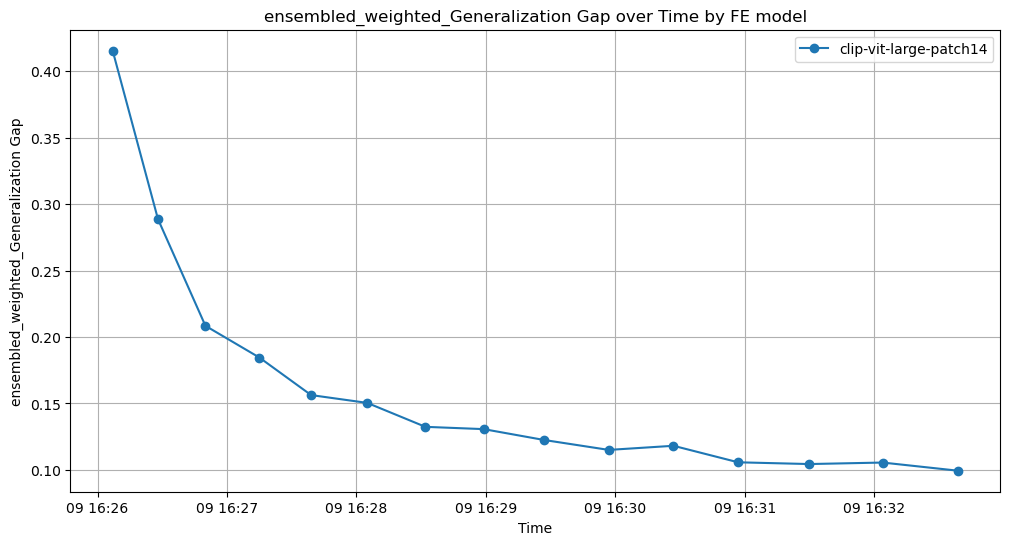

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for name, group in grouped:
    #plt.plot(group['time'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
    plt.plot(group['time'], group[f'{accuracy_metric}_Generalization Gap'], marker='o', label=name)
plt.xlabel('Time')
plt.ylabel(f'{accuracy_metric}_Generalization Gap')
plt.title(f'{accuracy_metric}_Generalization Gap over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

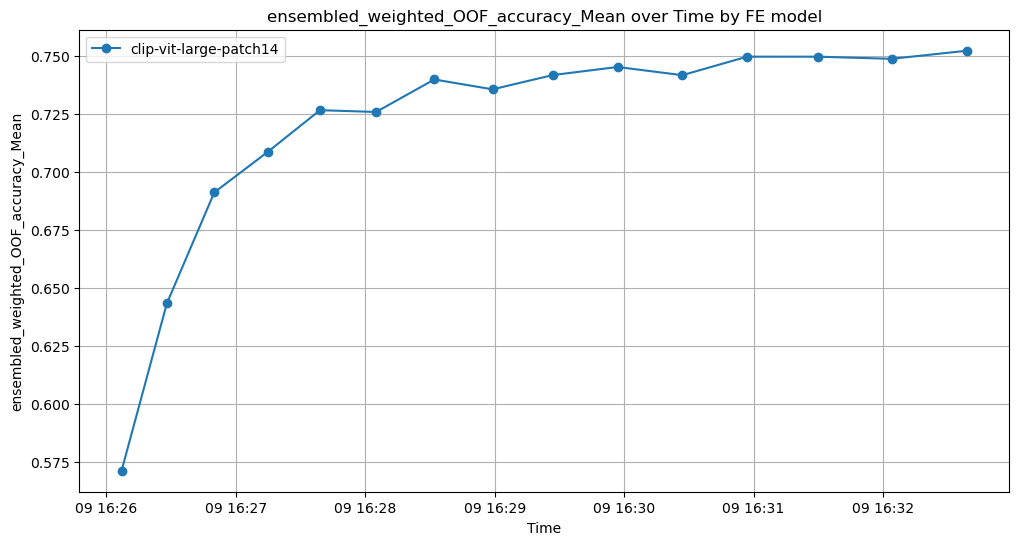

In [132]:
plt.figure(figsize=(12, 6))
for name, group in grouped:
    plt.plot(group['time'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
plt.xlabel('Time')
plt.ylabel(f'{accuracy_metric}_OOF_accuracy_Mean')
plt.title(f'{accuracy_metric}_OOF_accuracy_Mean over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

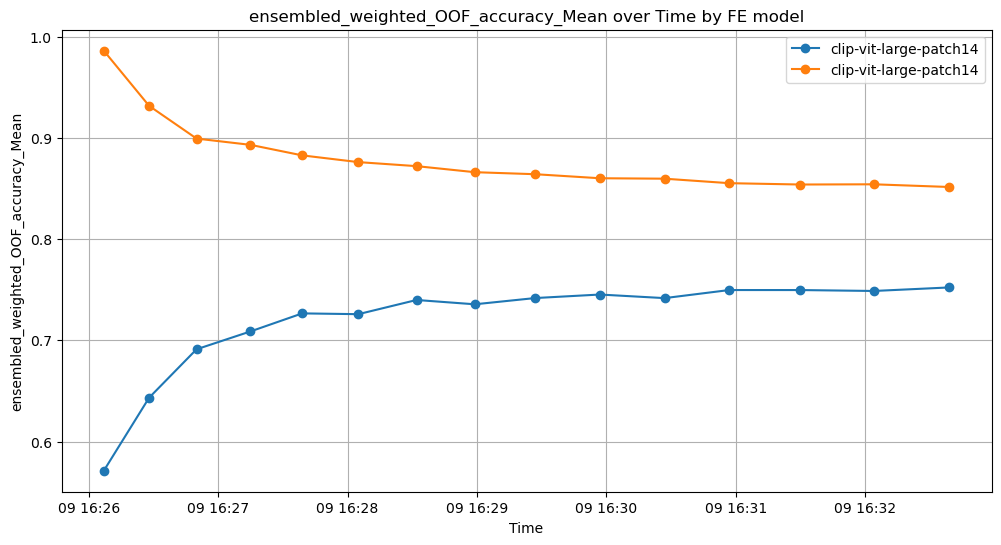

In [133]:
plt.figure(figsize=(12, 6))
for name, group in grouped:
    plt.plot(group['time'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
    plt.plot(group['time'], group[f'{accuracy_metric}_IF_accuracy_Mean'], marker='o', label=name)
plt.xlabel('Time')
plt.ylabel(f'{accuracy_metric}_OOF_accuracy_Mean')
plt.title(f'{accuracy_metric}_OOF_accuracy_Mean over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

## in depth analysis of dependence with n_writers

In [248]:
# model specific
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean','n_writers']
to_show = list(dict.fromkeys(to_show))
grouped=df_exp.groupby(['FE model'], as_index=False)
display_specific(grouped, n=30, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,n_writers
0,clip-vit-large-patch14,0.677600,-1.0
1,clip-vit-large-patch14,0.673069,-1.0
2,clip-vit-large-patch14,0.680128,-1.0
3,clip-vit-large-patch14,0.622613,-1.0
4,clip-vit-large-patch14,0.611241,-1.0
5,clip-vit-large-patch14,0.601808,-1.0
6,clip-vit-large-patch14,0.586805,-1.0
7,clip-vit-large-patch14,0.583224,-1.0
8,clip-vit-large-patch14,0.585529,-1.0
9,clip-vit-large-patch14,0.589558,-1.0


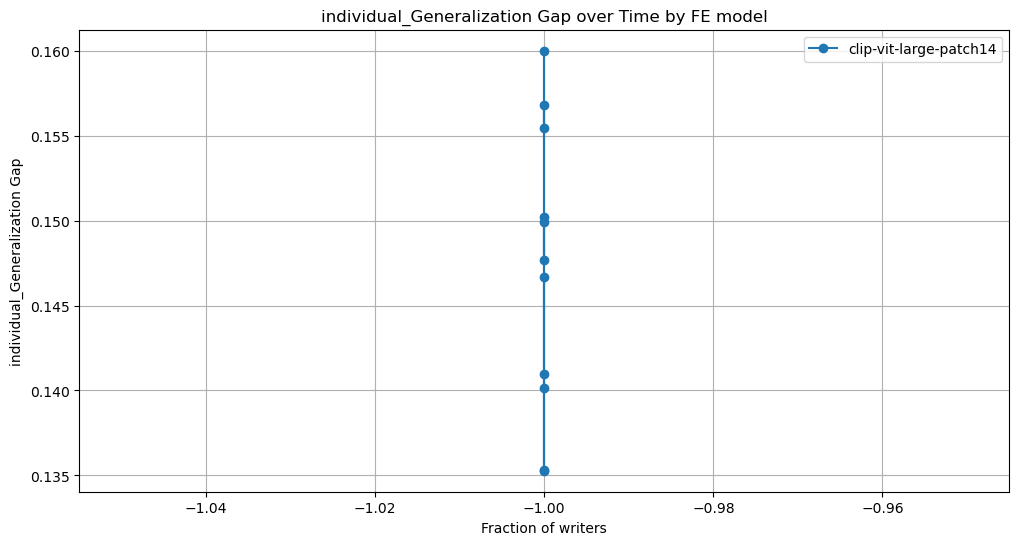

In [249]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for name, group in grouped:
    #plt.plot(group['time'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
    plt.plot(group['n_writers'], group[f'{accuracy_metric}_Generalization Gap'], marker='o', label=name)
plt.xlabel('Fraction of writers')
plt.ylabel(f'{accuracy_metric}_Generalization Gap')
plt.title(f'{accuracy_metric}_Generalization Gap over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

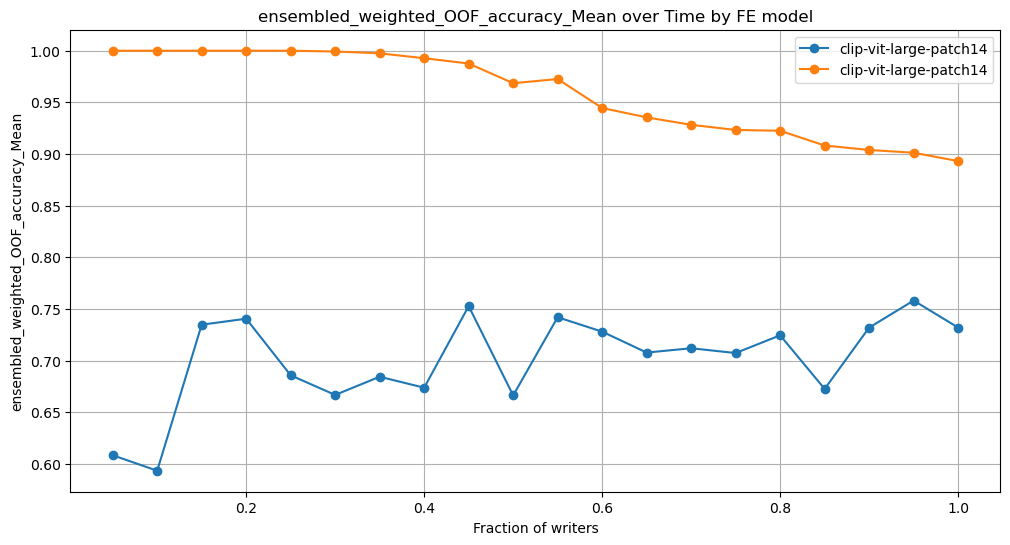

In [111]:
plt.figure(figsize=(12, 6))
for name, group in grouped:
    plt.plot(group['n_writers'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
    plt.plot(group['n_writers'], group[f'{accuracy_metric}_IF_accuracy_Mean'], marker='o', label=name)
plt.xlabel('Fraction of writers')
plt.ylabel(f'{accuracy_metric}_OOF_accuracy_Mean')
plt.title(f'{accuracy_metric}_OOF_accuracy_Mean over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

## in depth analysis patch size

In [250]:
# model specific
to_show=['FE model',f'{accuracy_metric}_OOF_accuracy_Mean','gw']
to_show = list(dict.fromkeys(to_show))
grouped=df_exp.sort_values(by='gw').groupby(['FE model'], as_index=False)
display_specific(grouped, n=30, cols=to_show)

,FE model,individual_OOF_accuracy_Mean,gw
1,clip-vit-large-patch14,0.673069,3.0
0,clip-vit-large-patch14,0.677600,5.0
2,clip-vit-large-patch14,0.680128,7.0
10,clip-vit-large-patch14,0.656952,10.0
3,clip-vit-large-patch14,0.622613,15.0
4,clip-vit-large-patch14,0.611241,20.0
5,clip-vit-large-patch14,0.601808,25.0
6,clip-vit-large-patch14,0.586805,30.0
7,clip-vit-large-patch14,0.583224,35.0
8,clip-vit-large-patch14,0.585529,40.0


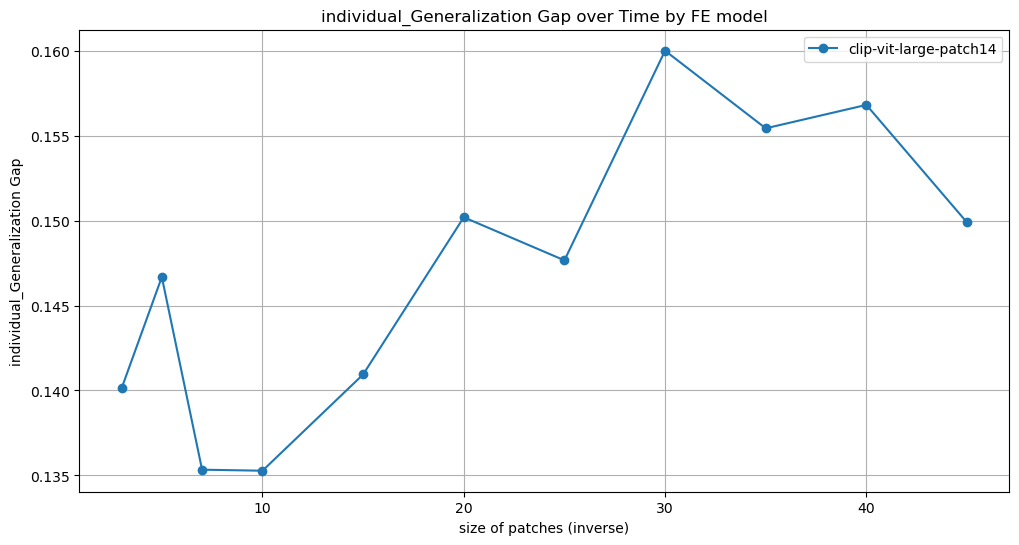

In [251]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for name, group in grouped:
    #plt.plot(group['time'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
    plt.plot(group['gw'], group[f'{accuracy_metric}_Generalization Gap'], marker='o', label=name)
plt.xlabel('size of patches (inverse)')
plt.ylabel(f'{accuracy_metric}_Generalization Gap')
plt.title(f'{accuracy_metric}_Generalization Gap over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

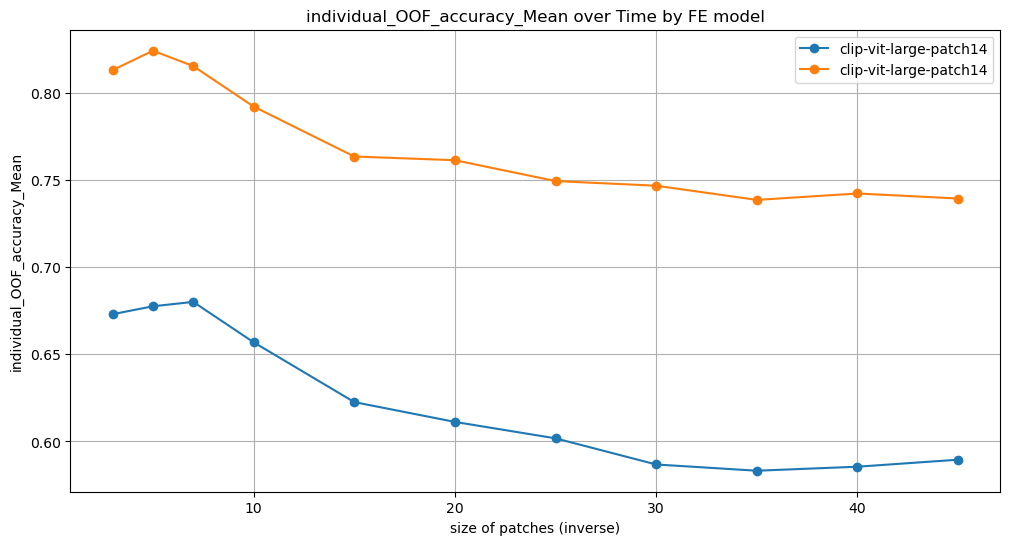

In [252]:
plt.figure(figsize=(12, 6))
for name, group in grouped:
    plt.plot(group['gw'], group[f'{accuracy_metric}_OOF_accuracy_Mean'], marker='o', label=name)
    plt.plot(group['gw'], group[f'{accuracy_metric}_IF_accuracy_Mean'], marker='o', label=name)
plt.xlabel('size of patches (inverse)')
plt.ylabel(f'{accuracy_metric}_OOF_accuracy_Mean')
plt.title(f'{accuracy_metric}_OOF_accuracy_Mean over Time by FE model')
plt.legend()
plt.grid(True)
plt.show()

## others

### pca, classifier models etc

In [125]:
filters={'with PCA':False}
display_specific(max_accuracy(df_exp, filters=filters, aggregation='ensembled').groupby('FE model', as_index=False).first().sort_values(by='ensembled_OOF_accuracy_Mean', ascending=False), 
              n=10, cols=['FE model','ensembled_OOF_accuracy_Mean','type of preprocessing','ensembled_IF_accuracy_Mean', 'individual_OOF_accuracy_Mean','classifier model','with PCA'])
display_specific(max_accuracy(df_exp, filters=filters, aggregation='individual').groupby('FE model', as_index=False).first().sort_values(by='individual_OOF_accuracy_Mean', ascending=False), 
              n=10, cols=['FE model','individual_OOF_accuracy_Mean','type of preprocessing','individual_OOF_accuracy_Mean','ensembled_OOF_accuracy_Mean','ensembled_IF_accuracy_Mean','classifier model','with PCA'])

,FE model,ensembled_OOF_accuracy_Mean,type of preprocessing,ensembled_IF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
0,clip-vit-large-patch14,0.794110,standard patches (5),1.000000,0.683352,lgbm,False
2,dresnet50,0.776316,standard patches (5),0.999111,0.645201,logreg,False
4,trocr-base-handwritten,0.776190,words-sentences (9),0.990250,0.651319,mlp,False
3,resnet50,0.762218,standard patches (15),0.963662,0.628544,logreg,False
8,vit-base-patch16-224-in21k,0.758584,standard patches (15),0.925542,0.651304,logreg,False
5,trocr-large-handwritten,0.758584,standard patches (5),0.968971,0.649684,logreg,False
1,crnn_vgg16_bn,0.726504,longer-than-higher (5),1.000000,0.608844,lgbm,False
7,trocr-small-stage1,0.716228,words-sentences (9),0.963630,0.605728,mlp,False
6,trocr-small-handwritten,0.674123,standard patches (5),0.853719,0.576974,logreg,False
9,vitstr_base,0.673308,words-sentences (9),0.877632,0.584221,logreg,False


,FE model,individual_OOF_accuracy_Mean,type of preprocessing,individual_OOF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_IF_accuracy_Mean,classifier model,with PCA
0,clip-vit-large-patch14,0.690226,standard patches (5),0.690226,0.787093,0.980531,mlp,False
4,trocr-base-handwritten,0.656205,words-sentences (9),0.656205,0.776128,0.930836,logreg,False
8,vit-base-patch16-224-in21k,0.654182,body (1),0.654182,0.709085,0.945019,mlp,False
3,resnet50,0.651551,body (1),0.651551,0.677318,1.000000,lgbm,False
5,trocr-large-handwritten,0.649684,standard patches (5),0.649684,0.758584,0.968971,logreg,False
2,dresnet50,0.645201,standard patches (5),0.645201,0.776316,0.999111,logreg,False
1,crnn_vgg16_bn,0.613426,words-sentences (9),0.613426,0.719298,0.848382,logreg,False
7,trocr-small-stage1,0.607007,words-sentences (9),0.607007,0.694549,0.843949,logreg,False
9,vitstr_base,0.584221,words-sentences (9),0.584221,0.673308,0.877632,logreg,False
6,trocr-small-handwritten,0.576974,standard patches (5),0.576974,0.674123,0.853719,logreg,False


In [144]:
filters={'classifier model':'mlp'}
display_specific(max_accuracy(df_exp, filters=filters, aggregation='ensembled').groupby('FE model', as_index=False).first().sort_values(by='ensembled_OOF_accuracy_Mean', ascending=False), 
              n=10, cols=['FE model','ensembled_OOF_accuracy_Mean','type of preprocessing','ensembled_IF_accuracy_Mean', 'individual_OOF_accuracy_Mean','classifier model','with PCA'])
display_specific(max_accuracy(df_exp, filters=filters, aggregation='individual').groupby('FE model', as_index=False).first().sort_values(by='individual_OOF_accuracy_Mean', ascending=False), 
              n=10, cols=['FE model','individual_OOF_accuracy_Mean','type of preprocessing','individual_OOF_accuracy_Mean','ensembled_OOF_accuracy_Mean','ensembled_IF_accuracy_Mean','classifier model','with PCA'])

,FE model,ensembled_OOF_accuracy_Mean,type of preprocessing,ensembled_IF_accuracy_Mean,individual_OOF_accuracy_Mean,classifier model,with PCA
0,clip-vit-large-patch14,0.787093,standard patches (5),0.980531,0.690226,mlp,False
4,trocr-base-handwritten,0.776190,words-sentences (9),0.990250,0.651319,mlp,False
8,vit-base-patch16-224-in21k,0.765789,words-sentences (9),1.000000,0.635049,mlp,True
3,resnet50,0.747995,standard patches (15),1.000000,0.613009,mlp,True
2,dresnet50,0.740915,standard patches (5),0.987611,0.643280,mlp,False
5,trocr-large-handwritten,0.737531,standard patches (5),0.983135,0.638026,mlp,False
1,crnn_vgg16_bn,0.726378,words-sentences (9),0.889278,0.604475,mlp,True
7,trocr-small-stage1,0.716228,words-sentences (9),0.963630,0.605728,mlp,False
6,trocr-small-handwritten,0.656203,standard patches (5),0.923819,0.562989,mlp,True
9,vitstr_base,0.652569,standard patches (5),0.955658,0.568142,mlp,False


,FE model,individual_OOF_accuracy_Mean,type of preprocessing,individual_OOF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_IF_accuracy_Mean,classifier model,with PCA
0,clip-vit-large-patch14,0.690226,standard patches (5),0.690226,0.787093,0.980531,mlp,False
8,vit-base-patch16-224-in21k,0.654182,body (1),0.654182,0.709085,0.945019,mlp,False
4,trocr-base-handwritten,0.651319,words-sentences (9),0.651319,0.776190,0.990250,mlp,False
2,dresnet50,0.643280,standard patches (5),0.643280,0.740915,0.987611,mlp,False
5,trocr-large-handwritten,0.638026,standard patches (5),0.638026,0.737531,0.983135,mlp,False
3,resnet50,0.628368,body (1),0.628368,0.662845,0.905200,mlp,True
1,crnn_vgg16_bn,0.607169,words-sentences (9),0.607169,0.705075,0.943268,mlp,False
7,trocr-small-stage1,0.605728,words-sentences (9),0.605728,0.716228,0.963630,mlp,False
9,vitstr_base,0.568142,standard patches (5),0.568142,0.652569,0.955658,mlp,False
6,trocr-small-handwritten,0.562989,standard patches (5),0.562989,0.656203,0.923819,mlp,True


In [148]:
df_exp[df_exp['FE model']=='vit-base-patch16-224-in21k'][['experiment','ensembled_Generalization Gap','FE model','type of preprocessing','classifier model','with PCA']].sort_values(by='experiment', ascending=True)

,experiment,ensembled_Generalization Gap,FE model,type of preprocessing,classifier model,with PCA
167,103_20250530_002249,0.104767,vit-base-patch16-224-in21k,words-sentences (9),logreg,True
168,104_20250530_002301,0.204892,vit-base-patch16-224-in21k,words-sentences (9),logreg,False
169,105_20250530_002316,0.234211,vit-base-patch16-224-in21k,words-sentences (9),mlp,True
170,106_20250530_002343,0.284626,vit-base-patch16-224-in21k,words-sentences (9),mlp,False
171,107_20250530_002414,0.283897,vit-base-patch16-224-in21k,words-sentences (9),lgbm,True
172,108_20250530_002524,0.273120,vit-base-patch16-224-in21k,words-sentences (9),lgbm,False
179,115_20250530_002714,0.158793,vit-base-patch16-224-in21k,standard patches (15),logreg,True
180,116_20250530_002729,0.166958,vit-base-patch16-224-in21k,standard patches (15),logreg,False
181,117_20250530_002756,0.237719,vit-base-patch16-224-in21k,standard patches (15),mlp,True
182,118_20250530_002836,0.254754,vit-base-patch16-224-in21k,standard patches (15),mlp,False


In [142]:
groups=df_exp.groupby(['classifier model'])
display_specific(aggregate_statistics(groups,['ensembled_OOF_accuracy_Mean','individual_OOF_accuracy_Mean',
                                              'ensembled_Generalization Gap','individual_Generalization Gap'],['mean','max'])
                                                                                                          , n=100)
#display_specific(aggregate_statistics(groups,['ensembled_OOF_accuracy_Mean','individual_OOF_accuracy_Mean'],['mean','max']).sort_values(("ensembled_OOF_accuracy_Mean", "max"), ascending=False), n=10)
#display_group(groups, n=2, cols=ensembled_acc_cols+exp_properties)

classifier model ensembled_OOF_accuracy_Mean            \
                                          mean       max   
0               dt                    0.584774  0.602256   
1              gbm                    0.634336  0.634336   
2             lgbm                    0.686764  0.794110   
3           logreg                    0.700792  0.776316   
4              mlp                    0.698104  0.787093   
5               rf                    0.643452  0.648622   
6              svm                    0.652256  0.680639   
7            torch                    0.644191  0.694549   

  individual_OOF_accuracy_Mean           ensembled_Generalization Gap  \
                          mean       max                         mean   
0                     0.558100  0.560392                     0.131513   
1                     0.604571  0.604571                     0.319572   
2                     0.606433  0.683352                     0.307340   
3                     0.617821  0.687419                     0.157888   
4                     0.611678  0.690226                     0.256619   
5                     0.594002  0.596830                     0.356548   
6                     0.607024  0.616808                     0.176191   
7                     0.602880  0.636864                     0.213826   

            individual_Generalization Gap            
        max                          mean       max  
0  0.216006                      0.070965  0.117521  
1  0.319572                      0.228717  0.228717  
2  0.383271                      0.364781  0.463777  
3  0.365602                      0.116559  0.371570  
4  0.355044                      0.240668  0.361407  
5  0.361717                      0.402141  0.408825  
6  0.240474                      0.131639  0.188861  
7  0.305368                      0.163763  0.297520

In [93]:
pca= df_exp[df_exp['with PCA']==True]
non_pca= df_exp[df_exp['with PCA']==False]
display(pca[ensembled_acc_cols+individual_acc_cols].describe())
display(non_pca[ensembled_acc_cols+individual_acc_cols].describe())

,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,individual_IF_accuracy_Mean,individual_OOF_accuracy_Mean,individual_Generalization Gap
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,0.898969,0.687478,0.211491,0.806300,0.609830,0.196470
std,0.096337,0.042122,0.096780,0.128273,0.029873,0.129123
min,0.694136,0.605952,0.050722,0.584605,0.534202,0.031682
25%,0.831552,0.654135,0.115139,0.703371,0.590702,0.071503
50%,0.910608,0.687469,0.237719,0.769700,0.609677,0.188861
75%,0.999115,0.719518,0.300954,0.937514,0.634703,0.327634
max,1.000000,0.765789,0.383271,1.000000,0.687419,0.463777


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,individual_IF_accuracy_Mean,individual_OOF_accuracy_Mean,individual_Generalization Gap
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,0.951113,0.696821,0.254292,0.868563,0.612970,0.255592
std,0.070797,0.051374,0.063526,0.113592,0.031749,0.108634
min,0.614313,0.535840,0.047019,0.580218,0.540830,0.024410
25%,0.931515,0.659273,0.213053,0.790334,0.591113,0.169636
50%,0.981833,0.701692,0.251692,0.889223,0.616778,0.245001
75%,1.000000,0.734038,0.304858,0.995534,0.636462,0.358069
max,1.000000,0.794110,0.365789,1.000000,0.690226,0.459047


### evaluating model on different preprocessed datasets

In [113]:
# trocr-base-handwritten, vit-base-patch16-224-in21k, resnet50
df_specific=df_exp[df_exp['FE model']=='resnet50']
display_specific(max_accuracy(df_specific, filters=None, aggregation='ensembled').groupby('type of preprocessing', as_index=False).first().sort_values(by='ensembled_OOF_accuracy_Mean', ascending=False), 
              n=10, cols=['type of preprocessing','ensembled_OOF_accuracy_Mean','ensembled_IF_accuracy_Mean', 'individual_OOF_accuracy_Mean',
                                              'FE model','classifier model','with PCA'])
display_specific(max_accuracy(df_specific, filters=None, aggregation='individual').groupby('type of preprocessing', as_index=False).first().sort_values(by='individual_OOF_accuracy_Mean', ascending=False), 
              n=10, cols=['type of preprocessing','FE model','individual_OOF_accuracy_Mean','individual_OOF_accuracy_Mean','ensembled_OOF_accuracy_Mean','ensembled_IF_accuracy_Mean','classifier model','with PCA'])

,type of preprocessing,ensembled_OOF_accuracy_Mean,ensembled_IF_accuracy_Mean,individual_OOF_accuracy_Mean,FE model,classifier model,with PCA
2,standard patches (15),0.762218,0.963662,0.628544,resnet50,logreg,False
3,standard patches (5),0.730138,1.000000,0.630680,resnet50,lgbm,False
1,small_patches (5),0.726692,0.994682,0.622751,resnet50,mlp,False
0,body (1),0.677318,1.000000,0.651551,resnet50,lgbm,False


,type of preprocessing,FE model,individual_OOF_accuracy_Mean,individual_OOF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_IF_accuracy_Mean,classifier model,with PCA
0,body (1),resnet50,0.651551,0.651551,0.677318,1.000000,lgbm,False
2,standard patches (15),resnet50,0.633954,0.633954,0.723308,0.853699,logreg,True
3,standard patches (5),resnet50,0.630680,0.630680,0.730138,1.000000,lgbm,False
1,small_patches (5),resnet50,0.622751,0.622751,0.726692,0.994682,mlp,False


In [114]:
selected_model = 'resnet50'
print(f"model:{selected_model}")
file_names=get_unique(df,col='original raw file')
selected_experiments = df_2[df_2['experiment'].isin(file_names)]
display(selected_experiments[['experiment', 'm patches']])
groups=fixed_model_varying_inputs(df_exp, model_name=selected_model,filters=None,grouping_cols=['original raw file','type of preprocessing'],feature='ensembled_OOF_accuracy_Mean',ascending=False)
display_specific(aggregate_statistics(groups,['ensembled_OOF_accuracy_Mean','individual_OOF_accuracy_Mean'],['mean','max']), n=10)
display_group(groups, n=2, cols=ensembled_acc_cols+exp_properties)
#groups=fixed_model_varying_inputs(df_exp, model_name=selected_model,filters=None,feature='type of preprocessing',ascending=False)
#display_specific(aggregate_statistics(groups,['ensembled_OOF_accuracy_Mean','individual_OOF_accuracy_Mean'],['mean','max']), n=10)


model:resnet50


,experiment,m patches
4,icdar_train_df_patches_20250515_164130.csv,5.0
18,icdar_train_df_patches_20250521_120324.csv,5.0
19,icdar_train_df_words_sentences_20250522_230307...,9.0
20,icdar_train_df_patches_20250522_234152.csv,5.0
21,icdar_train_df_patches_20250522_235724.csv,15.0
25,icdar_train_df_body_20250523_181312.csv,1.0


original raw file  type of preprocessing  \
                                                                       
0     icdar_train_df_body_20250523_181312.csv               body (1)   
1  icdar_train_df_patches_20250515_164130.csv   standard patches (5)   
2  icdar_train_df_patches_20250521_120324.csv      small_patches (5)   
3  icdar_train_df_patches_20250522_235724.csv  standard patches (15)   

  ensembled_OOF_accuracy_Mean           individual_OOF_accuracy_Mean            
                         mean       max                         mean       max  
0                    0.653509  0.677318                     0.627987  0.651551  
1                    0.689380  0.730138                     0.606174  0.630680  
2                    0.686539  0.726692                     0.608925  0.622751  
3                    0.729762  0.762218                     0.623791  0.633954

Group: ('icdar_train_df_body_20250523_181312.csv', 'body (1)')


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
214,1.0,0.677318,0.322682,body (1),resnet50,lgbm,False,"{'boosting_type': 'gbdt', 'class_weight': None..."
213,1.0,0.673559,0.326441,body (1),resnet50,lgbm,True,"{'boosting_type': 'gbdt', 'class_weight': None..."


...

----------------------------------------
Group: ('icdar_train_df_patches_20250521_120324.csv', 'small_patches (5)')


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
152,0.994682,0.726692,0.267991,small_patches (5),resnet50,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
154,1.000000,0.712406,0.287594,small_patches (5),resnet50,lgbm,False,"{'boosting_type': 'gbdt', 'class_weight': None..."


----------------------------------------
Group: ('icdar_train_df_patches_20250522_235724.csv', 'standard patches (15)')


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
192,0.963662,0.762218,0.201444,standard patches (15),resnet50,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
193,1.000000,0.747995,0.252005,standard patches (15),resnet50,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


----------------------------------------


In [ ]:
###

### Compare average and max values in groups

In [115]:
datasets=['icdar_train_df_body_20250523_181312.csv', 'icdar_train_df_patches_20250515_164130.csv']
filtered_df= df_exp[df_exp['original raw file'].isin(datasets)]
selected_model = 'resnet50'
print(f"model:{selected_model}")
groups=fixed_model_varying_inputs(df_exp, model_name=selected_model,filters=None,grouping_cols=['type of preprocessing'],feature='ensembled_OOF_accuracy_Mean',ascending=False)
display_specific(aggregate_statistics(groups,['ensembled_OOF_accuracy_Mean','individual_OOF_accuracy_Mean',
                                              'ensembled_Generalization Gap','individual_Generalization Gap'],['mean','max']).sort_values(("ensembled_Generalization Gap", "mean")
                                                                                                          , ascending=True), n=10)
#display_specific(aggregate_statistics(groups,['ensembled_OOF_accuracy_Mean','individual_OOF_accuracy_Mean'],['mean','max']).sort_values(("ensembled_OOF_accuracy_Mean", "max"), ascending=False), n=10)
#display_group(groups, n=2, cols=ensembled_acc_cols+exp_properties)

model:resnet50


type of preprocessing ensembled_OOF_accuracy_Mean            \
                                                mean       max   
2  standard patches (15)                    0.729762  0.762218   
1      small_patches (5)                    0.686539  0.726692   
3   standard patches (5)                    0.689380  0.730138   
0               body (1)                    0.653509  0.677318   

  individual_OOF_accuracy_Mean           ensembled_Generalization Gap  \
                          mean       max                         mean   
2                     0.623791  0.633954                     0.239356   
1                     0.608925  0.622751                     0.286133   
3                     0.606174  0.630680                     0.294367   
0                     0.627987  0.651551                     0.300236   

            individual_Generalization Gap            
        max                          mean       max  
2  0.294424                      0.275796  0.374111  
1  0.365602                      0.299256  0.389637  
3  0.333459                      0.323747  0.383296  
0  0.354825                      0.293398  0.371570

In [68]:
display_specific(max_accuracy(df_exp, filters=None, aggregation='ensembled'), n=10, cols=ensembled_acc_cols+exp_properties)
display_specific(max_accuracy(df_exp, filters={'FE model':'trocr-base-handwritten'}, aggregation='ensembled'), n=10, cols=ensembled_acc_cols+exp_properties)
display_specific(max_accuracy(df_exp, filters={'type of preprocessing':'standard patches'}, aggregation='ensembled'), n=10, cols=ensembled_acc_cols+exp_properties)
display_specific(max_accuracy(df_exp, filters={'FE model':'trocr-base-handwritten','type of preprocessing':'standard patches'}, aggregation='ensembled'), n=10, cols=ensembled_acc_cols+exp_properties)
display(get_occurrences(df_exp,'original raw file'))
display(get_occurrences(df_exp,'type of preprocessing'))
display(get_occurrences(df_exp,'FE model'))
print(fe_applied_on_source(df_exp, 'icdar_train_df_patches_20250515_164130.csv'))
df_exp[ensembled_acc_cols].describe()

,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
127,1.000000,0.794110,0.205890,standard patches,clip-vit-large-patch14,lgbm,False,"{'boosting_type': 'gbdt', 'class_weight': None..."
126,0.980531,0.787093,0.193438,standard patches,clip-vit-large-patch14,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
73,0.980531,0.787093,0.193438,standard patches,clip-vit-large-patch14,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
132,0.999111,0.776316,0.222795,standard patches,dresnet50,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
95,0.946793,0.776253,0.170539,standard patches,clip-vit-large-patch14,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
164,0.990250,0.776190,0.214059,words-sentences,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
56,0.990250,0.776190,0.214059,words-sentences,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
55,0.930836,0.776128,0.154708,words-sentences,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
162,0.930836,0.776128,0.154708,words-sentences,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
166,1.000000,0.772744,0.227256,words-sentences,trocr-base-handwritten,lgbm,False,"{'boosting_type': 'gbdt', 'class_weight': None..."


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
56,0.990250,0.776190,0.214059,words-sentences,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
164,0.990250,0.776190,0.214059,words-sentences,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
162,0.930836,0.776128,0.154708,words-sentences,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
55,0.930836,0.776128,0.154708,words-sentences,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
166,1.000000,0.772744,0.227256,words-sentences,trocr-base-handwritten,lgbm,False,"{'boosting_type': 'gbdt', 'class_weight': None..."
222,0.948559,0.769173,0.179386,longer-than-higher,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
224,0.997333,0.766103,0.231231,longer-than-higher,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
51,0.991150,0.762218,0.228932,standard patches,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
188,0.991150,0.762218,0.228932,standard patches,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
163,0.977845,0.758584,0.219261,words-sentences,trocr-base-handwritten,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
127,1.000000,0.794110,0.205890,standard patches,clip-vit-large-patch14,lgbm,False,"{'boosting_type': 'gbdt', 'class_weight': None..."
73,0.980531,0.787093,0.193438,standard patches,clip-vit-large-patch14,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
126,0.980531,0.787093,0.193438,standard patches,clip-vit-large-patch14,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
132,0.999111,0.776316,0.222795,standard patches,dresnet50,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
95,0.946793,0.776253,0.170539,standard patches,clip-vit-large-patch14,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
181,1.000000,0.762281,0.237719,standard patches,vit-base-patch16-224-in21k,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
188,0.991150,0.762218,0.228932,standard patches,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
51,0.991150,0.762218,0.228932,standard patches,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
192,0.963662,0.762218,0.201444,standard patches,resnet50,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
125,0.895379,0.762030,0.133348,standard patches,clip-vit-large-patch14,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,type of preprocessing,FE model,classifier model,with PCA,model_params
188,0.991150,0.762218,0.228932,standard patches,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
51,0.991150,0.762218,0.228932,standard patches,trocr-base-handwritten,mlp,False,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
49,0.836869,0.758459,0.078411,standard patches,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
185,0.836869,0.758459,0.078411,standard patches,trocr-base-handwritten,logreg,True,"{'C': 1.0, 'class_weight': None, 'dual': False..."
50,0.913117,0.758396,0.154721,standard patches,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
186,0.913117,0.758396,0.154721,standard patches,trocr-base-handwritten,logreg,False,"{'C': 1.0, 'class_weight': None, 'dual': False..."
189,1.000000,0.751378,0.248622,standard patches,trocr-base-handwritten,lgbm,True,"{'boosting_type': 'gbdt', 'class_weight': None..."
53,1.000000,0.751378,0.248622,standard patches,trocr-base-handwritten,lgbm,True,"{'boosting_type': 'gbdt', 'class_weight': None..."
52,0.971587,0.747682,0.223905,standard patches,trocr-base-handwritten,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
187,0.971587,0.747682,0.223905,standard patches,trocr-base-handwritten,mlp,True,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


,original raw file,count
0,icdar_train_df_patches_20250515_164130.csv,127
1,icdar_train_df_words_sentences_20250522_230307...,34
2,icdar_train_df_patches_20250521_120324.csv,25
3,icdar_train_df_patches_20250522_235724.csv,23
4,icdar_train_df_body_20250523_181312.csv,18
5,icdar_train_df_patches_20250522_234152.csv,18


,type of preprocessing,count
0,standard patches,142
1,words-sentences,34
2,small_patches,25
3,body,18
4,longer-than-higher,18
5,patch_dataset,8


,FE model,count
0,trocr-base-handwritten,93
1,crnn_vgg16_bn,30
2,resnet50,30
3,vit-base-patch16-224-in21k,30
4,trocr-small-stage1,25
5,vitstr_base,13
6,clip-vit-large-patch14,6
7,trocr-small-handwritten,6
8,trocr-large-handwritten,6
9,dresnet50,6


['trocr-base-handwritten', 'trocr-small-stage1', 'trocr-small-handwritten', 'crnn_vgg16_bn', 'clip-vit-large-patch14', 'vit-base-patch16-224-in21k', 'trocr-large-handwritten', 'resnet50', 'dresnet50', 'vitstr_base']


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap
count,245.000000,245.000000,245.000000
mean,0.926637,0.692436,0.234201
std,0.087556,0.047393,0.083473
min,0.614313,0.535840,0.047019
25%,0.872326,0.656203,0.179386
50%,0.956574,0.691291,0.248246
75%,1.000000,0.726504,0.300954
max,1.000000,0.794110,0.383271


In [69]:
df['prefix'] = df['experiment'].str.extract(r'^(\d+)(?=_\d{8}_\d{6})')

In [70]:
df['prefix'] = df['prefix'].fillna('-1').astype(int)

In [71]:
import numpy as np
np.sort(df['prefix'].unique())

array([ -1,   1,   2,   3,   5,   6,   7,   8,   9,  10,  12,  13,  14,
        15,  16,  18,  19,  20,  21,  22,  24,  25,  26,  28,  30,  31,
        32,  34,  36,  37,  38,  40,  42,  43,  44,  46,  48,  49,  50,
        51,  52,  54,  55,  56,  57,  58,  60,  61,  62,  63,  64,  66,
        67,  68,  69,  70,  72,  73,  74,  76,  78,  79,  80,  82,  83,
        84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
        97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
       110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122,
       123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
       136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148,
       149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
       162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
       175, 176, 177, 178, 179, 180])

In [72]:
print(df_exp.columns)

Index(['experiment', 'type of preprocessing', 'original raw file',
       'input file', 'FE model', 'FE transform', 'classifier model',
       'model_params', 'n_splits', 'train_on_language', 'train_on_same',
       'task', 'with cross validation', 'with PCA',
       'training time for cross-validation', 'training time for final model',
       'cross_val_accuracies', 'subgroup_accuracies', 'is_kaggle',
       'description', 'test', 'n_components', 'ensembled_IF_accuracy_Mean',
       'ensembled_IF_accuracy_Variance', 'ensembled_IF_accuracy_Min',
       'ensembled_IF_accuracy_Max', 'ensembled_IF_accuracy_Median',
       'ensembled_IF_accuracy_Confidence Interval',
       'ensembled_OOF_accuracy_Mean', 'ensembled_OOF_accuracy_Variance',
       'ensembled_OOF_accuracy_Min', 'ensembled_OOF_accuracy_Max',
       'ensembled_OOF_accuracy_Median',
       'ensembled_OOF_accuracy_Confidence Interval',
       'ensembled_Generalization Gap', 'individual_IF_accuracy_Mean',
       'individual_IF_acc

In [73]:
df_exp=df_exp.sort_values(by='ensembled_OOF_accuracy_Mean', ascending=False)

In [74]:
df['type of preprocessing'].unique()

array(['patch_dataset', 'standard patches', 'small_patches',
       'words-sentences', 'body', 'longer-than-higher'], dtype=object)

In [75]:
df_exp[df_exp['type of preprocessing']=='words-sentences'][['ensembled_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap','classifier model',
                'n_components','with PCA','experiment','model_params','type of preprocessing','FE model']]

,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,classifier model,n_components,with PCA,experiment,model_params,type of preprocessing,FE model
164,0.990250,0.776190,0.214059,mlp,0.95,False,100_20250530_002107,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",words-sentences,trocr-base-handwritten
56,0.990250,0.776190,0.214059,mlp,0.95,False,20250529_190556,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",words-sentences,trocr-base-handwritten
55,0.930836,0.776128,0.154708,logreg,0.95,False,20250529_190246,"{'C': 1.0, 'class_weight': None, 'dual': False...",words-sentences,trocr-base-handwritten
162,0.930836,0.776128,0.154708,logreg,0.95,False,98_20250530_002030,"{'C': 1.0, 'class_weight': None, 'dual': False...",words-sentences,trocr-base-handwritten
166,1.000000,0.772744,0.227256,lgbm,0.95,False,102_20250530_002241,"{'boosting_type': 'gbdt', 'class_weight': None...",words-sentences,trocr-base-handwritten
169,1.000000,0.765789,0.234211,mlp,0.95,True,105_20250530_002316,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",words-sentences,vit-base-patch16-224-in21k
167,0.866985,0.762218,0.104767,logreg,0.95,True,103_20250530_002249,"{'C': 1.0, 'class_weight': None, 'dual': False...",words-sentences,vit-base-patch16-224-in21k
163,0.977845,0.758584,0.219261,mlp,0.95,True,99_20250530_002044,"{'activation': 'relu', 'alpha': 0.0001, 'batch...",words-sentences,trocr-base-handwritten
165,1.000000,0.755138,0.244862,lgbm,0.95,True,101_20250530_002134,"{'boosting_type': 'gbdt', 'class_weight': None...",words-sentences,trocr-base-handwritten
161,0.835088,0.751316,0.083772,logreg,0.95,True,97_20250530_002017,"{'C': 1.0, 'class_weight': None, 'dual': False...",words-sentences,trocr-base-handwritten


In [76]:
filtered_df = df_exp[df_exp['input file'] == 'icdar_EXTRACTED_train_df_trocr-base-handwritten_20250523_225140.csv']
filtered_df_sorted = filtered_df.sort_values(by='ensembled_OOF_accuracy_Mean', ascending=False)
filtered_df_sorted_2 = filtered_df.sort_values(by='individual_OOF_accuracy_Mean', ascending=False)
filtered_df_sorted_by_model = filtered_df.sort_values(by='classifier model')

In [77]:
show_columns = ['ensembled_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap','classifier model',
                'n_components','with PCA','experiment','model_params']   

#grouped = filtered_df_sorted.groupby('classifier model')[show_columns]
#grouped[show_columns]
#print(grouped)
filtered_df_sorted[show_columns]
#filtered_df_sorted_by_model[show_columns]


,ensembled_IF_accuracy_Mean,ensembled_OOF_accuracy_Mean,ensembled_Generalization Gap,classifier model,n_components,with PCA,experiment,model_params
203,0.751764,0.680702,0.071062,logreg,0.95,True,139_20250530_004528,"{'C': 1.0, 'class_weight': None, 'dual': False..."
208,1.000000,0.655764,0.344236,lgbm,0.95,False,144_20250530_004606,"{'boosting_type': 'gbdt', 'class_weight': None..."
204,0.996452,0.648308,0.348144,logreg,0.95,False,140_20250530_004533,"{'C': 1.0, 'class_weight': None, 'dual': False..."
206,0.819186,0.631078,0.188108,mlp,0.95,False,142_20250530_004545,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
205,0.761542,0.627757,0.133785,mlp,0.95,True,141_20250530_004539,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
207,1.000000,0.627130,0.372870,lgbm,0.95,True,143_20250530_004553,"{'boosting_type': 'gbdt', 'class_weight': None..."


In [78]:
show_columns = ['individual_IF_accuracy_Mean', 'individual_OOF_accuracy_Mean', 'individual_Generalization Gap','classifier model','n_components','with PCA','experiment','model_params']   
filtered_df_sorted_2[show_columns]

,individual_IF_accuracy_Mean,individual_OOF_accuracy_Mean,individual_Generalization Gap,classifier model,n_components,with PCA,experiment,model_params
203,0.701446,0.645238,0.056208,logreg,0.95,True,139_20250530_004528,"{'C': 1.0, 'class_weight': None, 'dual': False..."
208,1.000000,0.618687,0.381313,lgbm,0.95,False,144_20250530_004606,"{'boosting_type': 'gbdt', 'class_weight': None..."
204,0.967418,0.614897,0.352521,logreg,0.95,False,140_20250530_004533,"{'C': 1.0, 'class_weight': None, 'dual': False..."
205,0.717650,0.610824,0.106826,mlp,0.95,True,141_20250530_004539,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."
207,1.000000,0.596319,0.403681,lgbm,0.95,True,143_20250530_004553,"{'boosting_type': 'gbdt', 'class_weight': None..."
206,0.746251,0.592199,0.154051,mlp,0.95,False,142_20250530_004545,"{'activation': 'relu', 'alpha': 0.0001, 'batch..."


In [79]:
unique_model_names = filtered_df_sorted['classifier model'].unique()
print(unique_model_names)

['logreg' 'lgbm' 'mlp']


In [80]:
best_indices = []
for model in unique_model_names:
    model_group = filtered_df_sorted[filtered_df_sorted['classifier model'] == model]
    if not model_group.empty:
        idx = model_group['ensembled_OOF_accuracy_Mean'].idxmax()
        best_indices.append(idx)
print(best_indices)

[np.int64(203), np.int64(208), np.int64(206)]


In [81]:
result = []
for ind in best_indices:
    row = filtered_df_sorted.loc[ind]
    res = {
        'index': ind,
        'model': row['classifier model'],
        'with PCA': row['with PCA'],
        'individual_Generalization Gap': row['individual_Generalization Gap'],
        'individual_OOF_accuracy_Mean': row['individual_OOF_accuracy_Mean'],
        'individual_IF_accuracy_Mean': row['individual_IF_accuracy_Mean'],
        'ensembled_Generalization Gap': row['ensembled_Generalization Gap'],
        'ensembled_OOF_accuracy_Mean': row['ensembled_OOF_accuracy_Mean'],
        'ensembled_IF_accuracy_Mean': row['ensembled_IF_accuracy_Mean'],
        'diff_Generalization Gap': row['ensembled_Generalization Gap'] - row['individual_Generalization Gap'],
        'diff_OOF_accuracy_Mean': row['ensembled_OOF_accuracy_Mean'] - row['individual_OOF_accuracy_Mean'],
        'diff_IF_accuracy_Mean': row['ensembled_IF_accuracy_Mean'] - row['individual_IF_accuracy_Mean'],
    }
    result.append(res)

pd.DataFrame(result)

,index,model,with PCA,individual_Generalization Gap,individual_OOF_accuracy_Mean,individual_IF_accuracy_Mean,ensembled_Generalization Gap,ensembled_OOF_accuracy_Mean,ensembled_IF_accuracy_Mean,diff_Generalization Gap,diff_OOF_accuracy_Mean,diff_IF_accuracy_Mean
0,203,logreg,True,0.056208,0.645238,0.701446,0.071062,0.680702,0.751764,0.014854,0.035464,0.050318
1,208,lgbm,False,0.381313,0.618687,1.000000,0.344236,0.655764,1.000000,-0.037077,0.037077,0.000000
2,206,mlp,False,0.154051,0.592199,0.746251,0.188108,0.631078,0.819186,0.034057,0.038878,0.072935


In [82]:
filtered_df = df_exp[(df_exp['type of preprocessing'] == 'patch_dataset') & (df_exp['FE model'] == 'trocr-base-handwritten')]

In [83]:
print([col for col in filtered_df.columns if 'acc' in col.lower()])

['cross_val_accuracies', 'subgroup_accuracies', 'ensembled_IF_accuracy_Mean', 'ensembled_IF_accuracy_Variance', 'ensembled_IF_accuracy_Min', 'ensembled_IF_accuracy_Max', 'ensembled_IF_accuracy_Median', 'ensembled_IF_accuracy_Confidence Interval', 'ensembled_OOF_accuracy_Mean', 'ensembled_OOF_accuracy_Variance', 'ensembled_OOF_accuracy_Min', 'ensembled_OOF_accuracy_Max', 'ensembled_OOF_accuracy_Median', 'ensembled_OOF_accuracy_Confidence Interval', 'individual_IF_accuracy_Mean', 'individual_IF_accuracy_Variance', 'individual_IF_accuracy_Min', 'individual_IF_accuracy_Max', 'individual_IF_accuracy_Median', 'individual_IF_accuracy_Confidence Interval', 'individual_OOF_accuracy_Mean', 'individual_OOF_accuracy_Variance', 'individual_OOF_accuracy_Min', 'individual_OOF_accuracy_Max', 'individual_OOF_accuracy_Median', 'individual_OOF_accuracy_Confidence Interval']


In [84]:
filtered_df[['experiment', 'IF_accuracy_Mean','IF_accuracy_Variance','OOF_accuracy_Mean','OOF_accuracy_Variance','Generalization Gap']].head()

KeyError: "['IF_accuracy_Mean', 'IF_accuracy_Variance', 'OOF_accuracy_Mean', 'OOF_accuracy_Variance', 'Generalization Gap'] not in index"

# easy access

In [3]:
def reload_modules():
    import importlib
    import utils.file_IO as file_IO
    
    importlib.reload(file_IO)

    return file_IO
file_IO = reload_modules()

## functions

### experiment analysis functions

In [4]:
#extraction
def get_models_on_source(df,source_file):
    # get the files created on a given source file
    source_files = df[df['source_file'] == source_file]
    source_files = source_files.sort_values(by='created', ascending=False)
    '''for f in source_files[['created', 'description']].itertuples():
        print(f"{f.created} - {f.description}")'''
        #models used on that source file
    unique_models = source_files['model'].dropna().unique()
    return unique_models, source_files
def get_experiments_on_model(model_name, source_files):
    # get the experiments on a given model
    return source_files[source_files['model'] == model_name]['experiment'].values

In [5]:
#import dataframe_image as dfi
#experiments
#display
def print_model_properties_txt(idx,df,cols=None):
    '''Prints the properties of a model at a specific line in a formatted way'''
    if cols is None:
        cols = df.columns.tolist()
    print(f"Model: {df['experiment'][idx]}")
    for col in cols:
        if col in df.columns:
            print(f"{col}: {df[col][idx]}")
    print('-' * 40)
def display_specific(df, n=10, cols=None, save_to_file=True):
    '''Displays the first n rows of the dataframe with specified columns'''
    if cols is None:
        cols = df.columns.tolist()
    if save_to_file:
        pass #dfi.export(df.head(n), file_name
    return display(df[cols].head(n))
def display_group(groups, n=10, cols=None):
    '''Displays the first n rows of each group when a group view is provided as input'''
    if cols is None:
        cols = df.columns.tolist()
    for group_name, group_df in groups:
        print(f"Group: {group_name}")
        display(group_df[cols].head(n))
        print('-' * 40)

#save
def save_specific(df, n=10, cols=None):
    '''save the first n rows of the dataframe with specified columns'''
    if cols is None:
        cols = df.columns.tolist()
    df[cols].head(n).to_csv('specific_models.csv', index=False, float_format='%.3f')
    return

'''def save_to_file(df, n=10, cols=None, file_name=None):
    dfi.export(df.head(n), file_name)
    return''' 

def max_accuracy(df, filters=None,aggregation='ensembled'):
    ''' exclude some rows from the search by providing filters as a dictionary
    then returns the df sorted according to the max accuracy of the specified aggregation type
    aggregation can be: 'ensembled' or 'individual' '''
    filtered_df = df.copy()
    if filters:
        mask = pd.Series(True, index=df.index)
        for col, val in filters.items():
            mask &= df[col] == val
        filtered_df = df[mask]
    out_df=filtered_df.sort_values(by=f'{aggregation}_OOF_accuracy_Mean', ascending=False)
    return out_df
def max_min_anything(df, filters=None,feature=None,ascending=False):
    '''more general function than max_accuracy, can be used also on other features apart accuracy '''
    filtered_df = df.copy()
    if filters:
        mask = pd.Series(True, index=df.index)
        for col, val in filters.items():
            mask &= df[col] == val
        filtered_df = df[mask]
    out_df=filtered_df.sort_values(by=feature, ascending=ascending)
    return out_df
def get_unique(df,col):
    '''returns a list of unique model names from the dataframe'''
    return df[col].unique().tolist()
def get_occurrences(df,col):
    '''you define a property and it returns a dataframe with the count of occurrences of each unique value in that property'''
    names=get_unique(df,col)
    filtered_df = df[df[col].isin(names)]
    model_counts = filtered_df[col].value_counts()
    return pd.DataFrame({col: model_counts.index, 'count': model_counts.values})
def fe_applied_on_source(df, source_file):
    '''returns a dataframe that lists all the feature extraction experiments performed on a given source file'''
    applied=df[df['original raw file'] == source_file]
    return applied['FE model'].unique().tolist()
def get_type_of_exp_per_model(df):
    '''returns a dataframe that lists for each model the type of preprocessing applied'''
    #filtered_df = df[df['script_type'] == 'feature_extraction']
    filtered_df = df.copy()
    model_types = filtered_df.groupby('FE model')['type of preprocessing'].unique().reset_index()
    model_types['type of preprocessing'] = model_types['type of preprocessing'].apply(lambda x: ', '.join(x))
    return model_types.rename(columns={'FE model': 'Model', 'type of preprocessing': 'Type of Preprocessing'})
def get_model_per_type(df):
    '''returns a dataframe that lists for each model the experiments performed on it'''
    filtered_df = df.copy()
    model_experiments = filtered_df.groupby('type of preprocessing')['FE model'].unique().reset_index()
    model_experiments['FE model'] = model_experiments['FE model'].apply(lambda x: ', '.join(x))
    return model_experiments.rename(columns={'types of preprocessing': 'types of preprocessing', 'FE model': 'FE Models'})
def fixed_model_varying_inputs(df, model_name,filters=None,grouping_cols=None,feature=None,ascending=False,metric='mean'):
    '''this function lets you select a model type. The it filters out rows based on a dictionary and returns groups of the filtered df 
    grouped by the grouping_cols.'''
    filtered_df = df[df['FE model'] == model_name]
    filtered_df = max_min_anything(filtered_df, filters=filters,feature=feature,ascending=ascending)
    filtered_df = filtered_df.groupby(grouping_cols)
    return filtered_df
def aggregate_statistics(groups,features,metrics):
    ''' given groups of data it computes the required metrics for the group and returns the aggregated dataframe'''
    return groups[features].agg(metrics).reset_index()#.rename(columns={feature: f'{metric}_{feature}'})

In [6]:
def show_patch_plot(df,if_oof='OOF',column='n_sub_patches'):
    x= df[column]
    if column == 'n_sub_patches':
        x_title = 'Number of Sub-Patches'
    elif column == 'gw':
        x_title = 'Fraction of page width'
    elif column == 'n_writers':
        x_title = 'Number of writers'
    y1 = df[f'ensembled_weighted_{if_oof}_accuracy_Mean']
    y2 = df[f'individual_{if_oof}_accuracy_Mean']
    # Sort by x to connect each point to the next closest on x axis
    sorted_idx = np.argsort(x)
    x_sorted = x.iloc[sorted_idx].values
    y1_sorted = y1.iloc[sorted_idx].values
    y2_sorted = y2.iloc[sorted_idx].values

    plt.figure(figsize=(8, 5))
    plt.plot(x_sorted, y1_sorted, marker='o', label=f'Ensembled Weighted {if_oof} Accuracy (Mean)')
    plt.plot(x_sorted, y2_sorted, marker='s', label=f'Individual {if_oof} Accuracy (Mean)')
    plt.xlabel(x_title)
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy vs {x_title}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
def show_patch_plot_gen(df,column='n_sub_patches'):
    x= df[column]
    if column == 'n_sub_patches':
        x_title = 'Number of Sub-Patches'
    elif column == 'gw':
        x_title = 'Fraction of page width'
    elif column == 'n_writers':
        x_title = 'Number of writers'
    y1 = df['ensembled_weighted_Generalization Gap']
    y2 = df['individual_Generalization Gap']
    # Sort by x to connect each point to the next closest on x axis
    sorted_idx = np.argsort(x)
    x_sorted = x.iloc[sorted_idx].values
    y1_sorted = y1.iloc[sorted_idx].values
    y2_sorted = y2.iloc[sorted_idx].values

    plt.figure(figsize=(8, 5))
    plt.plot(x_sorted, y1_sorted, marker='o', label='Ensembled Weighted Generalization Gap')
    plt.plot(x_sorted, y2_sorted, marker='s', label='Individual Generalization Gap')
    plt.xlabel(x_title)
    plt.ylabel('Generalization gap')
    plt.title(f'Generalization Gap vs {x_title}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
def plot_double_bars_script_gen(df,sort='other_script'):
    df_plot = df.copy()
    df_eng = df_plot[df_plot['train_on_language'] == 'english']
    df_arabic = df_plot[df_plot['train_on_language'] == 'arabic']
    df_eng = df_eng.sort_values(sort, ascending=False).reset_index(drop=True)
    df_arabic = df_arabic.set_index('FE model').loc[df_eng['FE model']].reset_index()

    models = list(df_eng['FE model'])
    x = np.arange(len(models))

    # Bar heights
    english_vals = df_eng[['ensembled_weighted_OOF_accuracy_Mean', 'other_script']]
    arabic_vals = df_arabic[['ensembled_weighted_OOF_accuracy_Mean', 'other_script']]

    bar_width = 0.35

    fig, ax = plt.subplots(figsize=(16, 12))

    # English bars
    ax.bar(x - bar_width/2, english_vals['ensembled_weighted_OOF_accuracy_Mean'], width=bar_width, label='English (train)', color='royalblue')
    ax.bar(x - bar_width/2, english_vals['other_script'], width=bar_width, label='English (test on Arabic)', color='skyblue')

    # Arabic bars
    ax.bar(x + bar_width/2, arabic_vals['ensembled_weighted_OOF_accuracy_Mean'], width=bar_width, label='Arabic (train)', color='darkred')
    ax.bar(x + bar_width/2, arabic_vals['other_script'], width=bar_width, label='Arabic (test on English)', color='salmon')

    # X labels and legend
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('Accuracy')
    ax.set_title('Ensembled Weighted OOF Accuracy and Other Script Accuracy per Model')
    ax.set_ylim(0.5, 0.8)
    ax.legend(['English (train)', 'English (test on Arabic)', 'Arabic (train)', 'Arabic (test on English)'])
    plt.tight_layout()
    plt.show()

### source file related functions

In [7]:
def get_experiment_from_model_and_unique_names(df_pre_extracted, df_pre_patch, model_name, unique_names):
    """
    Given df_pre_extracted, df_pre_patch, a model name, and a list of unique_names,
    return the experiment(s) in df_pre_extracted where the model was applied to any dataset with those unique_names.
    Returns a list of experiment names (can be empty if no match).
    """
    experiments = []
    for unique_name in unique_names:
        patch_row = df_pre_patch[df_pre_patch['unique name'] == unique_name]
        if patch_row.empty:
            continue
        source_file = patch_row.iloc[0]['experiment']
        matches = df_pre_extracted[
            (df_pre_extracted['model'] == model_name) &
            (df_pre_extracted['source_file'] == source_file)
        ]
        experiments.extend(matches['experiment'].tolist())
    return experiments
def get_applied_unique_names(viz_numeric, model_name, filter_list=None):
    """
    Given the viz_numeric DataFrame and a model name,
    return a list of unique names (columns) where the value is 1 for that model.
    If filter_list is provided (list of strings), only include unique names containing all of those strings.
    """
    if model_name not in viz_numeric.index:
        return []
    row = viz_numeric.loc[model_name]
    unique_names = [col for col, val in row.items() if val == 1]
    if filter_list is not None:
        unique_names = [
            name for name in unique_names
            if all(f in name for f in filter_list)
        ]
    return unique_names
def get_experiment_from_models_and_unique_name(df_pre_extracted, df_pre_patch, model_names, unique_name):
    """
    Given df_pre_extracted, df_pre_patch, a list of model names, and a unique_name,
    return the experiment(s) in df_pre_extracted where any of the models was applied to the dataset with that unique_name.
    Returns a list of experiment names (can be empty if no match).
    """
    # Find the source file corresponding to the unique_name in df_pre_patch
    patch_row = df_pre_patch[df_pre_patch['unique name'] == unique_name]
    if patch_row.empty:
        return []
    source_file = patch_row.iloc[0]['experiment']
    # Find experiments in df_pre_extracted with any of the given models and source_file
    matches = df_pre_extracted[
        (df_pre_extracted['model'].isin(model_names)) &
        (df_pre_extracted['source_file'] == source_file)
    ]
    return matches['experiment'].tolist()
def get_models_with_both(viz_numeric, name1, name2):
    """
    Returns a list of model names (index of viz_numeric) that have 1 for both name1 and name2 columns.
    """
    mask = (viz_numeric[name1] == 1) & (viz_numeric[name2] == 1)
    return viz_numeric.index[mask].tolist()
def get_experiment_from_unique_name(df, unique_name):
    """
    Given a dataframe with a 'unique name' column and a unique_name string,
    return the corresponding 'experiment' value.
    """
    row = df[df['unique name'] == unique_name]
    if not row.empty:
        return row.iloc[0]['experiment']
    else:
        return None

### experiments preparation function

In [8]:
def load_df(experiment,i):
    features_of_interest = ['experiment','FE model','classifier model','with PCA','unique name','type','n_sub_patches']
    df = file_IO.assemble_csv_from_log(experiment)
    if i == 11:
        df['experiment_number'] = df['experiment'].str.split('_').str[0].str.extract('(\d+)').astype(int)
        features_of_interest.append('experiment_number')
    df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type'])
    df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
    if i<=7:
        df_exp=expand_accuracies(df, ['individual','ensembled_weighted'] ,[])
        selected_accuracies = select_accuracies(['individual','ensembled_weighted'], ['OOF'], ['Mean','Generalization Gap'], ['all,all'])
    else:
        df_exp=expand_accuracies(df, ['individual'], [])
        selected_accuracies = select_accuracies(['individual'], ['OOF'], ['Mean','Generalization Gap'], ['all,all'])
    #ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
    df=df_exp[features_of_interest+selected_accuracies]
    return df 
def extends_with_info_from_source_double(df_input,df_pre_patch,columns=['unique name', 'type']):
    # For each row in df, map 'original raw file' to 'experiment' in df_pre_patch and extract 'unique name' and 'type'
    df = df_input.copy()
    df.drop(columns=['experiment'], inplace=True, errors='ignore')
    l=len(df)
    cols= ['experiment']+ columns

    # Split the 'original raw file' column into two new columns: source_1 and source_2
    df['original raw file'] = df['original raw file'].astype(str)
    df[['source_1', 'source_2']] = df['original raw file'].str.strip('[]').str.split(',', expand=True)
    df['source_1'] = df['source_1'].str.strip().str.replace("'", "")
    df['source_2'] = df['source_2'].str.strip().str.replace("'", "")

    df_patch_renamed_1 = df_pre_patch[cols].rename(
        columns=lambda x: f"{x}_1" if x != 'experiment' else x
    )
    df_patch_renamed_2 = df_pre_patch[cols].rename(
        columns=lambda x: f"{x}_2" if x != 'experiment' else x
    )
    #display(df_patch_renamed_1.head())
    #display(df_patch_renamed_2.head())
    df = df.merge(
        df_patch_renamed_1,
        left_on='source_1',
        right_on='experiment',
        how='left',
        #suffixes=('', '_1')  # suffix for overlapping columns
    )
    df = df.drop(columns='experiment')
    #print(df.columns)
    #display(df[['source_1', 'experiment']].head())
    df = df.merge(
        df_patch_renamed_2,
        left_on='source_2',
        right_on='experiment',
        how='left',
        #suffixes=('', '_1')  # suffix for overlapping columns
    )
    df = df.drop(columns='experiment')
    assert len(df) == l, f"Length changed after merge: before={l}, after={len(df)}"
    return df
def extends_with_info_from_source(df_input,df_pre_patch,columns=['unique name', 'type']):
    # For each row in df, map 'original raw file' to 'experiment' in df_pre_patch and extract 'unique name' and 'type'
    df = df_input.copy()
    df.drop(columns=['experiment'], inplace=True, errors='ignore')
    l=len(df)
    cols= ['experiment']+ columns
    df = df.merge(
        df_pre_patch[cols],
        left_on='original raw file',
        right_on='experiment',
        how='left'
    )
    assert len(df) == l, f"Length changed after merge: before={l}, after={len(df)}"
    return df
def summarize_cv_results(train_accs, oof_accs, prefix=""):
    train_accs = np.array(train_accs)
    oof_accs = np.array(oof_accs)

    def compute_summary(arr):
        mean = np.mean(arr)
        variance = np.var(arr, ddof=1)  # Unbiased variance (sample variance)
        min_val = np.min(arr)
        max_val = np.max(arr)
        median = np.median(arr)
        ci_low, ci_high = st.t.interval(0.95, len(arr)-1, loc=mean, scale=st.sem(arr))
        return mean, variance, min_val, max_val, median, (ci_low, ci_high)

    train_summary = compute_summary(train_accs)
    oof_summary = compute_summary(oof_accs)

    generalization_gap = train_summary[0] - oof_summary[0]  # Difference in mean accuracies

    if_name="IF_accuracy_"
    oof_name="OOF_accuracy_"
    summary = {
            f"{prefix}_{if_name}Mean": train_summary[0],
            f"{prefix}_{if_name}Variance": train_summary[1],
            f"{prefix}_{if_name}Min": train_summary[2],
            f"{prefix}_{if_name}Max": train_summary[3],
            f"{prefix}_{if_name}Median": train_summary[4],
            f"{prefix}_{if_name}Confidence Interval": train_summary[5],
            f"{prefix}_{oof_name}Mean": oof_summary[0],
            f"{prefix}_{oof_name}Variance": oof_summary[1],
            f"{prefix}_{oof_name}Min": oof_summary[2],
            f"{prefix}_{oof_name}Max": oof_summary[3],
            f"{prefix}_{oof_name}Median": oof_summary[4],
            f"{prefix}_{oof_name}Confidence Interval": oof_summary[5],
            f"{prefix}_Generalization Gap": generalization_gap
        }

    return summary

def expand_accuracies_specific(df_source, type='ensembled',group=None):
    df= df_source.copy()
    new_columns = []
    if group is None:
        for idx, row in df.iterrows():
            c_val = row['cross_val_accuracies']
            IF_values = c_val['IF']
            #print(IF_values)
            accuracies_IF = []
            for value in IF_values: #value is a list of dict
                accuracies_IF.append(value[type])
            #print(accuracies_IF)
            OOF_values = c_val['OOF']
            accuracies_OOF = []
            for value in OOF_values:
                accuracies_OOF.append(value[type])
            summary=summarize_cv_results(accuracies_IF, accuracies_OOF,prefix=type)
            dict1 = {**summary}
            new_columns.append(dict1)
    else:
        for idx, row in df.iterrows():
            c_val = row['cross_val_subgroup_accuracies']
            summary = {}
            group_accuracies=[]
            for fold_accuracies in c_val:
                group_accuracies.append(fold_accuracies[group][type])
            summary=summarize_cv_results(group_accuracies, group_accuracies,prefix=group+'_'+type)
            dict1 = {**summary}
            new_columns.append(dict1)
    acc_df = pd.DataFrame(new_columns)
    df=pd.concat([df.reset_index(drop=True), acc_df.reset_index(drop=True)], axis=1)
    return df
def expand_accuracies_specific_exp_9(df_source,group=None):
    df= df_source.copy()
    new_columns = []
    if group is None:
        for idx, row in df.iterrows():
            c_val = row['cross_val_accuracies']
            accuracies_IF = c_val['IF']
            #print(accuracies_IF)
            accuracies_OOF = c_val['OOF']
            summary=summarize_cv_results(accuracies_IF, accuracies_OOF,prefix='')
            dict1 = {**summary}
            new_columns.append(dict1)
    else:
        for idx, row in df.iterrows():
            c_val = row['cross_val_subgroup_accuracies']
            summary = {}
            group_accuracies=[]
            for fold_accuracies in c_val:
                group_accuracies.append(fold_accuracies[group])
            summary=summarize_cv_results(group_accuracies, group_accuracies,prefix=group)
            dict1 = {**summary}
            new_columns.append(dict1)
    acc_df = pd.DataFrame(new_columns)
    df=pd.concat([df.reset_index(drop=True), acc_df.reset_index(drop=True)], axis=1)
    return df
def expand_accuracies(df_source, types=['ensembled'],groups=['english,all']):
    df = df_source.copy()
    for type in types:
        df = expand_accuracies_specific(df, type=type)
    for group in groups:
        for type in types:
            df = expand_accuracies_specific(df, type=type, group=group)
    return df
def expand_accuracies_exp_9(df_source,groups=['english,all']):
    df = df_source.copy()
    df = expand_accuracies_specific_exp_9(df)
    for group in groups:
        df = expand_accuracies_specific_exp_9(df, group=group)
    return df
def select_accuracies(ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']):
    ''' returns the list of column names to extract given the specifiers'''
    selected_columns = []
    for group in groups:
        for ensembling_type in ensembling_types:
            for if_oof in IF_OOF:
                for metric in metrics:
                    if metric=='Generalization Gap':
                        if group == 'all,all':
                            selected_columns.append(f"{ensembling_type}_{metric}")
                        else:
                            selected_columns.append(f"{group}_{ensembling_type}_{metric}")
                    else:
                        if group == 'all,all':
                            selected_columns.append(f"{ensembling_type}_{if_oof}_accuracy_{metric}")
                        else:
                            selected_columns.append(f"{group}_{ensembling_type}_{if_oof}_accuracy_{metric}")
    # Remove duplicates from the selected_columns list while preserving order
    seen = set()
    selected_columns = [x for x in selected_columns if not (x in seen or seen.add(x))]
    return selected_columns

In [9]:
import copy
def get_crossval_results(df_source, types=['individual','ensembled_weighted'],groups=['arabic,all','english,all']):
    df= df_source.copy()
    new_columns = {}
    for type in types:
        values_list = []
        for idx, row in df.iterrows():
            c_val = row['cross_val_accuracies']
            OOF_values = c_val['OOF']
            accuracies_OOF = []
            for value in OOF_values:
                accuracies_OOF.append(value[type])
            values_list.append(copy.deepcopy(accuracies_OOF))
        new_columns[f"{type}_accuracies"] = values_list
    for group in groups:
        for type in types:
            values_list = []
            for idx, row in df.iterrows():
                c_val = row['cross_val_subgroup_accuracies']
                group_accuracies=[]
                for fold_accuracies in c_val:
                    group_accuracies.append(fold_accuracies[group][type])
                values_list.append(copy.deepcopy(group_accuracies))
            new_columns[f"{group}_{type}_accuracies"] = values_list
    #print(new_columns)
    acc_df = pd.DataFrame(new_columns)
    df=pd.concat([df.reset_index(drop=True), acc_df.reset_index(drop=True)], axis=1)
    return df

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def box_and_whiskers(df, type='squares', accuracy_col='ensembled_weighted_accuracies',
                     title='Distribution of Individual Accuracies per FE Model',y_title='Accuracy',
                     save_to='C:\\Users\\andre\\VsCode\\PD related projects\\gender_detection\\outputs\\plots',save_title='fe_model_accuracy_boxplot'):
    # 1) Long/tidy data (explode the list-of-accuracies into one row per value)
    df_plot = (
        df.loc[df['type'] == type, ['FE model', accuracy_col]]
        .explode(accuracy_col)
        .rename(columns={accuracy_col: 'accuracy'})
        .dropna()
    )
    df_plot['accuracy'] = df_plot['accuracy'].astype(float)

    # 2) Order models by median accuracy (robust)
    order = (df_plot.groupby('FE model')['accuracy']
                    .median()
                    .sort_values(ascending=False)
                    .index)

    # 3) Aesthetics suitable for papers
    sns.set_theme(style='whitegrid', font_scale=1.1)
    plt.figure(figsize=(14, 6))
    ax = sns.boxplot(
        data=df_plot, x='FE model', y='accuracy', order=order,
        whis=1.5, showmeans=True,
        meanprops=dict(marker='^', markersize=6,
                    markerfacecolor='white', markeredgecolor='black')
    )
    # Overlay raw points (helps when n is small)
    sns.stripplot(
        data=df_plot, x='FE model', y='accuracy', order=order,
        jitter=0.2, size=2.5, alpha=0.5, color='black'
    )

    ax.set_xlabel('')
    ax.set_ylabel(y_title)
    ax.set_title(title)
    plt.xticks(rotation=40, ha='right')

    # Optional: show sample sizes under each tick
    counts = df_plot.groupby('FE model')['accuracy'].size().reindex(order)
    for i, (label, n) in enumerate(zip(order, counts)):
        ax.text(i, ax.get_ylim()[0], f"n={n}", ha='center', va='bottom',
                fontsize=9, rotation=0, clip_on=False)

    plt.tight_layout()
    plt.savefig(f"{save_to}\\{save_title}.pdf")   # vector for publication
    plt.savefig(f"{save_to}\\{save_title}.png", dpi=300)
    plt.show()

def box_and_whiskers_by_language(
    df,
    type='squares',
    accuracy_col='ensembled_weighted_accuracies',
    language_col='train_on_language',
    languages=('english', 'arabic'),
    title='Distribution of Accuracies per FE Model (English vs Arabic)',
    y_title='Accuracy',
    save_to=r'C:\\Users\\andre\\VsCode\\PD related projects\\gender_detection\\outputs\\plots',
    save_title='fe_model_accuracy_boxplot_lang',
    show_points=True,
    require_both=False,   # if True, only models that have BOTH languages influence sort
):
    # 1) Filter + tidy
    mask = (df['type'] == type) & (df[language_col].isin(languages))
    df_plot = (
        df.loc[mask, ['FE model', language_col, accuracy_col]]
          .explode(accuracy_col)
          .rename(columns={accuracy_col: 'accuracy'})
          .dropna(subset=['accuracy'])
          .assign(accuracy=lambda d: d['accuracy'].astype(float))
    )
    if df_plot.empty:
        raise ValueError("No data after filtering by 'type' and languages. Check inputs.")

    # 2) ORDER: mean of the two medians (one median per language, per model)
    med_table = (
        df_plot.groupby(['FE model', language_col])['accuracy']
               .median()
               .unstack()                # rows: FE model, cols: languages
               .reindex(columns=list(languages))
    )

    # Average the two medians. If require_both=True, models missing a language go to the end.
    avg_meds = med_table.mean(axis=1, skipna=not require_both)

    if require_both:
        # sort by avg where both present, then append the rest by their single-language median
        present = avg_meds.dropna().sort_values(ascending=False).index.tolist()
        missing = avg_meds[avg_meds.isna()].index.tolist()
        # for the missing ones, backfill order by whatever median exists
        fallback = (med_table.mean(axis=1, skipna=True)
                              .loc[missing]
                              .sort_values(ascending=False)
                              .index.tolist())
        order = present + fallback
    else:
        order = avg_meds.sort_values(ascending=False).index.tolist()

    # 3) Plot
    sns.set_theme(style='whitegrid', font_scale=1.1)
    plt.figure(figsize=(16, 6))
    palette = {
        languages[0]: '#4C78A8',   # English
        languages[1]: '#F58518',   # Arabic
    }

    ax = sns.boxplot(
        data=df_plot, x='FE model', y='accuracy',
        hue=language_col, hue_order=list(languages),
        order=order, palette=palette,
        whis=1.5, dodge=True, showmeans=True,
        meanprops=dict(marker='^', markersize=6,
                       markerfacecolor='white', markeredgecolor='black')
    )

    if show_points:
        sns.stripplot(
            data=df_plot, x='FE model', y='accuracy',
            order=order, jitter=0.2, size=2.2, alpha=0.45, color='black'
        )

    ax.set_xlabel('')
    ax.set_ylabel(y_title)
    ax.set_title(title)
    plt.xticks(rotation=40, ha='right')

    # sample sizes per language under each tick
    counts = (df_plot.groupby(['FE model', language_col])
                     .size()
                     .unstack(fill_value=0)
                     .reindex(order))
    y_min = ax.get_ylim()[0]
    for i, model in enumerate(order):
        n0 = int(counts.loc[model][languages[0]]) if languages[0] in counts.columns else 0
        n1 = int(counts.loc[model][languages[1]]) if languages[1] in counts.columns else 0
        ax.text(i - 0.18, y_min, f"n={n0}", ha='center', va='bottom',
                fontsize=9, color=palette[languages[0]], clip_on=False)
        ax.text(i + 0.18, y_min, f"n={n1}", ha='center', va='bottom',
                fontsize=9, color=palette[languages[1]], clip_on=False)

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(languages)], labels[:len(languages)],
              title='Train on language', frameon=True)

    plt.tight_layout()
    os.makedirs(save_to, exist_ok=True)
    base = f"{save_title}_{languages[0]}_vs_{languages[1]}"
    plt.savefig(os.path.join(save_to, f"{base}.pdf"))
    plt.savefig(os.path.join(save_to, f"{base}.png"), dpi=300)
    plt.show()

In [10]:
def compute_script_generalization(row):
    if row['train_on_language'] == 'arabic':
        return row['arabic,all_ensembled_weighted_OOF_accuracy_Mean'] - row['english,all_ensembled_weighted_OOF_accuracy_Mean']
    elif row['train_on_language'] == 'english':
        return row['english,all_ensembled_weighted_OOF_accuracy_Mean'] - row['arabic,all_ensembled_weighted_OOF_accuracy_Mean']
    else:
        return None
def compute_script_generalization_ind(row):
    if row['train_on_language'] == 'arabic':
        return row['arabic,all_individual_OOF_accuracy_Mean'] - row['english,all_individual_OOF_accuracy_Mean']
    elif row['train_on_language'] == 'english':
        return row['english,all_individual_OOF_accuracy_Mean'] - row['arabic,all_individual_OOF_accuracy_Mean']
    else:
        return None

def add_other_script_column(row):
    if row['train_on_language'] == 'arabic':
        return row['english,all_ensembled_weighted_OOF_accuracy_Mean']
    elif row['train_on_language'] == 'english':
        return row['arabic,all_ensembled_weighted_OOF_accuracy_Mean']
    else:
        return None
def add_other_script_column_ind(row):
    if row['train_on_language'] == 'arabic':
        return row['english,all_individual_OOF_accuracy_Mean']
    elif row['train_on_language'] == 'english':
        return row['arabic,all_individual_OOF_accuracy_Mean']
    else:
        return None

def script_generalization_box_and_whiskers(row,metric='individual'):
    if row['train_on_language'] == 'arabic':
        diffs=[]
        for acc in zip(row[f'arabic,all_{metric}_accuracies'], row[f'english,all_{metric}_accuracies']):
            diffs.append(acc[0]-acc[1])
    elif row['train_on_language'] == 'english':
        diffs=[]
        for acc in zip(row[f'english,all_{metric}_accuracies'], row[f'arabic,all_{metric}_accuracies']):
            diffs.append(acc[0]-acc[1])
    else:
        diffs=None
    return diffs
def join_acc_lists(df,merge_cols=['FE model','type'],columns=['script_generalization']):
    df_copy=df.copy()
    df_copy = df_copy.groupby(merge_cols, sort=False, as_index=False).agg({col: 'sum' for col in columns})   # list + list => concatenation
    return df_copy